# MLB Local EDA + Modeling Lab

This is the **local-only second half** of the split workflow.

Use it after running the cloud/API data grab notebook and downloading the export zip/folder to your PC.

This notebook does **not** call MLB Stats API, The Odds API, Baseball Savant, pybaseball, GCS, or Cloud Run. It only reads the exported local parquet files, then runs:

- feature inventory and search
- missingness and coverage checks
- leakage audits
- target-focused EDA
- PCA diagnostics
- baseline comparisons
- moneyline classification
- total-runs regression / Poisson-style candidates
- home-margin / run-line regression candidates
- champion selection
- model bundle exports
- local prediction CSV creation

Expected input from the first notebook:

```text
mlb_data_export/processed/mlb_game_features.parquet
```

Optional raw/intermediate files are loaded if present.

## 0. Optional package install

Run this only if your local environment is missing packages. `xgboost` is optional; the notebook will skip it if unavailable.

In [2]:
# %pip install pandas numpy pyarrow scikit-learn joblib matplotlib
# Optional:
# %pip install xgboost

## 1. Configuration

Set `EXPORT_ZIP` if you downloaded a zip from the cloud data-grab notebook. If you already extracted it, set `EXPORT_DIR` to the extracted folder.

In [3]:
from pathlib import Path
from datetime import datetime, timezone
import os
import re
import json
import math
import zipfile
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Local paths
# ---------------------------------------------------------------------
# Option A: point directly at the zip produced by the cloud notebook.
EXPORT_ZIP = Path(r"C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip")

# Option B: point at an already-extracted export folder.
EXPORT_DIR = None #Path("mlb_data_export")

# Output folders created locally by this notebook.
OUTPUT_DIR = Path("mlb_local_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
EDA_DIR = OUTPUT_DIR / "eda"

for p in [OUTPUT_DIR, MODEL_DIR, PRED_DIR, EDA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Modeling controls.
RANDOM_STATE = 42
TEST_FRACTION = 0.20
HOLDOUT_START_DATE = None  # Example: "2025-01-01". If set, overrides TEST_FRACTION.
MIN_TRAIN_DATE = None      # Example: "2022-01-01". Leave None to use all available history.
FAST_MODE = False          # True = fewer candidates / faster local run.

# Feature cleaning controls.
DROP_ALL_NULL_FEATURES = True
DROP_FEATURES_MISSING_ABOVE = 0.9
DROP_CONSTANT_FEATURES = True
INCLUDE_NUMERIC_ID_FEATURES = False

# Accuracy-focused feature controls.
# INCLUDE_ODDS_IN_MODELS=True allows market-implied probabilities to be used as features.
# This is usually required if the goal is raw pick accuracy near 60%, because the betting market
# is a strong public prior. Turn it off if you want a purely fundamental model.
INCLUDE_ODDS_IN_MODELS = True

# Robust local Elo controls. These do not require an external API and are leakage-safe: each
# pregame Elo value uses only prior completed games.
ADD_ROBUST_ELO_FEATURES = True
ROBUST_ELO_K = 12.0
ROBUST_ELO_HOME_ADV = 24.0
ROBUST_ELO_SEASON_CARRYOVER = 2.0 / 3.0
ROBUST_ELO_USE_MOV = True

# Local EWMA / integer cluster controls. Cluster labels remain numeric.
# The model-facing cluster columns do not use target-derived win rates; cluster win rates are EDA-only.
ADD_EWMA_FEATURES = True
EWMA_HALF_LIVES = (15, 30, 60, 120)
ADD_INTEGER_TEAM_CLUSTERS = True
K_TEAM_CLUSTERS = 2
CLUSTER_RECENCY_HALF_LIFE_DAYS = 365

# Moneyline model selection can optimize a classification threshold on the last 20% of
# training data, then evaluate that threshold on holdout. This is for accuracy diagnostics.
OPTIMIZE_ACCURACY_THRESHOLD = True
ACCURACY_THRESHOLD_GRID = np.arange(0.40, 0.61, 0.005)

# Export controls. Keep False until you like the results.
APPROVE_MONEYLINE_EXPORT = False
APPROVE_TOTALS_EXPORT = False
APPROVE_MARGIN_EXPORT = False

print("cwd:", Path.cwd())
print("output_dir:", OUTPUT_DIR.resolve())

cwd: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks
output_dir: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs


In [4]:
print("EXPORT_ZIP exists:", EXPORT_ZIP.exists())
print("EXPORT_ZIP:", EXPORT_ZIP)

if EXPORT_DIR is not None:
    print("EXPORT_DIR exists:", EXPORT_DIR.exists())
    print("EXPORT_DIR:", EXPORT_DIR)

EXPORT_ZIP exists: True
EXPORT_ZIP: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip


## 2. Locate/extract the data export

This cell looks for `mlb_game_features.parquet` in your extracted export. If you only downloaded a zip, it extracts it first.

In [5]:
def auto_find_export_zip() -> Path | None:
    patterns = [
        "mlb_data_export*.zip",
        "15_mlb_cloud_data_grab*.zip",
        "*mlb*export*.zip",
    ]

    candidates = []

    for pat in patterns:
        candidates.extend(Path.cwd().glob(pat))
        candidates.extend((Path.home() / "Downloads").glob(pat))

    candidates = [p for p in candidates if p.is_file()]

    if not candidates:
        return None

    return max(candidates, key=lambda p: p.stat().st_mtime)


def extract_export_if_needed(export_zip=None, export_dir=None) -> Path:
    # If user supplied a folder, use it directly.
    if export_dir is not None:
        export_dir = Path(export_dir)
        return export_dir

    # If user supplied a zip, extract beside the zip.
    if export_zip is not None:
        export_zip = Path(export_zip)
        assert export_zip.exists(), f"EXPORT_ZIP not found: {export_zip}"

        export_dir = export_zip.parent / export_zip.stem
        export_dir.mkdir(parents=True, exist_ok=True)

        print(f"Extracting {export_zip} -> {export_dir.resolve()}")

        with zipfile.ZipFile(export_zip, "r") as z:
            z.extractall(export_dir)

        return export_dir

    # Otherwise auto-find a recent export zip.
    found = auto_find_export_zip()

    if found is None:
        raise FileNotFoundError(
            "No export zip found. Set EXPORT_ZIP to your mlb_data_export zip path "
            "or set EXPORT_DIR to an already-extracted folder."
        )

    export_dir = found.parent / found.stem
    export_dir.mkdir(parents=True, exist_ok=True)

    print("Auto-found export zip:", found)
    print(f"Extracting {found} -> {export_dir.resolve()}")

    with zipfile.ZipFile(found, "r") as z:
        z.extractall(export_dir)

    return export_dir


def find_features_path(export_dir: Path) -> Path:
    candidates = [
        export_dir / "processed" / "mlb_game_features.parquet",
        export_dir / "mlb_data_export" / "processed" / "mlb_game_features.parquet",
        export_dir / "mlb_game_features.parquet",
    ]
    candidates.extend(export_dir.rglob("mlb_game_features.parquet") if export_dir.exists() else [])

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        "Could not find mlb_game_features.parquet. "
        "Set EXPORT_ZIP or EXPORT_DIR to the output from the cloud data-grab notebook."
    )

EXPORT_DIR = extract_export_if_needed(EXPORT_ZIP, EXPORT_DIR)
FEATURES_PATH = find_features_path(EXPORT_DIR)

print("FEATURES_PATH:", FEATURES_PATH.resolve())

Extracting C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip -> C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17
FEATURES_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\processed\mlb_game_features.parquet


## 3. Load features and optional raw tables

In [6]:
features = pd.read_parquet(FEATURES_PATH)

# Standardize dates if present.
if "official_date" in features.columns:
    features["official_date"] = pd.to_datetime(features["official_date"], errors="coerce")
if "game_datetime_utc" in features.columns:
    features["game_datetime_utc"] = pd.to_datetime(features["game_datetime_utc"], errors="coerce", utc=True)

print("features:", features.shape)
print("date range:", features.get("official_date", pd.Series(dtype="datetime64[ns]")).min(), features.get("official_date", pd.Series(dtype="datetime64[ns]")).max())
display(features.head())

# Optional raw tables if the first notebook exported them.
raw_tables = {}
for name in [
    "mlb_games",
    "mlb_box_team_game",
    "mlb_box_pitcher_game",
    "mlb_odds_events",
    "mlb_odds_snapshots",
    "mlb_statcast_raw",
]:
    paths = list(EXPORT_DIR.rglob(f"{name}.parquet"))
    if paths:
        try:
            raw_tables[name] = pd.read_parquet(paths[0])
            print(name, raw_tables[name].shape, paths[0])
        except Exception as e:
            print("Could not load", name, e)

features: (8404, 2049)
date range: 2023-03-30 00:00:00 2026-09-22 00:00:00


,game_pk,official_date,game_datetime_utc,game_type,detailed_state,abstract_state,home_team_id,home_team_name,home_team_norm,away_team_id,...,diff_starter_starter_statcast_sc_hr_rate_season_to_date,diff_starter_starter_statcast_sc_hr_rate_last3,diff_starter_starter_statcast_sc_hr_rate_last5,diff_starter_starter_statcast_sc_hr_rate_last10,diff_starter_starter_statcast_sc_hr_rate_last20,diff_starter_starter_statcast_sc_pitchmix_entropy_season_to_date,diff_starter_starter_statcast_sc_pitchmix_entropy_last3,diff_starter_starter_statcast_sc_pitchmix_entropy_last5,diff_starter_starter_statcast_sc_pitchmix_entropy_last10,diff_starter_starter_statcast_sc_pitchmix_entropy_last20
0,718780,2023-03-30,2023-03-30 17:05:00+00:00,R,Final,Final,120,Washington Nationals,washington nationals,144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,718781,2023-03-30,2023-03-30 17:05:00+00:00,R,Final,Final,147,New York Yankees,new york yankees,137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,718782,2023-03-30,2023-03-30 18:10:00+00:00,R,Final,Final,111,Boston Red Sox,boston red sox,110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,718777,2023-03-30,2023-03-30 18:20:00+00:00,R,Final,Final,112,Chicago Cubs,chicago cubs,158,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,718776,2023-03-30,2023-03-30 19:10:00+00:00,R,Final,Final,139,Tampa Bay Rays,tampa bay rays,116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


mlb_games (8404, 22) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_games.parquet
mlb_box_team_game (16730, 93) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_box_team_game.parquet
mlb_box_pitcher_game (71258, 77) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_box_pitcher_game.parquet
mlb_odds_events (0, 0) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_odds_events.parquet
mlb_odds_snapshots (0, 0) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_odds_snapshots.parquet


In [7]:
# ---------------------------------------------------------------------
# Canonical team-name cleanup on the main dataset
# ---------------------------------------------------------------------

TEAM_DISPLAY_NAME_MAP = {
    "Athletics": "Oakland Athletics",
    "The Athletics": "Oakland Athletics",
    "A's": "Oakland Athletics",
    "As": "Oakland Athletics",
}

TEAM_NORM_MAP = {
    "athletics": "oakland athletics",
    "oakland athletics": "oakland athletics",
    "ath": "oakland athletics",
    "oak": "oakland athletics",
}

def clean_team_display_name(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    return TEAM_DISPLAY_NAME_MAP.get(s, s)

def clean_team_norm_name(x):
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    return TEAM_NORM_MAP.get(s, s)

features = features.copy()

for c in ["home_team_name", "away_team_name"]:
    if c in features.columns:
        features[c] = features[c].apply(clean_team_display_name)

for c in ["home_team_norm", "away_team_norm"]:
    if c in features.columns:
        features[c] = features[c].apply(clean_team_norm_name)

# If normalized columns do not exist, recreate them from display names.
if "home_team_norm" not in features.columns and "home_team_name" in features.columns:
    features["home_team_norm"] = features["home_team_name"].str.lower().str.strip()

if "away_team_norm" not in features.columns and "away_team_name" in features.columns:
    features["away_team_norm"] = features["away_team_name"].str.lower().str.strip()

features["home_team_norm"] = features["home_team_norm"].apply(clean_team_norm_name)
features["away_team_norm"] = features["away_team_norm"].apply(clean_team_norm_name)

print("Home team counts:")
display(features.groupby("home_team_name")["game_pk"].count().sort_index())

print("Away team counts:")
display(features.groupby("away_team_name")["game_pk"].count().sort_index())

Home team counts:


home_team_name
Arizona Diamondbacks     281
Atlanta Braves           278
Baltimore Orioles        284
Boston Red Sox           280
Chicago Cubs             281
Chicago White Sox        280
Cincinnati Reds          282
Cleveland Guardians      280
Colorado Rockies         277
Detroit Tigers           277
Houston Astros           281
Kansas City Royals       281
Los Angeles Angels       280
Los Angeles Dodgers      280
Miami Marlins            282
Milwaukee Brewers        282
Minnesota Twins          282
New York Mets            279
New York Yankees         278
Oakland Athletics        280
Philadelphia Phillies    282
Pittsburgh Pirates       282
San Diego Padres         281
San Francisco Giants     277
Seattle Mariners         280
St. Louis Cardinals      282
Tampa Bay Rays           276
Texas Rangers            276
Toronto Blue Jays        282
Washington Nationals     281
Name: game_pk, dtype: int64

Away team counts:


away_team_name
Arizona Diamondbacks     279
Atlanta Braves           282
Baltimore Orioles        277
Boston Red Sox           279
Chicago Cubs             280
Chicago White Sox        279
Cincinnati Reds          278
Cleveland Guardians      281
Colorado Rockies         284
Detroit Tigers           284
Houston Astros           281
Kansas City Royals       280
Los Angeles Angels       281
Los Angeles Dodgers      281
Miami Marlins            279
Milwaukee Brewers        276
Minnesota Twins          279
New York Mets            281
New York Yankees         282
Oakland Athletics        280
Philadelphia Phillies    278
Pittsburgh Pirates       279
San Diego Padres         278
San Francisco Giants     283
Seattle Mariners         281
St. Louis Cardinals      278
Tampa Bay Rays           283
Texas Rangers            283
Toronto Blue Jays        278
Washington Nationals     280
Name: game_pk, dtype: int64

## 4. Feature inventory helpers

Use this section to understand what features exist and find columns by keyword.

In [8]:
TARGET_EXACT = {
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
}

DATE_COLS = {
    "official_date",
    "game_datetime_utc",
    "scored_at_utc",
    "snapshot_loaded_at_utc",
}

TEXT_COL_HINTS = [
    "team_name",
    "team_abbr",
    "team_norm",
    "pitcher_name",
    "venue",
    "status",
    "state",
]

LEAKY_CONTAINS = [
    "target_",
    "actual_",
    "final_",
    "postgame",
    "post_game",
    "winner",
    "winning_team",
    "losing_team",
]

LEAKY_EXACT = {
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
}


def is_numeric_id_col(c: str) -> bool:
    c_low = c.lower()
    return c_low == "game_pk" or c_low.endswith("_id") or c_low.endswith("id")


def is_probably_text_col(c: str) -> bool:
    c_low = c.lower()
    return any(h in c_low for h in TEXT_COL_HINTS)


def is_probably_leaky_col(c: str) -> bool:
    c_low = c.lower()
    if c_low in LEAKY_EXACT:
        return True
    return any(p in c_low for p in LEAKY_CONTAINS)


def feature_family(c: str) -> str:
    c_low = c.lower()
    if "elo" in c_low:
        return "elo"
    if "starter" in c_low:
        return "starter"
    if "bullpen" in c_low or "relief" in c_low:
        return "bullpen"
    if "pitchmix" in c_low or "pitch_type" in c_low:
        return "pitchmix"
    if "sc_team" in c_low or "statcast" in c_low or "xwoba" in c_low or "hard_hit" in c_low:
        return "statcast"
    if "box" in c_low:
        return "boxscore"
    if "team_team" in c_low or "runs_for" in c_low or "runs_against" in c_low:
        return "team_form"
    if "odds" in c_low or "market" in c_low or "moneyline" in c_low or "spread" in c_low or "total" in c_low:
        return "odds_market"
    if c_low.startswith("diff_"):
        return "diff_features"
    return "other"


def find_features(term: str, cols=None) -> list[str]:
    if cols is None:
        cols = list(features.columns)
    terms = [t.strip().lower() for t in term.split() if t.strip()]
    out = []
    for c in cols:
        c_low = c.lower()
        if all(t in c_low for t in terms):
            out.append(c)
    return out


def display_features(term: str, cols=None, n=200):
    out = find_features(term, cols)
    print(f"Found {len(out)} columns matching: {term!r}")
    display(pd.DataFrame({"column": out[:n]}))
    return out

print("Example searches:")
print("starter era:", find_features("starter era")[:10])
print("pitchmix fastball:", find_features("pitchmix fastball")[:10])
print("elo:", find_features("elo")[:10])

Example searches:
starter era: ['home_starter_box_last_outing_era', 'home_starter_box_rolling3_era', 'home_starter_box_rolling5_era', 'home_starter_box_rolling10_era', 'away_starter_box_last_outing_era', 'away_starter_box_rolling3_era', 'away_starter_box_rolling5_era', 'away_starter_box_rolling10_era', 'diff_starter_box_last_outing_era', 'diff_starter_box_rolling3_era']
pitchmix fastball: ['home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_season_to_date', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last3', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last5', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last10', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last20', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_season_to_date', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last3', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last5', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last10', 'home_tea

## 4.1 Accuracy-oriented feature upgrades

This section adds the features most likely to improve raw pick accuracy without rerunning the Vertex/data-grab notebook:

- **Robust local Elo** computed from prior completed games only.
- **Market-implied probabilities** if moneyline/odds columns are available in the parquet export.
- **Leakage-safe EWMA team-form features** using only prior games.
- **Integer cluster features** rather than string one-hot cluster labels.

These cells run before the candidate feature list is built, so the new columns are available to the model feature sets.

In [9]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline


def american_odds_to_implied_prob(odds):
    """Convert American moneyline odds to implied probability before de-vig."""
    x = pd.to_numeric(odds, errors="coerce")
    out = pd.Series(np.nan, index=x.index, dtype=float)
    fav = x < 0
    dog = x > 0
    out.loc[fav] = (-x.loc[fav]) / ((-x.loc[fav]) + 100.0)
    out.loc[dog] = 100.0 / (x.loc[dog] + 100.0)
    return out


def _first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def add_market_implied_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add de-vigged market home/away probabilities from available moneyline columns, if present."""
    d = df.copy()

    home_col = _first_existing_col(d, [
        "home_moneyline_median", "home_moneyline", "market_home_moneyline", "home_ml", "home_price",
    ])
    away_col = _first_existing_col(d, [
        "away_moneyline_median", "away_moneyline", "market_away_moneyline", "away_ml", "away_price",
    ])

    if home_col is None or away_col is None:
        print("Market implied features: no home/away moneyline columns found. Skipping.")
        return d

    home_raw = american_odds_to_implied_prob(d[home_col])
    away_raw = american_odds_to_implied_prob(d[away_col])
    denom = home_raw + away_raw

    d["market_home_implied_raw"] = home_raw
    d["market_away_implied_raw"] = away_raw
    d["market_home_win_prob"] = np.where(denom > 0, home_raw / denom, np.nan)
    d["market_away_win_prob"] = np.where(denom > 0, away_raw / denom, np.nan)
    d["market_home_prob_edge_vs_50"] = d["market_home_win_prob"] - 0.5
    d["market_favorite_is_home"] = (d["market_home_win_prob"] >= 0.5).astype(float)

    print("Market implied features added from:", home_col, away_col)
    return d


def _elo_prob(diff):
    return 1.0 / (1.0 + np.power(10.0, -diff / 400.0))


def add_robust_elo_features(
    df: pd.DataFrame,
    k: float = 12.0,
    home_advantage: float = 24.0,
    season_carryover: float = 2.0 / 3.0,
    use_mov: bool = True,
    mean_rating: float = 1500.0,
) -> pd.DataFrame:
    """
    Leakage-safe game-level Elo features.

    Pregame ratings are written before each game update. Only completed prior games update ratings.
    At new season boundaries, ratings regress toward the league mean.
    """
    required = ["game_pk", "official_date", "home_team_name", "away_team_name", "target_home_win"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print("Robust Elo skipped; missing columns:", missing)
        return df.copy()

    d = df.copy()
    d = d.loc[:, ~d.columns.duplicated(keep="first")].copy()
    d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")
    if "game_datetime_utc" in d.columns:
        d["_elo_sort_time"] = pd.to_datetime(d["game_datetime_utc"], errors="coerce", utc=True)
    else:
        d["_elo_sort_time"] = pd.to_datetime(d["official_date"], errors="coerce", utc=True)
    d["_elo_season"] = d["official_date"].dt.year
    d["_orig_order"] = np.arange(len(d))

    sort_cols = ["_elo_season", "_elo_sort_time", "game_pk", "_orig_order"]
    work = d.sort_values(sort_cols, kind="mergesort").copy()

    ratings = {}
    last_season = None
    rows = []

    for idx, row in work.iterrows():
        season = row["_elo_season"]
        if pd.notna(season) and season != last_season:
            if last_season is not None:
                ratings = {
                    team: mean_rating + season_carryover * (rating - mean_rating)
                    for team, rating in ratings.items()
                }
            last_season = season

        home = row["home_team_name"]
        away = row["away_team_name"]
        if pd.isna(home) or pd.isna(away):
            rows.append((idx, np.nan, np.nan, np.nan, np.nan, np.nan))
            continue

        h_pre = float(ratings.get(home, mean_rating))
        a_pre = float(ratings.get(away, mean_rating))
        diff_pre = h_pre + home_advantage - a_pre
        p_home = float(_elo_prob(diff_pre))

        rows.append((idx, h_pre, a_pre, h_pre - a_pre, diff_pre, p_home))

        # Update only after completed games.
        y = row.get("target_home_win")
        if pd.notna(y):
            y = float(y)
            mov_mult = 1.0
            if use_mov and {"home_score", "away_score"}.issubset(work.columns):
                hs = row.get("home_score")
                as_ = row.get("away_score")
                if pd.notna(hs) and pd.notna(as_):
                    margin = abs(float(hs) - float(as_))
                    # Common baseball/NFL Elo-style margin multiplier: larger MOV matters,
                    # but the favorite/underdog correction dampens runaway updates.
                    mov_mult = np.log1p(margin) * (2.2 / (0.001 * abs(diff_pre) + 2.2))
                    if not np.isfinite(mov_mult) or mov_mult <= 0:
                        mov_mult = 1.0

            change = k * mov_mult * (y - p_home)
            ratings[home] = h_pre + change
            ratings[away] = a_pre - change

    elo_df = pd.DataFrame(
        rows,
        columns=["_idx", "robust_home_elo_pre", "robust_away_elo_pre", "robust_diff_elo_pre", "robust_diff_elo_home_adv", "robust_elo_home_win_prob"],
    ).set_index("_idx")

    for c in [
        "robust_home_elo_pre", "robust_away_elo_pre", "robust_diff_elo_pre",
        "robust_diff_elo_home_adv", "robust_elo_home_win_prob",
    ]:
        d[c] = elo_df[c]

    d["robust_elo_favorite_is_home"] = (d["robust_elo_home_win_prob"] >= 0.5).astype(float)
    d = d.drop(columns=["_elo_sort_time", "_elo_season", "_orig_order"], errors="ignore")
    print("Robust Elo features added.")
    return d


def add_team_ewm_features_to_features(
    features: pd.DataFrame,
    half_lives=(15, 30, 60, 120),
    time_col="game_datetime_utc",
    date_col="official_date",
) -> pd.DataFrame:
    """Leakage-safe EWMA team features using only prior completed games."""
    d = features.copy()
    required = ["game_pk", date_col, "home_team_name", "away_team_name", "target_home_win", "home_score", "away_score"]
    missing = [c for c in required if c not in d.columns]
    if missing:
        print("EWMA features skipped; missing columns:", missing)
        return d

    if time_col not in d.columns:
        d[time_col] = pd.to_datetime(d[date_col], errors="coerce", utc=True)
    else:
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce", utc=True)
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")

    existing_ewm_cols = [c for c in d.columns if "_ewm_" in c]
    if existing_ewm_cols:
        d = d.drop(columns=existing_ewm_cols)

    completed = d[
        d["target_home_win"].notna()
        & d["home_score"].notna()
        & d["away_score"].notna()
        & d[time_col].notna()
    ].copy()

    if completed.empty:
        print("EWMA features skipped; no completed games available.")
        return d

    completed["target_home_win"] = completed["target_home_win"].astype(float)
    completed["home_score"] = completed["home_score"].astype(float)
    completed["away_score"] = completed["away_score"].astype(float)

    base_cols = ["game_pk", date_col, time_col, "home_team_name", "away_team_name", "target_home_win", "home_score", "away_score"]
    home = completed[base_cols].copy()
    home["team_name"] = home["home_team_name"]
    home["is_home"] = 1
    home["team_win"] = home["target_home_win"]
    home["runs_for"] = home["home_score"]
    home["runs_against"] = home["away_score"]

    away = completed[base_cols].copy()
    away["team_name"] = away["away_team_name"]
    away["is_home"] = 0
    away["team_win"] = 1.0 - away["target_home_win"]
    away["runs_for"] = away["away_score"]
    away["runs_against"] = away["home_score"]

    team_games = pd.concat([home, away], ignore_index=True)
    team_games["run_diff"] = team_games["runs_for"] - team_games["runs_against"]
    team_games["total_runs"] = team_games["runs_for"] + team_games["runs_against"]
    team_games["scored_5plus"] = (team_games["runs_for"] >= 5).astype(float)
    team_games["allowed_5plus"] = (team_games["runs_against"] >= 5).astype(float)
    team_games = team_games.sort_values(["team_name", time_col, "game_pk"]).reset_index(drop=True)

    metric_cols = ["team_win", "runs_for", "runs_against", "run_diff", "total_runs", "scored_5plus", "allowed_5plus"]
    ewm_cols = []
    for hl in half_lives:
        for metric in metric_cols:
            out_col = f"ewm_{metric}_hl{hl}"
            team_games[out_col] = (
                team_games.groupby("team_name", group_keys=False)[metric]
                .apply(lambda s: s.ewm(halflife=hl, adjust=False).mean())
            )
            ewm_cols.append(out_col)

    history = team_games[["team_name", time_col] + ewm_cols].sort_values(["team_name", time_col]).reset_index(drop=True)

    sched_home = d[["game_pk", time_col, "home_team_name", "away_team_name"]].copy()
    sched_home["team_name"] = sched_home["home_team_name"]
    sched_home["side"] = "home"
    sched_away = d[["game_pk", time_col, "home_team_name", "away_team_name"]].copy()
    sched_away["team_name"] = sched_away["away_team_name"]
    sched_away["side"] = "away"
    sched_long = pd.concat([sched_home, sched_away], ignore_index=True)
    sched_long = sched_long[sched_long[time_col].notna()].copy()

    merged_parts = []
    for team, s in sched_long.groupby("team_name", sort=False):
        s = s.sort_values(time_col).copy()
        h = history[history["team_name"].eq(team)].sort_values(time_col).copy()
        if h.empty:
            for c in ewm_cols:
                s[c] = np.nan
            merged_parts.append(s)
            continue
        m = pd.merge_asof(
            s,
            h[[time_col] + ewm_cols],
            on=time_col,
            direction="backward",
            allow_exact_matches=False,
        )
        merged_parts.append(m)

    sched_with_ewm = pd.concat(merged_parts, ignore_index=True)
    home_ewm = (
        sched_with_ewm[sched_with_ewm["side"].eq("home")][["game_pk"] + ewm_cols]
        .drop_duplicates("game_pk")
        .rename(columns={c: f"home_team_{c}" for c in ewm_cols})
    )
    away_ewm = (
        sched_with_ewm[sched_with_ewm["side"].eq("away")][["game_pk"] + ewm_cols]
        .drop_duplicates("game_pk")
        .rename(columns={c: f"away_team_{c}" for c in ewm_cols})
    )

    out = d.merge(home_ewm, on="game_pk", how="left")
    out = out.merge(away_ewm, on="game_pk", how="left")
    for c in ewm_cols:
        h = f"home_team_{c}"
        a = f"away_team_{c}"
        if h in out.columns and a in out.columns:
            out[f"diff_team_{c}"] = out[h] - out[a]

    print("EWMA columns added:", len([c for c in out.columns if "_ewm_" in c]))
    return out


def _recent_weights(dates, half_life_days=365):
    dates = pd.to_datetime(dates, errors="coerce")
    max_date = dates.max()
    age_days = (max_date - dates).dt.days.clip(lower=0)
    return np.power(0.5, age_days / half_life_days)


def _weighted_nanmean(values, weights):
    v = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    w = np.asarray(weights, dtype=float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(v[m], weights=w[m]))


def add_integer_team_clusters(
    df: pd.DataFrame,
    k: int = 2,
    half_life_days: int = 365,
    min_non_missing_rate: float = 0.50,
):
    """
    Add integer cluster features based on recent weighted team profiles.

    The labels are numeric. For k=2, stronger/weaker flags are ordered using historical
    team-perspective win rate for interpretability. For strict production validation, fit
    this transformer on the training period only and map to holdout.
    """
    d = df.copy()
    if "official_date" not in d.columns or "home_team_name" not in d.columns or "away_team_name" not in d.columns:
        print("Integer team clusters skipped; missing team/date columns.")
        return d, pd.DataFrame(), None

    d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")
    profile_patterns = [
        "elo", "ewm", "starter", "pitchmix", "sc_team", "statcast", "xwoba", "hard_hit",
        "team_team_runs", "team_team_run_diff", "market_home_win_prob", "market_away_win_prob",
    ]

    numeric = d.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    profile_cols = []
    for c in numeric:
        c_low = c.lower()
        if is_probably_leaky_col(c) or c_low in {"home_score", "away_score", "game_pk"}:
            continue
        if any(p in c_low for p in profile_patterns):
            if d[c].notna().mean() >= min_non_missing_rate and d[c].nunique(dropna=True) > 1:
                profile_cols.append(c)

    if len(profile_cols) < 2:
        print("Integer team clusters skipped; not enough profile columns.")
        return d, pd.DataFrame(), None

    rows = []
    for side in ["home", "away"]:
        team_col = f"{side}_team_name"
        side_cols = [c for c in profile_cols if c.startswith(f"{side}_") or c.startswith("diff_") or c.startswith("robust_") or c.startswith("market_")]
        if not side_cols:
            continue
        tmp = d[["game_pk", "official_date", team_col, "target_home_win"] + side_cols].copy()
        tmp = tmp.rename(columns={team_col: "team_name"})
        tmp["target_team_win"] = tmp["target_home_win"] if side == "home" else 1.0 - tmp["target_home_win"]
        # Rename side-specific features into neutral team_* names.
        rename = {}
        for c in side_cols:
            if c.startswith(f"{side}_"):
                rename[c] = "team_" + c[len(f"{side}_"):]
            else:
                rename[c] = c
        tmp = tmp.rename(columns=rename)
        rows.append(tmp)

    team_long = pd.concat(rows, ignore_index=True)
    team_long["recency_weight"] = _recent_weights(team_long["official_date"], half_life_days=half_life_days)

    neutral_cols = [c for c in team_long.columns if c not in {"game_pk", "official_date", "team_name", "target_home_win", "target_team_win", "recency_weight"}]
    neutral_cols = [c for c in neutral_cols if pd.api.types.is_numeric_dtype(team_long[c]) and team_long[c].notna().mean() >= min_non_missing_rate]
    neutral_cols = list(dict.fromkeys(neutral_cols))

    profile_rows = []
    for team, g in team_long.dropna(subset=["team_name"]).groupby("team_name"):
        w = g["recency_weight"].to_numpy(dtype=float)
        row = {
            "team_name": team,
            "n_team_games": int(len(g)),
            "cluster_profile_win_rate": _weighted_nanmean(g["target_team_win"], w),
        }
        for c in neutral_cols:
            row[c] = _weighted_nanmean(g[c], w)
        profile_rows.append(row)

    team_profile = pd.DataFrame(profile_rows)
    if team_profile.shape[0] < k or len(neutral_cols) < 2:
        print("Integer team clusters skipped; insufficient team profile size.")
        return d, team_profile, None

    cluster_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)),
    ])
    team_profile["team_cluster_int"] = cluster_pipe.fit_predict(team_profile[neutral_cols]).astype(int)

    # EDA-only: summarize historical team-perspective win rate by cluster. Do not merge this
    # target-derived statistic into model features.
    cluster_eda_rate_map = team_profile.groupby("team_cluster_int")["cluster_profile_win_rate"].mean().to_dict()
    cluster_map = team_profile[["team_name", "team_cluster_int"]].drop_duplicates()

    out = d.drop(
        columns=[
            c for c in d.columns
            if "team_cluster_recent" in c
            or c in {"same_team_cluster_recent", "cluster_strength_diff", "home_cluster_strength_rate", "away_cluster_strength_rate", "home_cluster_is_strong", "away_cluster_is_strong"}
        ],
        errors="ignore",
    )
    out = out.merge(cluster_map.rename(columns={"team_name": "home_team_name", "team_cluster_int": "home_team_cluster_recent"}), on="home_team_name", how="left")
    out = out.merge(cluster_map.rename(columns={"team_name": "away_team_name", "team_cluster_int": "away_team_cluster_recent"}), on="away_team_name", how="left")

    out["home_team_cluster_recent"] = pd.to_numeric(out["home_team_cluster_recent"], errors="coerce")
    out["away_team_cluster_recent"] = pd.to_numeric(out["away_team_cluster_recent"], errors="coerce")
    out["same_team_cluster_recent"] = (out["home_team_cluster_recent"].eq(out["away_team_cluster_recent"])).astype(float)

    print("Integer team clusters added. EDA cluster win-rate map:", cluster_eda_rate_map)
    return out, team_profile, cluster_pipe


## 5. Derive missing targets if needed and identify candidate model features

In [10]:
features = features.copy()

# Derive targets if they were not included but scores are present.
if {"home_score", "away_score"}.issubset(features.columns):
    if "target_home_win" not in features.columns:
        features["target_home_win"] = np.where(
            features["home_score"].notna() & features["away_score"].notna(),
            (features["home_score"] > features["away_score"]).astype(float),
            np.nan,
        )
    if "target_total_runs" not in features.columns:
        features["target_total_runs"] = features["home_score"] + features["away_score"]
    if "target_home_margin" not in features.columns:
        features["target_home_margin"] = features["home_score"] - features["away_score"]


# Add accuracy-oriented features before building candidate_feature_cols.
features = features.loc[:, ~features.columns.duplicated(keep="first")].copy()

if globals().get("ADD_ROBUST_ELO_FEATURES", True):
    features = add_robust_elo_features(
        features,
        k=float(globals().get("ROBUST_ELO_K", 12.0)),
        home_advantage=float(globals().get("ROBUST_ELO_HOME_ADV", 24.0)),
        season_carryover=float(globals().get("ROBUST_ELO_SEASON_CARRYOVER", 2.0 / 3.0)),
        use_mov=bool(globals().get("ROBUST_ELO_USE_MOV", True)),
    )

if globals().get("ADD_MARKET_IMPLIED_FEATURES", True):
    features = add_market_implied_features(features)

if globals().get("ADD_EWMA_FEATURES", True):
    features = add_team_ewm_features_to_features(
        features,
        half_lives=tuple(globals().get("EWMA_HALF_LIVES", (15, 30, 60, 120))),
    )

if globals().get("ADD_INTEGER_TEAM_CLUSTERS", True):
    features, team_cluster_profile, team_cluster_pipe = add_integer_team_clusters(
        features,
        k=int(globals().get("K_TEAM_CLUSTERS", 2)),
        half_life_days=int(globals().get("CLUSTER_RECENCY_HALF_LIFE_DAYS", 365)),
    )

features = features.loc[:, ~features.columns.duplicated(keep="first")].copy()

numeric_cols = features.select_dtypes(include=[np.number, "bool"]).columns.tolist()

candidate_feature_cols = []
excluded_rows = []
for c in numeric_cols:
    reason = None
    if c in DATE_COLS:
        reason = "date"
    elif is_probably_leaky_col(c):
        reason = "leaky_or_target"
    elif is_numeric_id_col(c) and not INCLUDE_NUMERIC_ID_FEATURES:
        reason = "numeric_id"
    elif features[c].isna().mean() >= 1.0 and DROP_ALL_NULL_FEATURES:
        reason = "all_null"
    elif features[c].isna().mean() > DROP_FEATURES_MISSING_ABOVE:
        reason = f"missing_gt_{DROP_FEATURES_MISSING_ABOVE}"
    elif DROP_CONSTANT_FEATURES and features[c].nunique(dropna=True) <= 1:
        reason = "constant"

    if reason is None:
        candidate_feature_cols.append(c)
    else:
        excluded_rows.append({"column": c, "reason": reason})

excluded_df = pd.DataFrame(excluded_rows)

inventory = pd.DataFrame({
    "column": candidate_feature_cols,
    "family": [feature_family(c) for c in candidate_feature_cols],
    "missing_rate": [features[c].isna().mean() for c in candidate_feature_cols],
    "non_missing_rate": [features[c].notna().mean() for c in candidate_feature_cols],
    "n_unique": [features[c].nunique(dropna=True) for c in candidate_feature_cols],
    "dtype": [str(features[c].dtype) for c in candidate_feature_cols],
})

print("Total columns:", features.shape[1])
print("Numeric columns:", len(numeric_cols))
print("Candidate feature columns:", len(candidate_feature_cols))
print("Excluded numeric columns:", len(excluded_df))

display(
    inventory.groupby("family")
    .agg(
        n_features=("column", "count"),
        avg_missing=("missing_rate", "mean"),
        max_missing=("missing_rate", "max"),
        median_unique=("n_unique", "median"),
    )
    .sort_values("n_features", ascending=False)
)

display(excluded_df["reason"].value_counts().to_frame("n_excluded"))

inventory.to_csv(EDA_DIR / "feature_inventory.csv", index=False)
excluded_df.to_csv(EDA_DIR / "excluded_numeric_columns.csv", index=False)

Robust Elo features added.
Market implied features: no home/away moneyline columns found. Skipping.
EWMA columns added: 84
Integer team clusters added. EDA cluster win-rate map: {0: 0.450186369845582, 1: 0.5250182636235126}
Total columns: 2142
Numeric columns: 2131
Candidate feature columns: 2032
Excluded numeric columns: 99


,n_features,avg_missing,max_missing,median_unique
family,,,,
boxscore,1050,0.006426,0.006426,161.0
pitchmix,290,0.088430,0.899215,7950.0
starter,279,0.040891,0.079724,8038.0
statcast,225,0.007377,0.007377,8336.0
team_form,84,0.005100,0.006426,356.5
elo,40,0.025167,0.043313,8040.0
other,36,0.001587,0.001785,8286.0
diff_features,16,0.001785,0.001785,8332.5
odds_market,12,0.001785,0.001785,8347.0


,n_excluded
reason,
constant,75
missing_gt_0.9,10
leaky_or_target,9
numeric_id,5


## 6. EDA: target distributions by season/month

In [11]:
eda_df = features.copy()
if "official_date" in eda_df.columns:
    eda_df["official_date"] = pd.to_datetime(eda_df["official_date"], errors="coerce")
    eda_df["season"] = eda_df["official_date"].dt.year
    eda_df["month"] = eda_df["official_date"].dt.to_period("M").astype(str)
else:
    eda_df["season"] = np.nan
    eda_df["month"] = "unknown"

summary_rows = []
for t in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if t in eda_df.columns:
        s = eda_df[t].dropna()
        summary_rows.append({
            "target": t,
            "n": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p10": s.quantile(0.10),
            "p50": s.quantile(0.50),
            "p90": s.quantile(0.90),
            "max": s.max(),
        })

target_summary = pd.DataFrame(summary_rows)
display(target_summary)
target_summary.to_csv(EDA_DIR / "target_summary.csv", index=False)

if "official_date" in features.columns:
    by_season = (
        eda_df.groupby("season")
        .agg(
            games=("game_pk", "count") if "game_pk" in eda_df.columns else ("target_home_win", "size"),
            completed=("target_home_win", lambda s: s.notna().sum()),
            home_win_rate=("target_home_win", "mean"),
            avg_total_runs=("target_total_runs", "mean"),
            avg_home_margin=("target_home_margin", "mean"),
        )
        .reset_index()
    )
    display(by_season)
    by_season.to_csv(EDA_DIR / "target_by_season.csv", index=False)

,target,n,mean,std,min,p10,p50,p90,max
0,target_home_win,8357,0.528539,0.499215,0.0,0.0,1.0,1.0,1.0
1,target_total_runs,8357,8.970205,4.502135,1.0,4.0,8.0,15.0,33.0
2,target_home_margin,8357,0.004308,4.510875,-24.0,-6.0,1.0,5.0,19.0


,season,games,completed,home_win_rate,avg_total_runs,avg_home_margin
0,2023,2430,2430,0.520988,9.231276,-0.038683
1,2024,2430,2429,0.521614,8.786744,-0.034170
2,2025,2430,2430,0.542798,8.894650,0.084774
3,2026,1114,1068,0.529026,8.965356,0.006554


## 7. EDA: missingness by feature family and season

In [12]:
missing_by_family = (
    inventory.groupby("family")
    .agg(
        features=("column", "count"),
        avg_missing=("missing_rate", "mean"),
        median_missing=("missing_rate", "median"),
        pct_features_gt_50_missing=("missing_rate", lambda s: (s > 0.50).mean()),
        pct_features_gt_90_missing=("missing_rate", lambda s: (s > 0.90).mean()),
    )
    .sort_values("avg_missing", ascending=False)
)
display(missing_by_family)
missing_by_family.to_csv(EDA_DIR / "missingness_by_family.csv")

if "season" in eda_df.columns:
    rows = []
    for fam, sub in inventory.groupby("family"):
        cols = [c for c in sub["column"] if c in eda_df.columns]
        if not cols:
            continue
        tmp = (
            eda_df.groupby("season")[cols]
            .apply(lambda x: x.notna().mean().mean())
            .reset_index(name="avg_non_missing_rate")
        )
        tmp["family"] = fam
        rows.append(tmp)

    coverage_by_season = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not coverage_by_season.empty:
        display(coverage_by_season.pivot(index="season", columns="family", values="avg_non_missing_rate"))
        coverage_by_season.to_csv(EDA_DIR / "coverage_by_family_season.csv", index=False)

,features,avg_missing,median_missing,pct_features_gt_50_missing,pct_features_gt_90_missing
family,,,,,
pitchmix,290,0.088430,0.007496,0.075862,0.0
starter,279,0.040891,0.043313,0.000000,0.0
elo,40,0.025167,0.028677,0.000000,0.0
statcast,225,0.007377,0.007377,0.000000,0.0
boxscore,1050,0.006426,0.006426,0.000000,0.0
team_form,84,0.005100,0.006426,0.000000,0.0
diff_features,16,0.001785,0.001785,0.000000,0.0
odds_market,12,0.001785,0.001785,0.000000,0.0
other,36,0.001587,0.001785,0.000000,0.0


family,boxscore,diff_features,elo,odds_market,other,pitchmix,starter,statcast,team_form
season,,,,,,,,,
2023,0.993827,0.993827,0.956276,0.993827,0.994513,0.905658,0.930739,0.993827,0.993827
2024,1.000000,1.000000,0.985905,1.000000,1.000000,0.919845,0.975484,0.999588,1.000000
2025,1.000000,1.000000,0.990123,1.000000,1.000000,0.923986,0.980728,1.000000,1.000000
2026,0.964991,1.000000,0.957810,1.000000,1.000000,0.879335,0.938116,0.958707,0.974994


## 8. Leakage audit

This catches suspicious features before modeling. It avoids generic `run_diff`/rolling-history terms because those can be valid pregame features; it focuses on exact post-game columns and impossibly strong single-feature behavior.

In [13]:
def audit_single_feature_leakage(df, feature_cols, target_col, top_n=50):
    rows = []
    y = pd.to_numeric(df[target_col], errors="coerce")

    for c in feature_cols:
        if c not in df.columns:
            continue
        x = pd.to_numeric(df[c], errors="coerce")
        mask = x.notna() & y.notna()
        if mask.sum() < 300:
            continue
        x_m = x[mask].astype(float)
        y_m = y[mask].astype(float)
        if x_m.nunique() <= 1:
            continue
        corr = np.corrcoef(x_m, y_m)[0, 1]
        mae_identity = np.mean(np.abs(y_m - x_m))
        exact_match_rate = np.mean(np.isclose(y_m, x_m, atol=1e-9))
        rows.append({
            "feature": c,
            "family": feature_family(c),
            "target": target_col,
            "n": int(mask.sum()),
            "n_unique": int(x_m.nunique()),
            "corr_with_target": float(corr),
            "abs_corr": float(abs(corr)),
            "mae_if_used_directly": float(mae_identity),
            "exact_match_rate": float(exact_match_rate),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(
        ["exact_match_rate", "abs_corr", "mae_if_used_directly"],
        ascending=[False, False, True],
    ).head(top_n)

leakage_reports = []
for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\nPotential leakage for", target)
        report = audit_single_feature_leakage(features, candidate_feature_cols, target, top_n=40)
        display(report)
        if not report.empty:
            report.to_csv(EDA_DIR / f"leakage_audit_{target}.csv", index=False)
            leakage_reports.append(report)


Potential leakage for target_home_win


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
1943,robust_elo_favorite_is_home,elo,target_home_win,8357,2,0.102064,0.102064,0.443700,0.556300
2028,home_team_cluster_recent,other,target_home_win,8357,2,0.088241,0.088241,0.448965,0.551035
2030,same_team_cluster_recent,other,target_home_win,8357,2,0.001833,0.001833,0.497308,0.502692
2029,away_team_cluster_recent,other,target_home_win,8357,2,-0.077540,0.077540,0.526983,0.473017
175,home_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,2,0.009712,0.009712,0.528570,0.471230
525,away_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,2,-0.000889,0.000889,0.528650,0.471230
875,diff_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,3,0.008442,0.008442,0.528650,0.471110
526,away_box_box_box_bat_groundIntoTriplePlay_last5,boxscore,target_home_win,8342,2,-0.012227,0.012227,0.528698,0.470990
176,home_box_box_box_bat_groundIntoTriplePlay_last5,boxscore,target_home_win,8342,2,-0.001540,0.001540,0.528650,0.470990
177,home_box_box_box_bat_groundIntoTriplePlay_last10,boxscore,target_home_win,8342,2,0.007841,0.007841,0.528614,0.470870



Potential leakage for target_total_runs


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
1142,away_starter_box_last_outing_ip,starter,target_total_runs,7995,27,-0.005792,0.005792,4.556264,0.055410
320,home_box_box_box_pitch_inningsPitched_last3,boxscore,target_total_runs,8342,51,-0.029392,0.029392,3.582298,0.053225
1114,home_starter_box_last_outing_ip,starter,target_total_runs,8006,27,-0.024912,0.024912,4.606545,0.051336
670,away_box_box_box_pitch_inningsPitched_last3,boxscore,target_total_runs,8342,59,0.017291,0.017291,3.558687,0.035243
1477,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_total_runs,4659,82,-0.016842,0.016842,6.998104,0.034342
1575,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_total_runs,4499,79,0.015690,0.015690,6.973327,0.034008
235,home_box_box_box_pitch_groundOuts_last3,boxscore,target_total_runs,8342,41,0.011140,0.011140,3.758092,0.030928
460,away_box_box_box_bat_strikeOuts_last3,boxscore,target_total_runs,8342,51,-0.009766,0.009766,3.867698,0.030089
265,home_box_box_box_pitch_strikeOuts_last3,boxscore,target_total_runs,8342,52,-0.036893,0.036893,3.889115,0.029729
321,home_box_box_box_pitch_inningsPitched_last5,boxscore,target_total_runs,8342,83,-0.027919,0.027919,3.572868,0.029369



Potential leakage for target_home_margin


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
2029,away_team_cluster_recent,other,target_home_margin,8357,2,-0.095778,0.095778,3.560728,0.113199
2028,home_team_cluster_recent,other,target_home_margin,8357,2,0.115342,0.115342,3.482709,0.111643
1943,robust_elo_favorite_is_home,elo,target_home_margin,8357,2,0.120971,0.120971,3.477444,0.106258
1575,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,4499,79,0.011064,0.011064,5.133808,0.100022
2030,same_team_cluster_recent,other,target_home_margin,8357,2,0.003768,0.003768,3.531052,0.089147
1477,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,4659,82,-0.017050,0.017050,5.152501,0.089075
1576,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,5956,118,-0.000454,0.000454,5.159696,0.084621
1478,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,6148,124,-0.014127,0.014127,5.067651,0.080189
1040,diff_box_box_box_pitch_outs_last3,boxscore,target_home_margin,8342,54,0.030193,0.030193,3.688724,0.073963
1577,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,7578,187,-0.010110,0.010110,5.005565,0.057403


## 9. Target-focused correlation rankings

Use this instead of a full 2,000 x 2,000 correlation matrix.

In [14]:
def top_target_correlations(df, feature_cols, target_col, method="spearman", n=50):
    out = []
    y = pd.to_numeric(df[target_col], errors="coerce")

    for c in feature_cols:
        x = pd.to_numeric(df[c], errors="coerce")
        mask = x.notna() & y.notna()
        if mask.sum() < 300:
            continue
        if x[mask].nunique() <= 2:
            continue
        corr = x[mask].corr(y[mask], method=method)
        if pd.isna(corr):
            continue
        out.append({
            "feature": c,
            "family": feature_family(c),
            "target": target_col,
            "corr": corr,
            "abs_corr": abs(corr),
            "n": int(mask.sum()),
            "missing_rate": x.isna().mean(),
        })
    return pd.DataFrame(out).sort_values("abs_corr", ascending=False).head(n)

for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\n", target)
        top_corr = top_target_correlations(features, candidate_feature_cols, target, n=50)
        display(top_corr)
        top_corr.to_csv(EDA_DIR / f"top_target_correlations_{target}.csv", index=False)


 target_home_win


,feature,family,target,corr,abs_corr,n,missing_rate
59,diff_team_team_run_diff_season_to_date,team_form,target_home_win,0.128824,0.128824,8342,0.006426
54,diff_team_team_win_season_to_date,team_form,target_home_win,0.124612,0.124612,8342,0.006426
1933,robust_diff_elo_home_adv,elo,target_home_win,0.124524,0.124524,8357,0.000000
1932,robust_diff_elo_pre,elo,target_home_win,0.124524,0.124524,8357,0.000000
1934,robust_elo_home_win_prob,elo,target_home_win,0.124524,0.124524,8357,0.000000
2001,diff_team_ewm_run_diff_hl30,diff_features,target_home_win,0.123766,0.123766,8342,0.001785
49,diff_team_team_runs_against_season_to_date,team_form,target_home_win,-0.120221,0.120221,8342,0.006426
761,diff_box_box_runs_against_season_to_date,boxscore,target_home_win,-0.120221,0.120221,8342,0.006426
936,diff_box_box_box_pitch_runs_season_to_date,boxscore,target_home_win,-0.120220,0.120220,8342,0.006426
2,diff_elo_pre,elo,target_home_win,0.116845,0.116845,8357,0.000000



 target_total_runs


,feature,family,target,corr,abs_corr,n,missing_rate
1946,home_team_ewm_total_runs_hl30,odds_market,target_total_runs,0.095843,0.095843,8342,0.001785
1939,home_team_ewm_total_runs_hl15,odds_market,target_total_runs,0.091860,0.091860,8342,0.001785
1953,home_team_ewm_total_runs_hl60,odds_market,target_total_runs,0.082190,0.082190,8342,0.001785
384,home_box_box_box_pitch_rbi_last20,boxscore,target_total_runs,0.081443,0.081443,8342,0.006426
244,home_box_box_box_pitch_runs_last20,boxscore,target_total_runs,0.080061,0.080061,8342,0.006426
1937,home_team_ewm_runs_against_hl15,team_form,target_total_runs,0.079840,0.079840,8342,0.001785
73,home_box_box_runs_against_last20,boxscore,target_total_runs,0.079780,0.079780,8342,0.006426
13,home_team_team_runs_against_last20,team_form,target_total_runs,0.079780,0.079780,8342,0.006426
294,home_box_box_box_pitch_obp_last20,boxscore,target_total_runs,0.077901,0.077901,8342,0.006426
1944,home_team_ewm_runs_against_hl30,team_form,target_total_runs,0.076659,0.076659,8342,0.001785



 target_home_margin


,feature,family,target,corr,abs_corr,n,missing_rate
59,diff_team_team_run_diff_season_to_date,team_form,target_home_margin,0.157524,0.157524,8342,0.006426
2001,diff_team_ewm_run_diff_hl30,diff_features,target_home_margin,0.151258,0.151258,8342,0.001785
1932,robust_diff_elo_pre,elo,target_home_margin,0.151236,0.151236,8357,0.000000
1933,robust_diff_elo_home_adv,elo,target_home_margin,0.151236,0.151236,8357,0.000000
1934,robust_elo_home_win_prob,elo,target_home_margin,0.151236,0.151236,8357,0.000000
54,diff_team_team_win_season_to_date,team_form,target_home_margin,0.147459,0.147459,8342,0.006426
761,diff_box_box_runs_against_season_to_date,boxscore,target_home_margin,-0.144712,0.144712,8342,0.006426
49,diff_team_team_runs_against_season_to_date,team_form,target_home_margin,-0.144712,0.144712,8342,0.006426
936,diff_box_box_box_pitch_runs_season_to_date,boxscore,target_home_margin,-0.144644,0.144644,8342,0.006426
1994,diff_team_ewm_run_diff_hl15,diff_features,target_home_margin,0.141917,0.141917,8342,0.001785


## 10. Decile profiles for promising features

Pick a top feature from the previous table and check whether the target changes in a sensible direction across deciles.

In [15]:
def decile_profile(df, feature, target, bins=10):
    d = df[[feature, target]].dropna().copy()
    if d.empty or d[feature].nunique() < 4:
        return pd.DataFrame()
    d["bucket"] = pd.qcut(d[feature], q=bins, duplicates="drop")
    out = (
        d.groupby("bucket", observed=True)
        .agg(
            n=(target, "size"),
            feature_min=(feature, "min"),
            feature_max=(feature, "max"),
            target_mean=(target, "mean"),
        )
        .reset_index()
    )
    return out

FEATURE_TO_PROFILE = "diff_elo_pre" if "diff_elo_pre" in features.columns else candidate_feature_cols[0]
print("FEATURE_TO_PROFILE:", FEATURE_TO_PROFILE)

for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\n", target)
        display(decile_profile(features, FEATURE_TO_PROFILE, target))

FEATURE_TO_PROFILE: diff_elo_pre

 target_home_win


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,0.442584
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,0.470096
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,0.468263
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,0.521531
4,"(-20.657, 0.0]",850,-20.652434,0.000000,0.514118
5,"(0.0, 20.681]",821,0.004884,20.680195,0.527406
6,"(20.681, 43.562]",836,20.682060,43.551225,0.529904
7,"(43.562, 72.033]",835,43.606972,72.002492,0.556886
8,"(72.033, 109.577]",836,72.040364,109.572785,0.602871
9,"(109.577, 325.035]",836,109.583613,325.034839,0.651914



 target_total_runs


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,9.497608
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,8.741627
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,9.355689
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,8.899522
4,"(-20.657, 0.0]",850,-20.652434,0.000000,8.871765
5,"(0.0, 20.681]",821,0.004884,20.680195,9.023143
6,"(20.681, 43.562]",836,20.682060,43.551225,8.938995
7,"(43.562, 72.033]",835,43.606972,72.002492,8.629940
8,"(72.033, 109.577]",836,72.040364,109.572785,8.764354
9,"(109.577, 325.035]",836,109.583613,325.034839,8.982057



 target_home_margin


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,-0.992823
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,-0.674641
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,-0.529341
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,-0.181818
4,"(-20.657, 0.0]",850,-20.652434,0.000000,0.012941
5,"(0.0, 20.681]",821,0.004884,20.680195,0.038977
6,"(20.681, 43.562]",836,20.682060,43.551225,0.139952
7,"(43.562, 72.033]",835,43.606972,72.002492,0.167665
8,"(72.033, 109.577]",836,72.040364,109.572785,0.769139
9,"(109.577, 325.035]",836,109.583613,325.034839,1.293062


## 11. Redundancy audit within feature families

This finds near-duplicates, especially rolling-window variants that move together.

In [16]:
def find_high_corr_pairs(df, cols, threshold=0.98, max_cols=400):
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        return pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])

    if len(cols) > max_cols:
        miss = df[cols].isna().mean().sort_values()
        cols = miss.head(max_cols).index.tolist()

    corr = df[cols].corr(method="spearman", numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
        .sort_values("abs_corr", ascending=False)
    )
    return pairs[pairs["abs_corr"] >= threshold]

all_pairs = []
for fam in sorted(inventory["family"].unique()):
    fam_cols = inventory.loc[inventory["family"].eq(fam), "column"].tolist()
    pairs = find_high_corr_pairs(features, fam_cols, threshold=0.98, max_cols=350)
    print(f"{fam}: high-corr pairs = {len(pairs)}")
    if len(pairs):
        pairs["family"] = fam
        all_pairs.append(pairs.head(100))
        display(pairs.head(20))

if all_pairs:
    high_corr_pairs = pd.concat(all_pairs, ignore_index=True)
    high_corr_pairs.to_csv(EDA_DIR / "high_corr_pairs_by_family.csv", index=False)

boxscore: high-corr pairs = 55


,feature_1,feature_2,abs_corr,family
53153,home_box_box_box_pitch_hitByPitch_last10,home_box_box_box_pitch_hitBatsmen_last10,1.000000,boxscore
52898,home_box_box_box_pitch_hitByPitch_last3,home_box_box_box_pitch_hitBatsmen_last3,1.000000,boxscore
53026,home_box_box_box_pitch_hitByPitch_last5,home_box_box_box_pitch_hitBatsmen_last5,1.000000,boxscore
52769,home_box_box_box_pitch_hitByPitch_season_to_date,home_box_box_box_pitch_hitBatsmen_season_to_date,1.000000,boxscore
53279,home_box_box_box_pitch_hitByPitch_last20,home_box_box_box_pitch_hitBatsmen_last20,1.000000,boxscore
2253,home_box_box_runs_against_last3,home_box_box_box_pitch_runs_last3,0.999987,boxscore
24,home_box_box_runs_for_season_to_date,home_box_box_box_bat_runs_season_to_date,0.999986,boxscore
1909,home_box_box_runs_against_season_to_date,home_box_box_box_pitch_runs_season_to_date,0.999985,boxscore
1414,home_box_box_runs_for_last20,home_box_box_box_bat_runs_last20,0.999935,boxscore
721,home_box_box_runs_for_last5,home_box_box_box_bat_runs_last5,0.999924,boxscore


diff_features: high-corr pairs = 0
elo: high-corr pairs = 28


,feature_1,feature_2,abs_corr,family
774,robust_diff_elo_pre,robust_diff_elo_home_adv,1.000000,elo
777,robust_diff_elo_home_adv,robust_elo_home_win_prob,1.000000,elo
77,diff_elo_pre,elo_home_win_prob,1.000000,elo
775,robust_diff_elo_pre,robust_elo_home_win_prob,1.000000,elo
752,diff_starter_starter_statcast_sc_max_velo_last10,diff_starter_starter_statcast_sc_max_velo_last20,0.992193,elo
590,away_starter_starter_statcast_sc_max_velo_last3,away_starter_starter_statcast_sc_max_velo_last5,0.992099,elo
402,home_starter_starter_statcast_sc_max_velo_last10,home_starter_starter_statcast_sc_max_velo_last20,0.992015,elo
345,home_starter_starter_statcast_sc_max_velo_last3,home_starter_starter_statcast_sc_max_velo_last5,0.991995,elo
627,away_starter_starter_statcast_sc_max_velo_last10,away_starter_starter_statcast_sc_max_velo_last20,0.991901,elo
735,diff_starter_starter_statcast_sc_max_velo_last3,diff_starter_starter_statcast_sc_max_velo_last5,0.991875,elo


odds_market: high-corr pairs = 0
other: high-corr pairs = 0
pitchmix: high-corr pairs = 0
starter: high-corr pairs = 37


,feature_1,feature_2,abs_corr,family
37455,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.995326,starter
22310,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.995092,starter
31995,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.995008,starter
37350,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.994968,starter
31760,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.994845,starter
21945,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.994763,starter
37403,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.994538,starter
22128,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.994328,starter
31878,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.994144,starter
37299,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.992235,starter


statcast: high-corr pairs = 0
team_form: high-corr pairs = 0


## 12. PCA diagnostics

Use PCA to understand whether thousands of columns collapse into a smaller number of signals. This is diagnostic; the tree models below do not require PCA.

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_MAX_FEATURES = 600
PCA_COMPONENTS = 50
PCA_MIN_NON_MISSING = 0.70

pca_cols = [
    c for c in candidate_feature_cols
    if features[c].notna().mean() >= PCA_MIN_NON_MISSING
    and features[c].nunique(dropna=True) > 5
]

if len(pca_cols) > PCA_MAX_FEATURES:
    # Prefer lower missingness, then more unique values.
    pca_rank = inventory[inventory["column"].isin(pca_cols)].copy()
    pca_rank = pca_rank.sort_values(["missing_rate", "n_unique"], ascending=[True, False])
    pca_cols = pca_rank.head(PCA_MAX_FEATURES)["column"].tolist()

print("PCA columns:", len(pca_cols))

if len(pca_cols) >= 5:
    pca_pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        PCA(n_components=min(PCA_COMPONENTS, len(pca_cols)), random_state=RANDOM_STATE),
    )
    pca_pipe.fit(features[pca_cols])
    pca = pca_pipe.named_steps["pca"]

    explained = pd.DataFrame({
        "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    })
    display(explained.head(30))
    explained.to_csv(EDA_DIR / "pca_explained_variance.csv", index=False)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=pca_cols,
        columns=[f"PC{i}" for i in range(1, pca.components_.shape[0] + 1)],
    )

    for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
        if pc in loadings.columns:
            print("\n", pc)
            top = (
                loadings[pc].abs().sort_values(ascending=False).head(20).to_frame("abs_loading")
                .join(loadings[[pc]])
                .reset_index()
                .rename(columns={"index": "feature"})
            )
            display(top)
            top.to_csv(EDA_DIR / f"pca_{pc}_top_loadings.csv", index=False)
else:
    print("Not enough PCA columns after filtering.")

PCA columns: 600


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.179840,0.179840
1,2,0.083718,0.263558
2,3,0.063400,0.326957
3,4,0.054650,0.381608
4,5,0.037831,0.419439
5,6,0.032195,0.451633
6,7,0.024384,0.476018
7,8,0.022719,0.498737
8,9,0.018707,0.517444
9,10,0.017666,0.535110



 PC1


,feature,abs_loading,PC1
0,diff_team_ewm_run_diff_hl15,0.086274,0.086274
1,diff_team_team_run_diff_season_to_date,0.085222,0.085222
2,diff_team_ewm_run_diff_hl30,0.082844,0.082844
3,robust_elo_home_win_prob,0.081127,0.081127
4,robust_diff_elo_home_adv,0.081039,0.081039
5,robust_diff_elo_pre,0.081039,0.081039
6,diff_team_team_win_season_to_date,0.080751,0.080751
7,diff_team_team_run_diff_last20,0.079996,0.079996
8,diff_team_team_runs_against_season_to_date,0.077505,-0.077505
9,diff_box_box_runs_against_season_to_date,0.077505,-0.077505



 PC2


...

,feature,abs_loading,PC3
0,robust_home_elo_pre,0.096866,0.096866
1,home_team_team_run_diff_season_to_date,0.096475,0.096475
2,away_team_team_run_diff_season_to_date,0.095834,0.095834
3,away_team_ewm_run_diff_hl30,0.095649,0.095649
4,robust_away_elo_pre,0.095128,0.095128
5,away_team_ewm_run_diff_hl15,0.092876,0.092876
6,home_team_ewm_run_diff_hl15,0.091561,0.091561
7,home_team_ewm_run_diff_hl30,0.091403,0.091403
8,home_team_team_win_season_to_date,0.089719,0.089719
9,away_team_team_win_season_to_date,0.089471,0.089471



 PC4


,feature,abs_loading,PC4
0,home_team_ewm_total_runs_hl15,0.116161,0.116161
1,away_team_ewm_total_runs_hl15,0.109354,0.109354
2,home_team_ewm_total_runs_hl30,0.105375,0.105375
3,away_team_ewm_total_runs_hl30,0.097367,0.097367
4,home_team_ewm_total_runs_hl60,0.088950,0.088950
5,home_team_ewm_runs_against_hl15,0.087796,0.087796
6,home_team_ewm_runs_against_hl30,0.083951,0.083951
7,away_team_ewm_runs_against_hl15,0.083422,0.083422
8,home_box_box_box_bat_hits_season_to_date,0.082104,0.082104
9,home_box_box_box_bat_avg_last20,0.080302,0.080302



 PC5


,feature,abs_loading,PC5
0,diff_box_box_box_pitch_numberOfPitches_last5,0.137570,0.137570
1,diff_box_box_box_pitch_pitchesThrown_last5,0.137266,0.137266
2,diff_box_box_box_pitch_strikes_last5,0.131921,0.131921
3,diff_box_box_box_pitch_numberOfPitches_last10,0.131472,0.131472
4,diff_box_box_box_pitch_pitchesThrown_last10,0.131228,0.131228
5,diff_box_box_box_pitch_strikes_last10,0.129648,0.129648
6,diff_box_box_box_pitch_numberOfPitches_last3,0.118378,0.118378
7,diff_box_box_box_pitch_pitchesThrown_last3,0.118064,0.118064
8,diff_box_box_box_pitch_battersFaced_last5,0.117231,0.117231
9,diff_box_box_box_pitch_strikes_last3,0.113281,0.113281


## 13. Define feature sets for modeling

Adjust these groups as you learn which families are useful.

In [18]:
def cols_by_condition(condition):
    return [c for c in candidate_feature_cols if condition(c)]

elo_cols = cols_by_condition(lambda c: feature_family(c) == "elo")
team_form_cols = cols_by_condition(lambda c: feature_family(c) in {"team_form", "diff_features"})
box_cols = cols_by_condition(lambda c: feature_family(c) == "boxscore")
statcast_cols = cols_by_condition(lambda c: feature_family(c) == "statcast")
pitchmix_cols = cols_by_condition(lambda c: feature_family(c) == "pitchmix")
starter_cols = cols_by_condition(lambda c: feature_family(c) == "starter")
bullpen_cols = cols_by_condition(lambda c: feature_family(c) == "bullpen")
odds_cols = cols_by_condition(lambda c: feature_family(c) == "odds_market")

# Market-informed models are enabled by default for an accuracy target.
# Set INCLUDE_ODDS_IN_MODELS=False in the config if you want a purely fundamental model.
include_odds_in_models = bool(globals().get("INCLUDE_ODDS_IN_MODELS", True))
cluster_cols = cols_by_condition(lambda c: "cluster" in c.lower())
robust_elo_cols = cols_by_condition(lambda c: c.startswith("robust_") or "robust_elo" in c.lower())

feature_sets = {
    "elo_only": sorted(set(elo_cols)),
    "robust_elo_only": sorted(set(robust_elo_cols if robust_elo_cols else elo_cols)),
    "market_elo_cluster": sorted(set(elo_cols + odds_cols + cluster_cols)),
    "team_form_plus_elo": sorted(set(elo_cols + team_form_cols + cluster_cols)),
    "starter_plus_team": sorted(set(elo_cols + team_form_cols + starter_cols + bullpen_cols + cluster_cols)),
    "statcast_team_plus_pitchmix": sorted(set(elo_cols + team_form_cols + statcast_cols + pitchmix_cols + cluster_cols)),
    "accuracy_core_no_box": sorted(set(elo_cols + odds_cols + team_form_cols + statcast_cols + pitchmix_cols + starter_cols + bullpen_cols + cluster_cols)),
    "full_non_market": sorted(set(elo_cols + team_form_cols + box_cols + statcast_cols + pitchmix_cols + starter_cols + bullpen_cols + cluster_cols)),
    "all_clean": sorted(set(candidate_feature_cols if include_odds_in_models else [c for c in candidate_feature_cols if c not in odds_cols])),
}
# Remove empty groups.
feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}

pd.DataFrame([
    {"feature_set": k, "n_features": len(v)}
    for k, v in feature_sets.items()
]).sort_values("n_features").pipe(display)

if FAST_MODE:
    FEATURE_SET_NAMES_TO_RUN = [k for k in ["elo_only", "starter_plus_team", "full_non_market"] if k in feature_sets]
else:
    FEATURE_SET_NAMES_TO_RUN = list(feature_sets.keys())

print("Will run feature sets:", FEATURE_SET_NAMES_TO_RUN)

,feature_set,n_features
1,robust_elo_only,6
0,elo_only,40
2,market_elo_cluster,55
3,team_form_plus_elo,143
4,starter_plus_team,422
5,statcast_team_plus_pitchmix,658
6,accuracy_core_no_box,949
7,full_non_market,1987
8,all_clean,2032


Will run feature sets: ['elo_only', 'robust_elo_only', 'market_elo_cluster', 'team_form_plus_elo', 'starter_plus_team', 'statcast_team_plus_pitchmix', 'accuracy_core_no_box', 'full_non_market', 'all_clean']


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# PCA feature prep
# ---------------------------------------------------------------------

PCA_VARIANCE_TARGET = 0.85

TARGET_COLS = [
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
]

LEAKY_PATTERNS = [
    "target",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "run_diff",
    "home_margin",
    "actual",
    "final",
    "postgame",
]

ID_PATTERNS = [
    "_id",
    "game_pk",
]

def is_bad_pca_feature(c: str) -> bool:
    c_low = str(c).lower()
    
    if c in TARGET_COLS:
        return True
    
    if any(p in c_low for p in LEAKY_PATTERNS):
        return True
    
    if not INCLUDE_NUMERIC_ID_FEATURES:
        if c_low == "game_pk" or c_low.endswith("_id"):
            return True
    
    return False


numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()

pca_feature_cols = [
    c for c in numeric_cols
    if not is_bad_pca_feature(c)
]

# Drop all-null, high-missing, and constant features.
pca_missing = features[pca_feature_cols].isna().mean()
pca_feature_cols = [
    c for c in pca_feature_cols
    if pca_missing[c] <= DROP_FEATURES_MISSING_ABOVE
]

pca_nunique = features[pca_feature_cols].nunique(dropna=True)
pca_feature_cols = [
    c for c in pca_feature_cols
    if pca_nunique[c] > 1
]

print("PCA candidate features:", len(pca_feature_cols))
print("Rows:", len(features))

PCA candidate features: 2002
Rows: 8404


In [20]:
# ---------------------------------------------------------------------
# Use the same chronological split logic as modeling
# ---------------------------------------------------------------------

pca_df = features.copy()
pca_df["official_date"] = pd.to_datetime(pca_df["official_date"], errors="coerce")

# Use completed games only for modeling-style PCA.
pca_completed = pca_df[pca_df["target_home_win"].notna()].sort_values("official_date").copy()

if MIN_TRAIN_DATE is not None:
    pca_completed = pca_completed[pca_completed["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)].copy()

if HOLDOUT_START_DATE is not None:
    holdout_start = pd.to_datetime(HOLDOUT_START_DATE)
    pca_train_df = pca_completed[pca_completed["official_date"] < holdout_start].copy()
    pca_test_df = pca_completed[pca_completed["official_date"] >= holdout_start].copy()
else:
    split_idx = int(len(pca_completed) * (1 - TEST_FRACTION))
    pca_train_df = pca_completed.iloc[:split_idx].copy()
    pca_test_df = pca_completed.iloc[split_idx:].copy()

print("PCA train rows:", pca_train_df.shape)
print("PCA test rows:", pca_test_df.shape)

X_pca_train = pca_train_df[pca_feature_cols].copy()

max_components = min(X_pca_train.shape[0], X_pca_train.shape[1])
print("Max possible PCA components:", max_components)

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=max_components, random_state=RANDOM_STATE)),
])

pca_pipe.fit(X_pca_train)

pca = pca_pipe.named_steps["pca"]

explained_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

n_components_80 = int(
    explained_df.loc[
        explained_df["cumulative_explained_variance"] >= PCA_VARIANCE_TARGET,
        "component"
    ].iloc[0]
)

print(f"Components needed for {PCA_VARIANCE_TARGET:.0%} explained variance:", n_components_80)

display(explained_df.head(25))
display(explained_df[explained_df["component"].between(max(1, n_components_80 - 5), n_components_80 + 5)])

PCA train rows: (6685, 2142)
PCA test rows: (1672, 2142)
Max possible PCA components: 2002
Components needed for 85% explained variance: 205


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.080211,0.080211
1,2,0.036539,0.116750
2,3,0.032740,0.149490
3,4,0.026961,0.176451
4,5,0.023389,0.199840
5,6,0.019777,0.219617
6,7,0.019023,0.238640
7,8,0.016395,0.255035
8,9,0.014971,0.270006
9,10,0.013425,0.283431


,component,explained_variance_ratio,cumulative_explained_variance
199,200,0.000917,0.846021
200,201,0.000908,0.846929
201,202,0.000899,0.847828
202,203,0.000895,0.848723
203,204,0.000886,0.849609
204,205,0.000881,0.850489
205,206,0.000878,0.851367
206,207,0.000871,0.852238
207,208,0.000867,0.853104
208,209,0.000857,0.853962


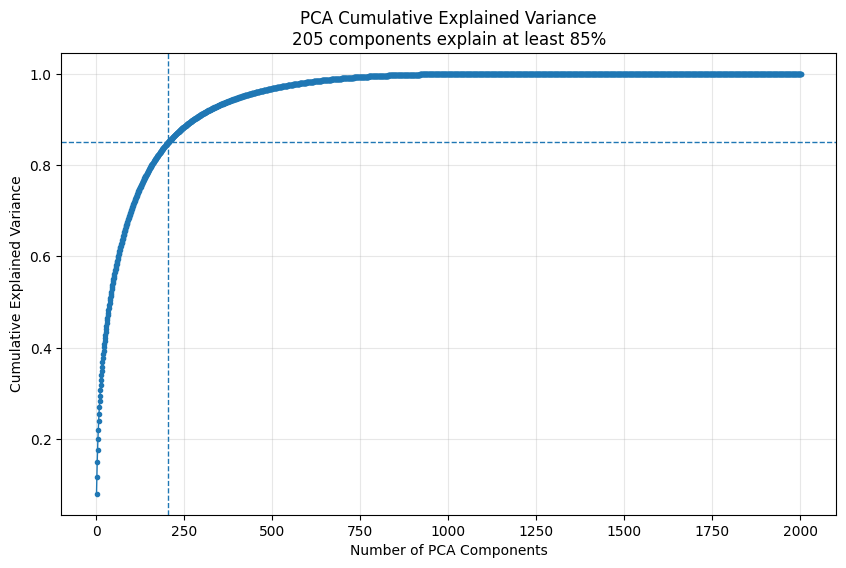

Saved: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs\eda\pca_cumulative_explained_variance.png


In [21]:
# ---------------------------------------------------------------------
# PCA explained variance plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    explained_df["component"],
    explained_df["cumulative_explained_variance"],
    marker="o",
    markersize=3,
    linewidth=1,
)

ax.axhline(PCA_VARIANCE_TARGET, linestyle="--", linewidth=1)
ax.axvline(n_components_80, linestyle="--", linewidth=1)

ax.set_title(f"PCA Cumulative Explained Variance\n{n_components_80} components explain at least {PCA_VARIANCE_TARGET:.0%}")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.grid(True, alpha=0.3)

plt.show()

# Optional save
pca_plot_path = EDA_DIR / "pca_cumulative_explained_variance.png"
fig.savefig(pca_plot_path, bbox_inches="tight", dpi=150)

print("Saved:", pca_plot_path.resolve())

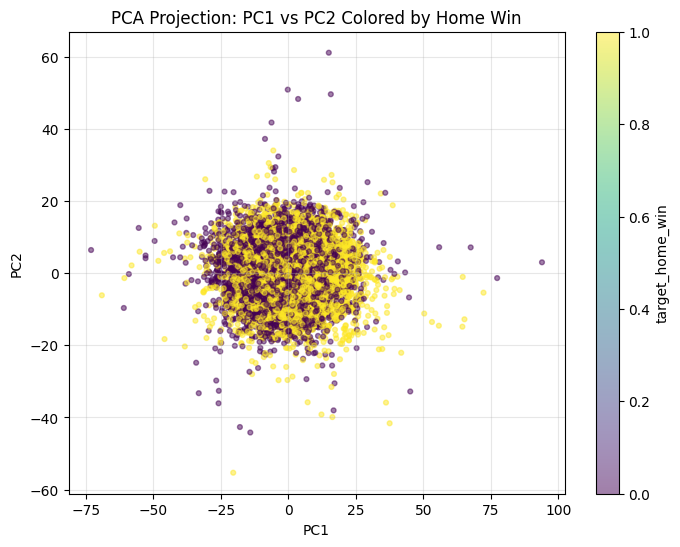

Saved: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs\eda\pca_pc1_pc2_home_win.png


In [22]:
# ---------------------------------------------------------------------
# Optional: project train/test into PC space and plot PC1 vs PC2
# ---------------------------------------------------------------------

X_pca_all = pca_pipe.transform(pca_completed[pca_feature_cols])

pc_scores = pd.DataFrame(
    X_pca_all[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)],
    index=pca_completed.index,
)

pc_scores = pd.concat(
    [
        pca_completed[[
            "official_date",
            "target_home_win",
            "target_total_runs",
            "target_home_margin",
        ]].reset_index(drop=True),
        pc_scores.reset_index(drop=True),
    ],
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    pc_scores["PC1"],
    pc_scores["PC2"],
    c=pc_scores["target_home_win"],
    alpha=0.5,
    s=12,
)

ax.set_title("PCA Projection: PC1 vs PC2 Colored by Home Win")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label="target_home_win")
plt.show()

pca_scatter_path = EDA_DIR / "pca_pc1_pc2_home_win.png"
fig.savefig(pca_scatter_path, bbox_inches="tight", dpi=150)

print("Saved:", pca_scatter_path.resolve())

In [23]:
# ---------------------------------------------------------------------
# Refit compact PCA transformer with only the number of components needed for 80%
# ---------------------------------------------------------------------

pca_80_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_80, random_state=RANDOM_STATE)),
])

pca_80_pipe.fit(pca_train_df[pca_feature_cols])

X_train_pca80 = pca_80_pipe.transform(pca_train_df[pca_feature_cols])
X_test_pca80 = pca_80_pipe.transform(pca_test_df[pca_feature_cols])

print("X_train_pca80:", X_train_pca80.shape)
print("X_test_pca80:", X_test_pca80.shape)

X_train_pca80: (6685, 205)
X_test_pca80: (1672, 205)


## 14. Train/test split helpers and baselines

In [24]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    accuracy_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)


def completed_for_target(df, target_col):
    d = df[df[target_col].notna()].copy()
    if MIN_TRAIN_DATE is not None and "official_date" in d.columns:
        d = d[d["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)].copy()
    if "official_date" in d.columns:
        d = d.sort_values(["official_date", "game_datetime_utc" if "game_datetime_utc" in d.columns else "official_date"])
    return d.reset_index(drop=True)


def time_train_test_split(df, target_col):
    d = completed_for_target(df, target_col)
    if HOLDOUT_START_DATE is not None and "official_date" in d.columns:
        cutoff = pd.to_datetime(HOLDOUT_START_DATE)
        train = d[d["official_date"] < cutoff].copy()
        test = d[d["official_date"] >= cutoff].copy()
    else:
        split = int(len(d) * (1.0 - TEST_FRACTION))
        train = d.iloc[:split].copy()
        test = d.iloc[split:].copy()
    return train, test


def regression_metrics(y_true, pred, prefix=""):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(pred, dtype=float)
    mask = np.isfinite(y) & np.isfinite(p)
    y = y[mask]
    p = p[mask]
    out = {
        prefix + "mae": float(mean_absolute_error(y, p)),
        prefix + "rmse": float(np.sqrt(mean_squared_error(y, p))),
        prefix + "r2": float(r2_score(y, p)),
        prefix + "avg_pred": float(np.mean(p)),
        prefix + "actual_mean": float(np.mean(y)),
        prefix + "n": int(len(y)),
    }
    return out


def classification_metrics(y_true, prob, prefix="", threshold: float = 0.5):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(prob, dtype=float)
    mask = np.isfinite(y) & np.isfinite(p)
    y = y[mask]
    p = np.clip(p[mask], 1e-6, 1 - 1e-6)
    out = {
        prefix + "log_loss": float(log_loss(y, p)),
        prefix + "brier": float(brier_score_loss(y, p)),
        prefix + "accuracy": float(accuracy_score(y, p >= threshold)),
        prefix + "auc": float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
        prefix + "avg_pred": float(np.mean(p)),
        prefix + "actual_mean": float(np.mean(y)),
        prefix + "n": int(len(y)),
    }
    return out


def find_best_accuracy_threshold(y_true, prob, thresholds=None):
    if thresholds is None:
        thresholds = globals().get("ACCURACY_THRESHOLD_GRID", np.arange(0.40, 0.61, 0.005))
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(prob, dtype=float)
    rows = []
    for t in thresholds:
        rows.append({"threshold": float(t), "accuracy": float(accuracy_score(y, p >= t))})
    return pd.DataFrame(rows).sort_values(["accuracy", "threshold"], ascending=[False, True]).iloc[0].to_dict()


def accuracy_by_confidence(y_true, prob, thresholds=np.arange(0.50, 0.76, 0.01)):
    y = np.asarray(y_true).astype(int)
    p = np.asarray(prob).astype(float)
    pred_home = p >= 0.5
    correct = np.where(pred_home, y == 1, y == 0)
    confidence = np.maximum(p, 1 - p)
    rows = []
    for t in thresholds:
        mask = confidence >= t
        rows.append({
            "confidence_threshold": float(t),
            "games_picked": int(mask.sum()),
            "coverage": float(mask.mean()),
            "accuracy": float(correct[mask].mean()) if mask.sum() else np.nan,
            "avg_confidence": float(confidence[mask].mean()) if mask.sum() else np.nan,
        })
    return pd.DataFrame(rows)

baseline_rows = []

if "target_home_win" in features.columns:
    train_ml, test_ml = time_train_test_split(features, "target_home_win")
    p_base = np.repeat(train_ml["target_home_win"].mean(), len(test_ml))
    row = {"target": "moneyline", "baseline": "train_home_win_rate"}
    row.update(classification_metrics(test_ml["target_home_win"], p_base))
    baseline_rows.append(row)

    if "elo_home_win_prob" in test_ml.columns:
        p_elo = test_ml["elo_home_win_prob"].clip(1e-6, 1 - 1e-6)
        row = {"target": "moneyline", "baseline": "elo_home_win_prob"}
        row.update(classification_metrics(test_ml["target_home_win"], p_elo))
        baseline_rows.append(row)

    if "robust_elo_home_win_prob" in test_ml.columns:
        p_robust_elo = test_ml["robust_elo_home_win_prob"].clip(1e-6, 1 - 1e-6)
        row = {"target": "moneyline", "baseline": "robust_elo_home_win_prob"}
        row.update(classification_metrics(test_ml["target_home_win"], p_robust_elo))
        baseline_rows.append(row)

    if "market_home_win_prob" in test_ml.columns and test_ml["market_home_win_prob"].notna().sum() > 0:
        m = test_ml["market_home_win_prob"].notna()
        p_market = test_ml.loc[m, "market_home_win_prob"].clip(1e-6, 1 - 1e-6)
        row = {"target": "moneyline", "baseline": "market_home_win_prob", "n_with_market": int(m.sum())}
        row.update(classification_metrics(test_ml.loc[m, "target_home_win"], p_market))
        baseline_rows.append(row)

for target in ["target_total_runs", "target_home_margin"]:
    if target in features.columns:
        train_r, test_r = time_train_test_split(features, target)
        pred_base = np.repeat(train_r[target].mean(), len(test_r))
        row = {"target": target, "baseline": "train_mean"}
        row.update(regression_metrics(test_r[target], pred_base))
        baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)
baseline_df.to_csv(EDA_DIR / "baseline_metrics.csv", index=False)

,target,baseline,log_loss,brier,accuracy,auc,avg_pred,actual_mean,n,mae,rmse,r2
0,moneyline,train_home_win_rate,0.691168,0.249011,0.531699,0.500000,0.527749,0.531699,1672,NaN,NaN,NaN
1,moneyline,elo_home_win_prob,0.697833,0.251876,0.538278,0.548686,0.547757,0.531699,1672,NaN,NaN,NaN
2,moneyline,robust_elo_home_win_prob,0.693544,0.249983,0.544258,0.555672,0.531700,0.531699,1672,NaN,NaN,NaN
3,target_total_runs,train_mean,NaN,NaN,NaN,NaN,8.965146,8.990431,1672,3.551227,4.486217,-0.000032
4,target_home_margin,train_mean,NaN,NaN,NaN,NaN,-0.004188,0.038278,1672,3.613902,4.541842,-0.000087


## 14.1 Team cluster EDA and statistical check

The model-facing cluster columns were already added upstream as numeric features. This section is only for visualization/EDA.

In [25]:

if "team_cluster_profile" in globals() and not team_cluster_profile.empty:
    display(
        team_cluster_profile[["team_name", "team_cluster_int", "cluster_profile_win_rate", "n_team_games"]]
        .sort_values(["team_cluster_int", "cluster_profile_win_rate"], ascending=[True, False])
    )

    cluster_eda_summary = (
        team_cluster_profile
        .groupby("team_cluster_int")
        .agg(
            n_teams=("team_name", "count"),
            avg_recent_weighted_win_rate=("cluster_profile_win_rate", "mean"),
            teams=("team_name", lambda x: ", ".join(x)),
        )
        .reset_index()
        .sort_values("avg_recent_weighted_win_rate", ascending=False)
    )
    display(cluster_eda_summary)
else:
    print("No team_cluster_profile found. Check ADD_INTEGER_TEAM_CLUSTERS.")


,team_name,team_cluster_int,cluster_profile_win_rate,n_team_games
7,Cleveland Guardians,0,0.541561,561
6,Cincinnati Reds,0,0.490356,560
14,Miami Marlins,0,0.477803,561
21,Pittsburgh Pirates,0,0.467321,561
23,San Francisco Giants,0,0.465192,560
19,Oakland Athletics,0,0.455496,560
29,Washington Nationals,0,0.449918,561
12,Los Angeles Angels,0,0.417723,561
5,Chicago White Sox,0,0.403697,559
8,Colorado Rockies,0,0.332797,561


,team_cluster_int,n_teams,avg_recent_weighted_win_rate,teams
1,1,20,0.525018,"Arizona Diamondbacks, Atlanta Braves, Baltimor..."
0,0,10,0.450186,"Chicago White Sox, Cincinnati Reds, Cleveland ..."


## 14.1 Testing Pitching Features

In [26]:
print("features shape:", features.shape)
print("unique games:", features["game_pk"].nunique())
print("rows per game:", len(features) / features["game_pk"].nunique())

features shape: (8404, 2142)
unique games: 8404
rows per game: 1.0


In [27]:
pitch_keywords = [
    "velo",
    "velocity",
    "whiff",
    "k_rate",
    "bb_rate",
    "era",
    "whip",
    "spin",
    "release",
    "pitch_type",
    "pitch_name",
]

pitch_cols = [
    c for c in features.columns
    if any(k in c.lower() for k in pitch_keywords)
]

diff_pitch_cols = [
    c for c in pitch_cols
    if any(k in c.lower() for k in ['diff'])
]

print("Pitching-related columns:", len(pitch_cols))
display(pd.DataFrame({"column": diff_pitch_cols}).head(300))

Pitching-related columns: 249


,column
0,diff_box_box_box_pitch_era_season_to_date
1,diff_box_box_box_pitch_era_last3
2,diff_box_box_box_pitch_era_last5
3,diff_box_box_box_pitch_era_last10
4,diff_box_box_box_pitch_era_last20
...,...
78,diff_starter_starter_statcast_sc_bb_rate_seaso...
79,diff_starter_starter_statcast_sc_bb_rate_last3
80,diff_starter_starter_statcast_sc_bb_rate_last5
81,diff_starter_starter_statcast_sc_bb_rate_last10


,corr_with_target,abs_corr
robust_diff_elo_home_adv,0.132869,0.132869
robust_diff_elo_pre,0.132869,0.132869
robust_elo_home_win_prob,0.131586,0.131586
diff_team_team_run_diff_season_to_date,0.124575,0.124575
diff_elo_pre,0.124007,0.124007
elo_home_win_prob,0.122742,0.122742
diff_box_box_runs_against_season_to_date,-0.120460,0.120460
diff_team_team_runs_against_season_to_date,-0.120460,0.120460
diff_box_box_box_pitch_runs_season_to_date,-0.120460,0.120460
diff_box_box_box_pitch_obp_season_to_date,-0.118581,0.118581


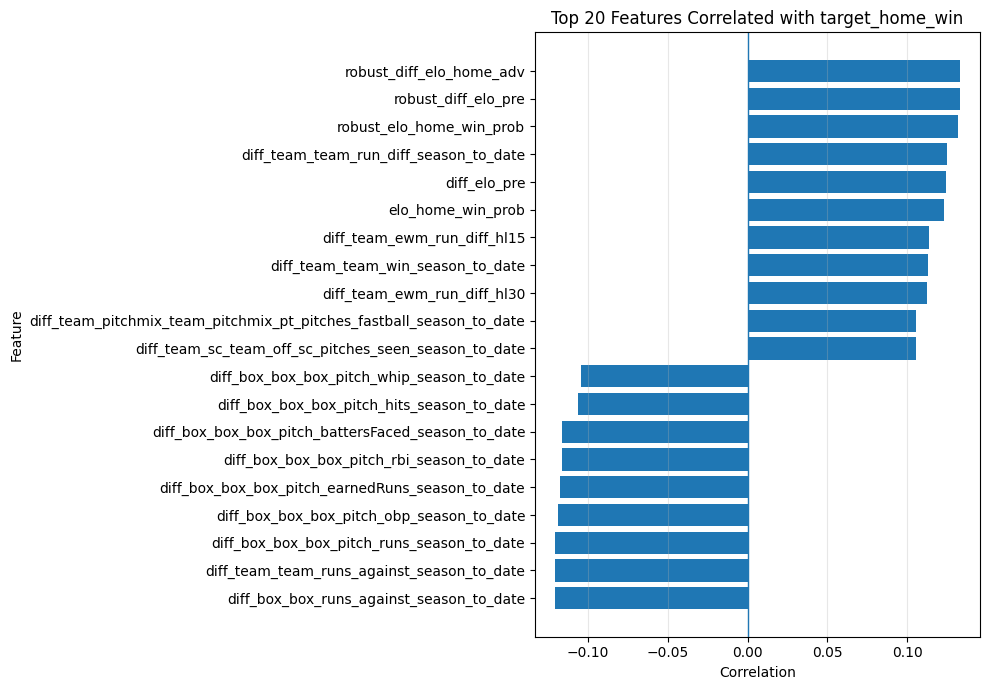

In [28]:
TARGET = "target_home_win"   # or "target_total_runs", "target_home_margin"
TOP_N = 20

corr_df = features[candidate_feature_cols + [TARGET]].corr(numeric_only=True)

target_corr = (
    corr_df[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(TOP_N)
)

display(
    target_corr
    .to_frame("corr_with_target")
    .assign(abs_corr=lambda d: d["corr_with_target"].abs())
)

plot_df = target_corr.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(plot_df.index, plot_df.values)

ax.axvline(0, linewidth=1)
ax.set_title(f"Top {TOP_N} Features Correlated with {TARGET}")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

,feature_1,feature_2,correlation,abs_correlation
0,away_team_team_runs_for_last10,away_box_box_runs_for_last10,1.0,1.0
1,home_team_team_runs_for_last20,home_box_box_runs_for_last20,1.0,1.0
2,away_team_team_runs_for_last20,away_box_box_runs_for_last20,1.0,1.0
3,away_box_box_box_pitch_hitByPitch_last10,away_box_box_box_pitch_hitBatsmen_last10,1.0,1.0
4,away_box_box_box_pitch_hitByPitch_last20,away_box_box_box_pitch_hitBatsmen_last20,1.0,1.0
5,away_box_box_box_pitch_hitByPitch_season_to_date,away_box_box_box_pitch_hitBatsmen_season_to_date,1.0,1.0
6,away_box_box_box_pitch_hitByPitch_last3,away_box_box_box_pitch_hitBatsmen_last3,1.0,1.0
7,away_box_box_box_pitch_hitByPitch_last5,away_box_box_box_pitch_hitBatsmen_last5,1.0,1.0
8,home_team_team_runs_against_last3,home_box_box_runs_against_last3,1.0,1.0
9,diff_team_team_runs_for_season_to_date,diff_box_box_runs_for_season_to_date,1.0,1.0


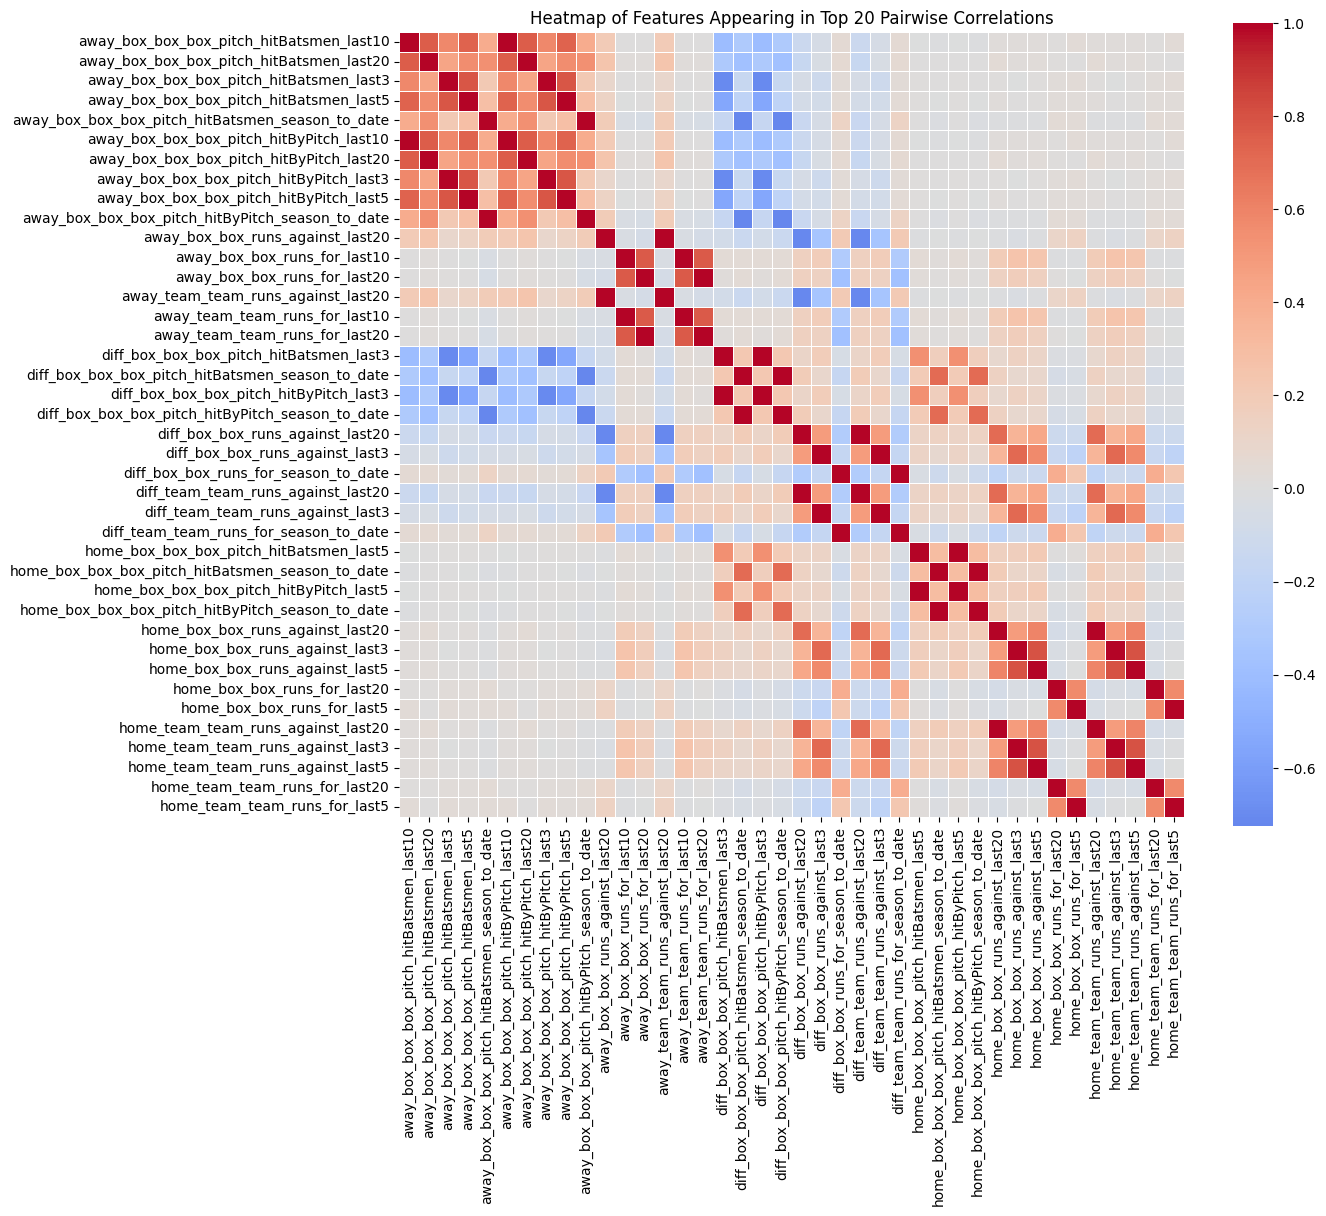

In [30]:
import seaborn as sns

TOP_N = 20

corr_matrix = features[candidate_feature_cols].corr(numeric_only=True)

# Keep upper triangle only to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation",
    })
)

top_pairs["abs_correlation"] = top_pairs["correlation"].abs()

top_pairs = (
    top_pairs
    .sort_values("abs_correlation", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(top_pairs)

top_pair_features = sorted(
    set(top_pairs["feature_1"]).union(set(top_pairs["feature_2"]))
)

top_pair_corr_matrix = features[top_pair_features].corr(numeric_only=True)

plt.figure(figsize=(14, 12))

sns.heatmap(
    top_pair_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title(f"Heatmap of Features Appearing in Top {TOP_N} Pairwise Correlations")
plt.tight_layout()
plt.show()

## 15. Model candidate factories

The notebook uses robust sklearn defaults. XGBoost is included only if installed locally.

In [31]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

print("HAS_XGBOOST:", HAS_XGBOOST)


def moneyline_model_candidates():
    candidates = []
    candidates.append((
        "logistic_l2",
        make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=3000, C=0.25, class_weight=None),
        ),
    ))
    candidates.append((
        "hist_gbdt",
        make_pipeline(
            SimpleImputer(strategy="median"),
            HistGradientBoostingClassifier(
                max_iter=250 if not FAST_MODE else 100,
                learning_rate=0.03,
                max_leaf_nodes=15,
                l2_regularization=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "random_forest",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesClassifier(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "random_forest_accuracy",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(
                n_estimators=800 if not FAST_MODE else 250,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees_accuracy",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesClassifier(
                n_estimators=800 if not FAST_MODE else 250,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if HAS_XGBOOST:
        candidates.append((
            "xgboost_logloss",
            XGBClassifier(
                n_estimators=450 if not FAST_MODE else 150,
                max_depth=3,
                learning_rate=0.025,
                subsample=0.85,
                colsample_bytree=0.75,
                objective="binary:logistic",
                eval_metric="logloss",
                reg_lambda=5.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ))
    return candidates


def regression_model_candidates(target_type="normal"):
    candidates = []
    candidates.append((
        "ridge_l2",
        make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            Ridge(alpha=20.0),
        ),
    ))
    candidates.append((
        "hist_gbdt_squared_error",
        make_pipeline(
            SimpleImputer(strategy="median"),
            HistGradientBoostingRegressor(
                loss="squared_error",
                max_iter=250 if not FAST_MODE else 100,
                learning_rate=0.03,
                max_leaf_nodes=15,
                l2_regularization=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if target_type == "count_positive":
        candidates.append((
            "hist_gbdt_poisson",
            make_pipeline(
                SimpleImputer(strategy="median"),
                HistGradientBoostingRegressor(
                    loss="poisson",
                    max_iter=250 if not FAST_MODE else 100,
                    learning_rate=0.03,
                    max_leaf_nodes=15,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ))
        candidates.append((
            "poisson_glm_l2",
            make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                PoissonRegressor(alpha=1.0, max_iter=1000),
            ),
        ))
    candidates.append((
        "random_forest",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestRegressor(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesRegressor(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "random_forest_accuracy",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(
                n_estimators=800 if not FAST_MODE else 250,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees_accuracy",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesClassifier(
                n_estimators=800 if not FAST_MODE else 250,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if HAS_XGBOOST:
        objective = "count:poisson" if target_type == "count_positive" else "reg:squarederror"
        candidates.append((
            "xgboost_poisson" if target_type == "count_positive" else "xgboost_squarederror",
            XGBRegressor(
                n_estimators=500 if not FAST_MODE else 150,
                max_depth=3,
                learning_rate=0.025,
                subsample=0.85,
                colsample_bytree=0.75,
                objective=objective,
                reg_lambda=5.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ))
    return candidates

HAS_XGBOOST: True


## 16. Train moneyline models

In [32]:
moneyline_results = []
moneyline_fitted = {}
moneyline_preds = {}

if "target_home_win" in features.columns:
    train_df, test_df = time_train_test_split(features, "target_home_win")
    print("moneyline train/test:", train_df.shape, test_df.shape)
    if "official_date" in train_df.columns:
        print("train dates:", train_df["official_date"].min(), train_df["official_date"].max())
        print("test dates:", test_df["official_date"].min(), test_df["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df.columns]
        cols = list(dict.fromkeys(cols))
        if len(cols) == 0:
            continue
        X_train = train_df[cols]
        y_train = train_df["target_home_win"].astype(int)
        X_test = test_df[cols]
        y_test = test_df["target_home_win"].astype(int)

        for model_name, model in moneyline_model_candidates():
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                tuned_threshold = 0.5
                val_accuracy = np.nan

                if bool(globals().get("OPTIMIZE_ACCURACY_THRESHOLD", True)) and len(X_train) >= 300:
                    val_cut = int(len(X_train) * 0.80)
                    X_fit, X_val = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
                    y_fit, y_val = y_train.iloc[:val_cut], y_train.iloc[val_cut:]
                    threshold_model = clone(model)
                    threshold_model.fit(X_fit, y_fit)
                    val_prob = threshold_model.predict_proba(X_val)[:, 1]
                    best_t = find_best_accuracy_threshold(y_val, val_prob)
                    tuned_threshold = float(best_t["threshold"])
                    val_accuracy = float(best_t["accuracy"])

                model.fit(X_train, y_train)
                prob = model.predict_proba(X_test)[:, 1]
                metrics = classification_metrics(y_test, prob)
                metrics["accuracy_tuned_threshold"] = float(accuracy_score(y_test, prob >= tuned_threshold))
                metrics["tuned_threshold"] = float(tuned_threshold)
                metrics["validation_accuracy_at_tuned_threshold"] = val_accuracy

                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                moneyline_results.append(row)
                moneyline_fitted[full_name] = {"model": model, "feature_cols": cols, "tuned_threshold": tuned_threshold}
                moneyline_preds[full_name] = prob
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

moneyline_results_df = pd.DataFrame(moneyline_results)
if not moneyline_results_df.empty:
    moneyline_results_df = moneyline_results_df.sort_values(["log_loss", "brier", "auc"], ascending=[True, True, False]).reset_index(drop=True)
    print("Top models by log loss:")
    display(moneyline_results_df.head(30))

    moneyline_accuracy_leaderboard = moneyline_results_df.sort_values(
        ["accuracy_tuned_threshold", "accuracy", "log_loss"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    print("Top models by holdout accuracy using validation-tuned threshold:")
    display(moneyline_accuracy_leaderboard.head(30))

    over_60 = moneyline_accuracy_leaderboard[moneyline_accuracy_leaderboard["accuracy_tuned_threshold"] >= 0.60]
    if len(over_60):
        print("Models reaching at least 60% holdout accuracy:")
        display(over_60)
    else:
        print("No all-game holdout model reached 60% accuracy. Check selective accuracy by confidence below.")

    moneyline_results_df.to_csv(EDA_DIR / "moneyline_model_results.csv", index=False)
    moneyline_accuracy_leaderboard.to_csv(EDA_DIR / "moneyline_accuracy_leaderboard.csv", index=False)
else:
    print("No moneyline results.")


moneyline train/test: (6685, 2142) (1672, 2142)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__logistic_l2 features 40
Training elo_only__hist_gbdt features 40
Training elo_only__random_forest features 40
Training elo_only__extra_trees features 40
Training elo_only__random_forest_accuracy features 40
Training elo_only__extra_trees_accuracy features 40
Training elo_only__xgboost_logloss features 40
Training robust_elo_only__logistic_l2 features 6
Training robust_elo_only__hist_gbdt features 6
Training robust_elo_only__random_forest features 6
Training robust_elo_only__extra_trees features 6
Training robust_elo_only__random_forest_accuracy features 6
Training robust_elo_only__extra_trees_accuracy features 6
Training robust_elo_only__xgboost_logloss features 6
Training market_elo_cluster__logistic_l2 features 55
Training market_elo_cluster__hist_gbdt features 55
Training market_elo_cluster__random_forest features

,model_name,feature_set,estimator,feature_count,log_loss,brier,accuracy,auc,avg_pred,actual_mean,n,accuracy_tuned_threshold,tuned_threshold,validation_accuracy_at_tuned_threshold
0,elo_only__extra_trees,elo_only,extra_trees,40,0.683424,0.245237,0.548445,0.565549,0.528129,0.531699,1672,0.547249,0.510,0.555722
1,starter_plus_team__random_forest,starter_plus_team,random_forest,422,0.683790,0.245468,0.550837,0.559159,0.529447,0.531699,1672,0.538278,0.515,0.551982
2,accuracy_core_no_box__random_forest,accuracy_core_no_box,random_forest,949,0.684166,0.245653,0.539474,0.555284,0.529863,0.531699,1672,0.546053,0.460,0.556470
3,full_non_market__extra_trees,full_non_market,extra_trees,1987,0.684574,0.245801,0.551435,0.557627,0.529801,0.531699,1672,0.557416,0.490,0.559461
4,full_non_market__random_forest,full_non_market,random_forest,1987,0.684626,0.245871,0.539474,0.556748,0.530473,0.531699,1672,0.547847,0.460,0.558714
5,all_clean__extra_trees,all_clean,extra_trees,2032,0.684700,0.245863,0.547249,0.556655,0.530302,0.531699,1672,0.541268,0.490,0.553478
6,accuracy_core_no_box__random_forest_accuracy,accuracy_core_no_box,random_forest_accuracy,949,0.684914,0.246003,0.527512,0.552839,0.516372,0.531699,1672,0.547847,0.460,0.550486
7,starter_plus_team__extra_trees,starter_plus_team,extra_trees,422,0.684961,0.246000,0.552033,0.554174,0.528856,0.531699,1672,0.528110,0.525,0.558714
8,elo_only__extra_trees_accuracy,elo_only,extra_trees_accuracy,40,0.684991,0.245988,0.553230,0.567268,0.503846,0.531699,1672,0.547249,0.435,0.557218
9,accuracy_core_no_box__extra_trees,accuracy_core_no_box,extra_trees,949,0.684993,0.246004,0.548445,0.553385,0.530140,0.531699,1672,0.541866,0.470,0.555722


Top models by holdout accuracy using validation-tuned threshold:


,model_name,feature_set,estimator,feature_count,log_loss,brier,accuracy,auc,avg_pred,actual_mean,n,accuracy_tuned_threshold,tuned_threshold,validation_accuracy_at_tuned_threshold
0,full_non_market__extra_trees,full_non_market,extra_trees,1987,0.684574,0.245801,0.551435,0.557627,0.529801,0.531699,1672,0.557416,0.490,0.559461
1,statcast_team_plus_pitchmix__logistic_l2,statcast_team_plus_pitchmix,logistic_l2,658,0.715183,0.259401,0.527512,0.542461,0.517580,0.531699,1672,0.552632,0.400,0.522812
2,statcast_team_plus_pitchmix__random_forest,statcast_team_plus_pitchmix,random_forest,658,0.685557,0.246300,0.546651,0.552116,0.532264,0.531699,1672,0.550239,0.475,0.555722
3,statcast_team_plus_pitchmix__extra_trees_accuracy,statcast_team_plus_pitchmix,extra_trees_accuracy,658,0.685778,0.246378,0.538278,0.556186,0.509398,0.531699,1672,0.549043,0.470,0.554974
4,market_elo_cluster__extra_trees,market_elo_cluster,extra_trees,55,0.687030,0.246979,0.555622,0.554337,0.530399,0.531699,1672,0.548445,0.455,0.563201
5,all_clean__random_forest,all_clean,random_forest,2032,0.685430,0.246276,0.541268,0.551279,0.530405,0.531699,1672,0.548445,0.480,0.555722
6,full_non_market__random_forest,full_non_market,random_forest,1987,0.684626,0.245871,0.539474,0.556748,0.530473,0.531699,1672,0.547847,0.460,0.558714
7,accuracy_core_no_box__random_forest_accuracy,accuracy_core_no_box,random_forest_accuracy,949,0.684914,0.246003,0.527512,0.552839,0.516372,0.531699,1672,0.547847,0.460,0.550486
8,elo_only__extra_trees_accuracy,elo_only,extra_trees_accuracy,40,0.684991,0.245988,0.553230,0.567268,0.503846,0.531699,1672,0.547249,0.435,0.557218
9,elo_only__extra_trees,elo_only,extra_trees,40,0.683424,0.245237,0.548445,0.565549,0.528129,0.531699,1672,0.547249,0.510,0.555722


No all-game holdout model reached 60% accuracy. Check selective accuracy by confidence below.


## 16.1 Accuracy target diagnostics

Use this section to distinguish **all-game accuracy** from **selective-pick accuracy**. If all-game accuracy does not reach 60%, this table shows whether 60% is achievable on high-confidence games only.

In [33]:

if "moneyline_accuracy_leaderboard" in globals() and not moneyline_accuracy_leaderboard.empty:
    best_acc_name = moneyline_accuracy_leaderboard.iloc[0]["model_name"]
    best_acc_threshold = float(moneyline_fitted[best_acc_name].get("tuned_threshold", 0.5))
    best_acc_prob = moneyline_preds[best_acc_name]
    y_test_ml = test_df["target_home_win"].astype(int)

    print("Best accuracy model:", best_acc_name)
    print("Validation-tuned threshold:", best_acc_threshold)

    display(pd.DataFrame([{
        "model_name": best_acc_name,
        "all_game_accuracy_at_0_5": accuracy_score(y_test_ml, best_acc_prob >= 0.5),
        "all_game_accuracy_at_tuned_threshold": accuracy_score(y_test_ml, best_acc_prob >= best_acc_threshold),
        "log_loss": log_loss(y_test_ml, np.clip(best_acc_prob, 1e-6, 1 - 1e-6)),
        "brier": brier_score_loss(y_test_ml, np.clip(best_acc_prob, 1e-6, 1 - 1e-6)),
        "auc": roc_auc_score(y_test_ml, best_acc_prob),
    }]))

    selective_accuracy_df = accuracy_by_confidence(y_test_ml, best_acc_prob)
    display(selective_accuracy_df)

    sixty_selective = selective_accuracy_df[selective_accuracy_df["accuracy"] >= 0.60]
    if len(sixty_selective):
        print("Confidence thresholds where selected games reach at least 60% accuracy:")
        display(sixty_selective.head(20))
    else:
        print("No confidence bucket reached 60% accuracy on this holdout split.")
else:
    print("Run moneyline model training first.")


Best accuracy model: full_non_market__extra_trees
Validation-tuned threshold: 0.4900000000000001


,model_name,all_game_accuracy_at_0_5,all_game_accuracy_at_tuned_threshold,log_loss,brier,auc
0,full_non_market__extra_trees,0.551435,0.557416,0.684574,0.245801,0.557627


,confidence_threshold,games_picked,coverage,accuracy,avg_confidence
0,0.50,1672,1.000000,0.551435,0.546022
1,0.51,1437,0.859450,0.558803,0.552696
2,0.52,1177,0.703947,0.561597,0.561042
3,0.53,972,0.581340,0.561728,0.568667
4,0.54,801,0.479067,0.570537,0.575906
5,0.55,624,0.373206,0.586538,0.584765
6,0.56,487,0.291268,0.597536,0.593205
7,0.57,367,0.219498,0.604905,0.602521
8,0.58,273,0.163278,0.604396,0.611938
9,0.59,190,0.113636,0.636842,0.623717


Confidence thresholds where selected games reach at least 60% accuracy:


,confidence_threshold,games_picked,coverage,accuracy,avg_confidence
7,0.57,367,0.219498,0.604905,0.602521
8,0.58,273,0.163278,0.604396,0.611938
9,0.59,190,0.113636,0.636842,0.623717
10,0.60,139,0.083134,0.697842,0.634391
11,0.61,106,0.063397,0.716981,0.643637
12,0.62,75,0.044856,0.760000,0.655467
13,0.63,59,0.035287,0.813559,0.663727
14,0.64,48,0.028708,0.791667,0.670437
15,0.65,37,0.022129,0.810811,0.677899
16,0.66,28,0.016746,0.785714,0.685356


## 17. Train total-runs models

In [34]:
totals_results = []
totals_fitted = {}
totals_preds = {}

if "target_total_runs" in features.columns:
    train_df_total, test_df_total = time_train_test_split(features, "target_total_runs")
    print("totals train/test:", train_df_total.shape, test_df_total.shape)
    if "official_date" in train_df_total.columns:
        print("train dates:", train_df_total["official_date"].min(), train_df_total["official_date"].max())
        print("test dates:", test_df_total["official_date"].min(), test_df_total["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df_total.columns]
        if len(cols) == 0:
            continue
        X_train = train_df_total[cols]
        y_train = train_df_total["target_total_runs"].astype(float)
        X_test = test_df_total[cols]
        y_test = test_df_total["target_total_runs"].astype(float)

        for model_name, model in regression_model_candidates(target_type="count_positive"):
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                model.fit(X_train, y_train)
                pred = np.asarray(model.predict(X_test), dtype=float)
                # Total runs cannot be negative. Clip only for evaluation/deviance safety.
                pred_eval = np.clip(pred, 0.05, None)
                metrics = regression_metrics(y_test, pred_eval)
                try:
                    metrics["poisson_deviance"] = float(mean_poisson_deviance(y_test, pred_eval))
                except Exception:
                    metrics["poisson_deviance"] = np.nan
                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                totals_results.append(row)
                totals_fitted[full_name] = {"model": model, "feature_cols": cols}
                totals_preds[full_name] = pred_eval
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

totals_results_df = pd.DataFrame(totals_results)
if not totals_results_df.empty:
    totals_results_df = totals_results_df.sort_values(["mae", "rmse", "poisson_deviance"], ascending=[True, True, True]).reset_index(drop=True)
    display(totals_results_df.head(30))
    totals_results_df.to_csv(EDA_DIR / "totals_model_results.csv", index=False)

    # Guardrail: suspiciously good totals models are likely leaking final score information.
    suspicious_totals = totals_results_df[(totals_results_df["mae"] < 2.0) | (totals_results_df["r2"] > 0.50)]
    if not suspicious_totals.empty:
        print("WARNING: suspicious totals models detected. Do not export these until leakage is resolved.")
        display(suspicious_totals)
else:
    print("No totals results.")

totals train/test: (6685, 2142) (1672, 2142)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__ridge_l2 features 40
Training elo_only__hist_gbdt_squared_error features 40
Training elo_only__hist_gbdt_poisson features 40
Training elo_only__poisson_glm_l2 features 40
Training elo_only__random_forest features 40
Training elo_only__extra_trees features 40
Training elo_only__random_forest_accuracy features 40
Training elo_only__extra_trees_accuracy features 40
Training elo_only__xgboost_poisson features 40
Training robust_elo_only__ridge_l2 features 6
Training robust_elo_only__hist_gbdt_squared_error features 6
Training robust_elo_only__hist_gbdt_poisson features 6
Training robust_elo_only__poisson_glm_l2 features 6
Training robust_elo_only__random_forest features 6
Training robust_elo_only__extra_trees features 6
Training robust_elo_only__random_forest_accuracy features 6
Training robust_elo_only__extra_trees_accurac

,model_name,feature_set,estimator,feature_count,mae,rmse,r2,avg_pred,actual_mean,n,poisson_deviance
0,starter_plus_team__random_forest,starter_plus_team,random_forest,422,3.519897,4.454217,0.014184,8.830909,8.990431,1672,2.203529
1,market_elo_cluster__ridge_l2,market_elo_cluster,ridge_l2,55,3.521069,4.454719,0.013962,8.896363,8.990431,1672,2.203654
2,full_non_market__random_forest,full_non_market,random_forest,1987,3.521236,4.452934,0.014752,8.857617,8.990431,1672,2.202409
3,all_clean__random_forest,all_clean,random_forest,2032,3.522853,4.456049,0.013373,8.869702,8.990431,1672,2.205323
4,market_elo_cluster__random_forest,market_elo_cluster,random_forest,55,3.522941,4.447679,0.017076,8.892519,8.990431,1672,2.196883
5,team_form_plus_elo__random_forest,team_form_plus_elo,random_forest,143,3.523841,4.456067,0.013365,8.788714,8.990431,1672,2.205452
6,market_elo_cluster__extra_trees,market_elo_cluster,extra_trees,55,3.525386,4.457284,0.012826,8.873323,8.990431,1672,2.206058
7,elo_only__ridge_l2,elo_only,ridge_l2,40,3.525723,4.469784,0.007281,8.864477,8.990431,1672,2.218588
8,accuracy_core_no_box__random_forest,accuracy_core_no_box,random_forest,949,3.525947,4.451605,0.015340,8.891716,8.990431,1672,2.200945
9,starter_plus_team__extra_trees,starter_plus_team,extra_trees,422,3.528437,4.459705,0.011753,8.877327,8.990431,1672,2.208291


## 18. Train home-margin / run-line models

In [35]:
margin_results = []
margin_fitted = {}
margin_preds = {}

if "target_home_margin" in features.columns:
    train_df_margin, test_df_margin = time_train_test_split(features, "target_home_margin")
    print("margin train/test:", train_df_margin.shape, test_df_margin.shape)
    if "official_date" in train_df_margin.columns:
        print("train dates:", train_df_margin["official_date"].min(), train_df_margin["official_date"].max())
        print("test dates:", test_df_margin["official_date"].min(), test_df_margin["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df_margin.columns]
        if len(cols) == 0:
            continue
        X_train = train_df_margin[cols]
        y_train = train_df_margin["target_home_margin"].astype(float)
        X_test = test_df_margin[cols]
        y_test = test_df_margin["target_home_margin"].astype(float)

        for model_name, model in regression_model_candidates(target_type="normal"):
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                model.fit(X_train, y_train)
                pred = np.asarray(model.predict(X_test), dtype=float)
                metrics = regression_metrics(y_test, pred)
                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                margin_results.append(row)
                margin_fitted[full_name] = {"model": model, "feature_cols": cols}
                margin_preds[full_name] = pred
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

margin_results_df = pd.DataFrame(margin_results)
if not margin_results_df.empty:
    margin_results_df = margin_results_df.sort_values(["mae", "rmse"], ascending=[True, True]).reset_index(drop=True)
    display(margin_results_df.head(30))
    margin_results_df.to_csv(EDA_DIR / "margin_model_results.csv", index=False)
else:
    print("No margin results.")

margin train/test: (6685, 2142) (1672, 2142)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__ridge_l2 features 40
Training elo_only__hist_gbdt_squared_error features 40
Training elo_only__random_forest features 40
Training elo_only__extra_trees features 40
Training elo_only__random_forest_accuracy features 40
Training elo_only__extra_trees_accuracy features 40
Training elo_only__xgboost_squarederror features 40
Training robust_elo_only__ridge_l2 features 6
Training robust_elo_only__hist_gbdt_squared_error features 6
Training robust_elo_only__random_forest features 6
Training robust_elo_only__extra_trees features 6
Training robust_elo_only__random_forest_accuracy features 6
Training robust_elo_only__extra_trees_accuracy features 6
Training robust_elo_only__xgboost_squarederror features 6
Training market_elo_cluster__ridge_l2 features 55
Training market_elo_cluster__hist_gbdt_squared_error features 55
Training ma

,model_name,feature_set,estimator,feature_count,mae,rmse,r2,avg_pred,actual_mean,n
0,accuracy_core_no_box__random_forest,accuracy_core_no_box,random_forest,949,3.539194,4.481195,0.026442,0.005829,0.038278,1672
1,full_non_market__random_forest,full_non_market,random_forest,1987,3.540578,4.481840,0.026162,0.003841,0.038278,1672
2,starter_plus_team__random_forest,starter_plus_team,random_forest,422,3.542580,4.487039,0.023902,-0.003172,0.038278,1672
3,all_clean__random_forest,all_clean,random_forest,2032,3.544259,4.484685,0.024925,-0.005110,0.038278,1672
4,accuracy_core_no_box__xgboost_squarederror,accuracy_core_no_box,xgboost_squarederror,949,3.545031,4.507944,0.014785,0.066592,0.038278,1672
5,starter_plus_team__hist_gbdt_squared_error,starter_plus_team,hist_gbdt_squared_error,422,3.545578,4.504524,0.016279,0.025673,0.038278,1672
6,accuracy_core_no_box__extra_trees,accuracy_core_no_box,extra_trees,949,3.545751,4.484813,0.024870,0.003149,0.038278,1672
7,starter_plus_team__extra_trees,starter_plus_team,extra_trees,422,3.546818,4.489263,0.022934,-0.006030,0.038278,1672
8,all_clean__xgboost_squarederror,all_clean,xgboost_squarederror,2032,3.547508,4.510460,0.013685,0.052397,0.038278,1672
9,accuracy_core_no_box__hist_gbdt_squared_error,accuracy_core_no_box,hist_gbdt_squared_error,949,3.548058,4.505660,0.015783,0.046627,0.038278,1672


## 18.1 running a feature elimination model

In [36]:
def walk_forward_splits(df, date_col="official_date", min_train_date=None):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.sort_values(date_col).copy()
    d["season"] = d[date_col].dt.year

    seasons = sorted(d["season"].dropna().unique())

    splits = []

    for test_season in seasons[1:]:
        train_idx = d[d["season"] < test_season].index
        test_idx = d[d["season"] == test_season].index

        if len(train_idx) == 0 or len(test_idx) == 0:
            continue

        splits.append((test_season, train_idx, test_idx))

    return splits


def evaluate_classifier_preds(y_true, p):
    p = np.clip(p, 0.001, 0.999)

    return {
        "log_loss": log_loss(y_true, p),
        "brier": brier_score_loss(y_true, p),
        "auc": roc_auc_score(y_true, p),
        "accuracy": accuracy_score(y_true, p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": y_true.mean(),
    }

In [37]:
from sklearn.calibration import CalibratedClassifierCV

# Chronological split inside training data
train_df_sorted = train_df.sort_values("official_date").copy()

cal_split = int(len(train_df_sorted) * 0.80)

fit_df = train_df_sorted.iloc[:cal_split].copy()
cal_df = train_df_sorted.iloc[cal_split:].copy()

base_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

best_cal_cols = moneyline_fitted[moneyline_accuracy_leaderboard.iloc[0]["model_name"]]["feature_cols"]
base_rf.fit(fit_df[best_cal_cols], fit_df["target_home_win"])

# Calibrate on later training slice
calibrated_rf = CalibratedClassifierCV(
    estimator=base_rf,
    method="isotonic",  # also test "sigmoid"
    cv="prefit",
)

calibrated_rf.fit(cal_df[best_cal_cols], cal_df["target_home_win"])

p_uncal = base_rf.predict_proba(test_df[best_cal_cols])[:, 1]
p_cal = calibrated_rf.predict_proba(test_df[best_cal_cols])[:, 1]

calibration_compare = pd.DataFrame([
    {
        "model": "rf_uncalibrated",
        **evaluate_classifier_preds(test_df["target_home_win"], p_uncal),
    },
    {
        "model": "rf_isotonic_calibrated",
        **evaluate_classifier_preds(test_df["target_home_win"], p_cal),
    },
])

display(calibration_compare.sort_values("log_loss"))

,model,log_loss,brier,auc,accuracy,avg_pred,actual_mean
1,rf_isotonic_calibrated,0.684797,0.245677,0.556451,0.563397,0.525873,0.531699
0,rf_uncalibrated,0.685018,0.246036,0.554027,0.535287,0.533749,0.531699


In [39]:
# ---------------------------------------------------------------------
# Rebuild model_df from the enriched features dataframe
# ---------------------------------------------------------------------

features = features.loc[:, ~features.columns.duplicated(keep="first")].copy()

model_df = features.copy()
model_df["official_date"] = pd.to_datetime(model_df["official_date"], errors="coerce")

required_targets = [
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
]

missing_targets = [c for c in required_targets if c not in model_df.columns]
assert not missing_targets, f"Missing target columns: {missing_targets}"

model_df = model_df[
    model_df["official_date"].notna()
    & model_df["target_home_win"].notna()
    & model_df["target_total_runs"].notna()
    & model_df["target_home_margin"].notna()
].sort_values("official_date").reset_index(drop=True)

# Keep cluster columns numeric, not strings
cluster_int_cols = [
    "home_team_cluster_recent",
    "away_team_cluster_recent",
    "same_team_cluster_recent",
]

for c in cluster_int_cols:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").fillna(-1).astype(int)

print("model_df:", model_df.shape)
print("Date range:", model_df["official_date"].min(), "to", model_df["official_date"].max())

print("Cluster columns:")
display([c for c in model_df.columns if "cluster" in c.lower()])

model_df: (8357, 2142)
Date range: 2023-03-30 00:00:00 to 2026-06-14 00:00:00
Cluster columns:


['home_team_cluster_recent',
 'away_team_cluster_recent',
 'same_team_cluster_recent']

In [40]:
# ---------------------------------------------------------------------
# Walk-forward validation using current best model feature set
# ---------------------------------------------------------------------

best_model_name = moneyline_accuracy_leaderboard.iloc[0]["model_name"]
best_wf_cols = moneyline_fitted[best_model_name]["feature_cols"]

best_wf_cols = [
    c for c in best_wf_cols
    if c in model_df.columns
]

print("Best model:", best_model_name)
print("Walk-forward feature count:", len(best_wf_cols))

# Make sure clusters are included if they are supposed to be
print("Cluster features in best_wf_cols:")
display([c for c in best_wf_cols if "cluster" in c.lower()])

Best model: full_non_market__extra_trees
Walk-forward feature count: 1987
Cluster features in best_wf_cols:


['away_team_cluster_recent',
 'home_team_cluster_recent',
 'same_team_cluster_recent']

In [42]:
wf_df = model_df.copy()
wf_df["official_date"] = pd.to_datetime(wf_df["official_date"], errors="coerce")

walk_results = []

for test_season, train_idx, test_idx in walk_forward_splits(wf_df):
    tr = wf_df.loc[train_idx].copy()
    te = wf_df.loc[test_idx].copy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=700,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(tr[best_wf_cols], tr["target_home_win"])

    p = model.predict_proba(te[best_wf_cols])[:, 1]
    p = np.clip(p, 0.001, 0.999)

    row = {
        "test_season": test_season,
        "n_train": len(tr),
        "n_test": len(te),
        "n_features": len(best_wf_cols),
    }

    row.update(evaluate_classifier_preds(te["target_home_win"], p))
    walk_results.append(row)

walk_results_df = pd.DataFrame(walk_results)

display(walk_results_df)

display(
    walk_results_df[
        ["log_loss", "brier", "auc", "accuracy", "avg_pred", "actual_mean"]
    ].mean().to_frame("mean_metric")
)

,test_season,n_train,n_test,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean
0,2024,2430,2429,1987,0.678410,0.242722,0.597102,0.570193,0.518628,0.521614
1,2025,4859,2430,1987,0.678524,0.242862,0.580681,0.556379,0.522183,0.542798
2,2026,7289,1068,1987,0.688278,0.247601,0.544770,0.540262,0.532026,0.529026


,mean_metric
log_loss,0.681737
brier,0.244395
auc,0.574184
accuracy,0.555611
avg_pred,0.524279
actual_mean,0.531146


In [43]:
selective_accuracy_df = accuracy_by_confidence(
    test_df["target_home_win"],
    p_cal,
)

display(selective_accuracy_df)

,confidence_threshold,games_picked,coverage,accuracy,avg_confidence
0,0.50,1672,1.000000,0.563397,0.545879
1,0.51,1672,1.000000,0.563397,0.545879
2,0.52,722,0.431818,0.574792,0.586559
3,0.53,719,0.430024,0.575800,0.586823
4,0.54,717,0.428828,0.574616,0.586976
5,0.55,717,0.428828,0.574616,0.586976
6,0.56,350,0.209330,0.634286,0.619134
7,0.57,262,0.156699,0.645038,0.638587
8,0.58,96,0.057416,0.708333,0.756545
9,0.59,96,0.057416,0.708333,0.756545


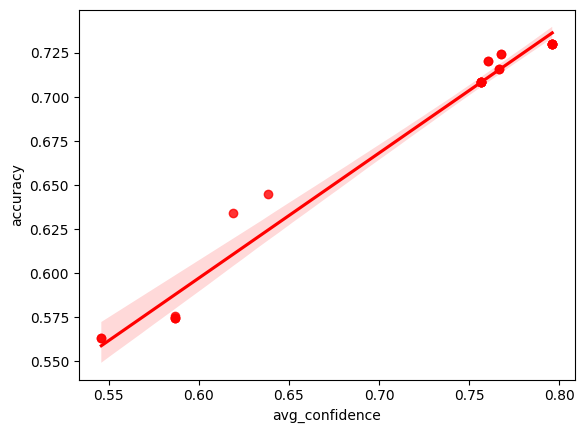

In [51]:
sns.regplot(data=selective_accuracy_df, x="avg_confidence", y="accuracy", scatter=True, color="red")
plt.show()

In [52]:
from statsmodels.stats.proportion import proportion_confint

ci_rows = []

for _, row in selective_accuracy_df.iterrows():
    n = int(row["games_picked"])
    acc = row["accuracy"]

    if n > 0 and pd.notna(acc):
        wins = int(round(acc * n))

        ci_low, ci_high = proportion_confint(
            count=wins,
            nobs=n,
            alpha=0.05,
            method="wilson",
        )
    else:
        wins = np.nan
        ci_low = np.nan
        ci_high = np.nan

    ci_rows.append({
        **row.to_dict(),
        "estimated_correct": wins,
        "accuracy_ci_low": ci_low,
        "accuracy_ci_high": ci_high,
    })

selective_accuracy_ci_df = pd.DataFrame(ci_rows)

display(selective_accuracy_ci_df)

,confidence_threshold,games_picked,coverage,accuracy,avg_confidence,estimated_correct,accuracy_ci_low,accuracy_ci_high
0,0.50,1672.0,1.000000,0.563397,0.545879,942,0.539506,0.586998
1,0.51,1672.0,1.000000,0.563397,0.545879,942,0.539506,0.586998
2,0.52,722.0,0.431818,0.574792,0.586559,415,0.538429,0.610364
3,0.53,719.0,0.430024,0.575800,0.586823,414,0.539366,0.611428
4,0.54,717.0,0.428828,0.574616,0.586976,412,0.538125,0.610313
5,0.55,717.0,0.428828,0.574616,0.586976,412,0.538125,0.610313
6,0.56,350.0,0.209330,0.634286,0.619134,222,0.582624,0.683032
7,0.57,262.0,0.156699,0.645038,0.638587,169,0.585384,0.700501
8,0.58,96.0,0.057416,0.708333,0.756545,68,0.610801,0.789834
9,0.59,96.0,0.057416,0.708333,0.756545,68,0.610801,0.789834


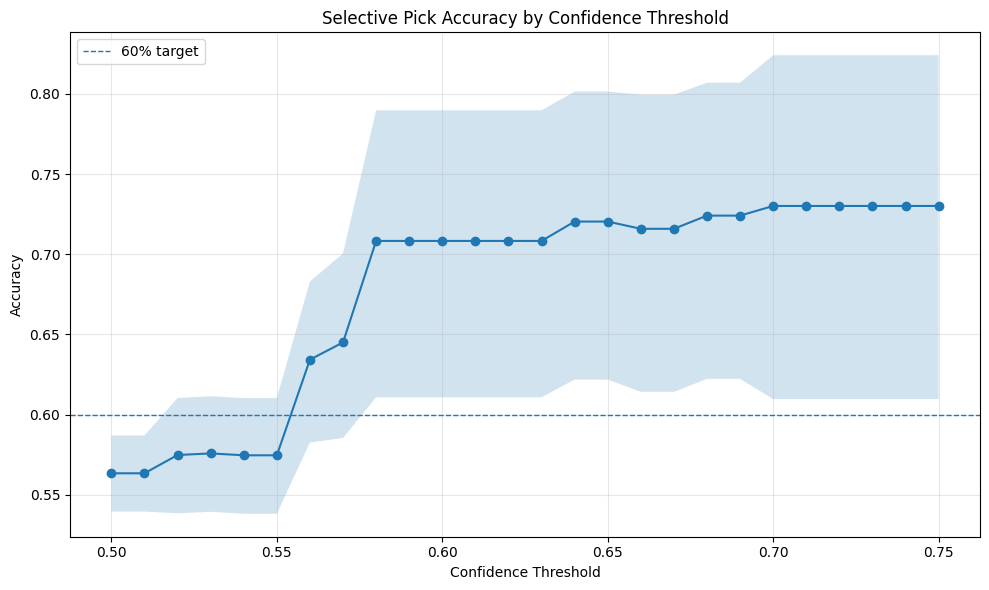

In [53]:
plot_df = selective_accuracy_ci_df[
    selective_accuracy_ci_df["games_picked"] > 0
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    plot_df["confidence_threshold"],
    plot_df["accuracy"],
    marker="o",
)

ax.fill_between(
    plot_df["confidence_threshold"],
    plot_df["accuracy_ci_low"],
    plot_df["accuracy_ci_high"],
    alpha=0.2,
)

ax.axhline(0.60, linestyle="--", linewidth=1, label="60% target")

ax.set_title("Selective Pick Accuracy by Confidence Threshold")
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [54]:
def make_selective_pick_table(test_df, p_home, confidence_threshold=0.57):
    out = test_df.copy()
    out["p_home_win"] = np.clip(p_home, 0.001, 0.999)
    out["p_away_win"] = 1 - out["p_home_win"]

    out["model_pick"] = np.where(
        out["p_home_win"] >= 0.5,
        out["home_team_name"],
        out["away_team_name"],
    )

    out["model_pick_is_home"] = out["p_home_win"] >= 0.5
    out["model_confidence"] = np.maximum(out["p_home_win"], out["p_away_win"])

    out["model_pick_won"] = np.where(
        out["model_pick_is_home"],
        out["target_home_win"].eq(1),
        out["target_home_win"].eq(0),
    ).astype(int)

    picks = out[out["model_confidence"] >= confidence_threshold].copy()

    keep_cols = [
        "official_date",
        "game_pk",
        "away_team_name",
        "home_team_name",
        "model_pick",
        "model_confidence",
        "p_home_win",
        "p_away_win",
        "target_home_win",
        "model_pick_won",
    ]

    keep_cols = [c for c in keep_cols if c in picks.columns]

    return picks[keep_cols].sort_values(
        ["model_confidence", "official_date"],
        ascending=[False, True],
    )

high_conf_picks_057 = make_selective_pick_table(
    test_df,
    p_cal,
    confidence_threshold=0.57,
)

display(high_conf_picks_057.head(50))

print("Picks:", len(high_conf_picks_057))
print("Accuracy:", high_conf_picks_057["model_pick_won"].mean())

,official_date,game_pk,away_team_name,home_team_name,model_pick,model_confidence,p_home_win,p_away_win,target_home_win,model_pick_won
7033,2025-09-09,776389,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
7048,2025-09-10,776380,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
7213,2025-09-23,776212,Colorado Rockies,Seattle Mariners,Seattle Mariners,0.937500,0.937500,0.062500,1.0,1
7369,2026-04-01,822835,Colorado Rockies,Toronto Blue Jays,Toronto Blue Jays,0.937500,0.937500,0.062500,0.0,0
7884,2026-05-10,823463,Colorado Rockies,Philadelphia Phillies,Philadelphia Phillies,0.937500,0.937500,0.062500,1.0,1
8124,2026-05-27,823947,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
6842,2025-08-26,776587,Colorado Rockies,Houston Astros,Houston Astros,0.899142,0.899142,0.100858,0.0,0
7018,2025-09-08,776408,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.865860,0.865860,0.134140,1.0,1
7229,2025-09-24,776194,Colorado Rockies,Seattle Mariners,Seattle Mariners,0.815200,0.815200,0.184800,1.0,1
6897,2025-08-30,776526,Chicago Cubs,Colorado Rockies,Chicago Cubs,0.800000,0.200000,0.800000,0.0,1


Picks: 262
Accuracy: 0.6450381679389313


In [55]:
premium_picks_058 = make_selective_pick_table(
    test_df,
    p_cal,
    confidence_threshold=0.58,
)

display(premium_picks_058.head(50))

print("Picks:", len(premium_picks_058))
print("Accuracy:", premium_picks_058["model_pick_won"].mean())

,official_date,game_pk,away_team_name,home_team_name,model_pick,model_confidence,p_home_win,p_away_win,target_home_win,model_pick_won
7033,2025-09-09,776389,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
7048,2025-09-10,776380,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
7213,2025-09-23,776212,Colorado Rockies,Seattle Mariners,Seattle Mariners,0.937500,0.937500,0.062500,1.0,1
7369,2026-04-01,822835,Colorado Rockies,Toronto Blue Jays,Toronto Blue Jays,0.937500,0.937500,0.062500,0.0,0
7884,2026-05-10,823463,Colorado Rockies,Philadelphia Phillies,Philadelphia Phillies,0.937500,0.937500,0.062500,1.0,1
8124,2026-05-27,823947,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.937500,0.937500,0.062500,1.0,1
6842,2025-08-26,776587,Colorado Rockies,Houston Astros,Houston Astros,0.899142,0.899142,0.100858,0.0,0
7018,2025-09-08,776408,Colorado Rockies,Los Angeles Dodgers,Los Angeles Dodgers,0.865860,0.865860,0.134140,1.0,1
7229,2025-09-24,776194,Colorado Rockies,Seattle Mariners,Seattle Mariners,0.815200,0.815200,0.184800,1.0,1
6897,2025-08-30,776526,Chicago Cubs,Colorado Rockies,Chicago Cubs,0.800000,0.200000,0.800000,0.0,1


Picks: 96
Accuracy: 0.7083333333333334


In [56]:
def make_selective_pick_table(test_df, p_home, confidence_threshold=0.58):
    out = test_df.copy()
    out["p_home_win"] = np.clip(p_home, 0.001, 0.999)
    out["p_away_win"] = 1 - out["p_home_win"]

    out["model_pick"] = np.where(
        out["p_home_win"] >= 0.5,
        out["home_team_name"],
        out["away_team_name"],
    )

    out["model_pick_is_home"] = out["p_home_win"] >= 0.5
    out["model_confidence"] = np.maximum(out["p_home_win"], out["p_away_win"])

    out["model_pick_won"] = np.where(
        out["model_pick_is_home"],
        out["target_home_win"].eq(1),
        out["target_home_win"].eq(0),
    ).astype(int)

    out["season"] = pd.to_datetime(out["official_date"]).dt.year

    picks = out[out["model_confidence"] >= confidence_threshold].copy()

    return picks.sort_values(
        ["model_confidence", "official_date"],
        ascending=[False, True],
    )


premium_picks_058 = make_selective_pick_table(
    test_df,
    p_cal,
    confidence_threshold=0.58,
)

strong_picks_057 = make_selective_pick_table(
    test_df,
    p_cal,
    confidence_threshold=0.57,
)

display(
    premium_picks_058
    .groupby("season")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
)

display(
    strong_picks_057
    .groupby("season")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
)

,picks,accuracy,avg_confidence
season,,,
2025,43,0.767442,0.758413
2026,53,0.660377,0.755030


,picks,accuracy,avg_confidence
season,,,
2025,103,0.689320,0.648874
2026,159,0.616352,0.631924


In [57]:
display(
    premium_picks_058
    .groupby("model_pick_is_home")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
)

,picks,accuracy,avg_confidence
model_pick_is_home,,,
False,34,0.617647,0.715972
True,62,0.758065,0.778795


In [58]:
display(
    premium_picks_058
    .groupby("model_pick")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
    .sort_values("picks", ascending=False)
    .head(30)
)

,picks,accuracy,avg_confidence
model_pick,,,
Los Angeles Dodgers,20,0.700000,0.761958
San Diego Padres,8,0.750000,0.756031
Atlanta Braves,7,0.714286,0.730669
Philadelphia Phillies,7,0.857143,0.784778
Toronto Blue Jays,6,0.166667,0.813826
Houston Astros,6,0.666667,0.771069
Seattle Mariners,5,0.800000,0.798092
New York Yankees,5,1.000000,0.749977
Arizona Diamondbacks,4,0.750000,0.772727


In [59]:
best_model_name = moneyline_accuracy_leaderboard.iloc[0]["model_name"]

print("Best model name:", best_model_name)
print("Best model metadata:")
display(moneyline_fitted[best_model_name].keys())

print("Feature count:")
print(len(moneyline_fitted[best_model_name]["feature_cols"]))

print("Cluster features in best model:")
display([
    c for c in moneyline_fitted[best_model_name]["feature_cols"]
    if "cluster" in c.lower()
])

Best model name: full_non_market__extra_trees
Best model metadata:


dict_keys(['model', 'feature_cols', 'tuned_threshold'])

Feature count:
1987
Cluster features in best model:


['away_team_cluster_recent',
 'home_team_cluster_recent',
 'same_team_cluster_recent']

In [60]:
from sklearn.inspection import permutation_importance

best_model_name = moneyline_accuracy_leaderboard.iloc[0]["model_name"]
base_feature_cols = moneyline_fitted[best_model_name]["feature_cols"]

# Add numeric cluster features if available
cluster_numeric_cols = [
    "home_team_cluster_recent",
    "away_team_cluster_recent",
    "same_team_cluster_recent",
]

for df in [train_df, test_df]:
    for c in cluster_numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(-1).astype(int)

base_feature_cols = list(dict.fromkeys(
    list(base_feature_cols) + [c for c in cluster_numeric_cols if c in train_df.columns]
))

base_feature_cols = [
    c for c in base_feature_cols
    if c in train_df.columns and c in test_df.columns
]

print("Best model:", best_model_name)
print("Starting feature count:", len(base_feature_cols))
print("Cluster features included:")
display([c for c in base_feature_cols if "cluster" in c.lower()])

Best model: full_non_market__extra_trees
Starting feature count: 1987
Cluster features included:


['away_team_cluster_recent',
 'home_team_cluster_recent',
 'same_team_cluster_recent']

In [61]:
train_sorted = train_df.sort_values("official_date").copy()

n = len(train_sorted)

fit_end = int(n * 0.65)
importance_end = int(n * 0.825)

fit_df = train_sorted.iloc[:fit_end].copy()
importance_df = train_sorted.iloc[fit_end:importance_end].copy()
cal_df = train_sorted.iloc[importance_end:].copy()

print("fit_df:", fit_df.shape, fit_df["official_date"].min(), "to", fit_df["official_date"].max())
print("importance_df:", importance_df.shape, importance_df["official_date"].min(), "to", importance_df["official_date"].max())
print("cal_df:", cal_df.shape, cal_df["official_date"].min(), "to", cal_df["official_date"].max())
print("test_df:", test_df.shape, test_df["official_date"].min(), "to", test_df["official_date"].max())

fit_df: (4345, 2142) 2023-03-30 00:00:00 to 2024-08-22 00:00:00
importance_df: (1170, 2142) 2024-08-22 00:00:00 to 2025-05-16 00:00:00
cal_df: (1170, 2142) 2025-05-16 00:00:00 to 2025-08-15 00:00:00
test_df: (1672, 2142) 2025-08-15 00:00:00 to 2026-06-14 00:00:00


In [62]:
rf_params = dict(
    n_estimators=700,
    min_samples_leaf=25,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

base_rf_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(**rf_params)),
])

base_rf_full.fit(fit_df[base_feature_cols], fit_df["target_home_win"])

rf_builtin_importance = pd.DataFrame({
    "feature": base_feature_cols,
    "rf_builtin_importance": base_rf_full.named_steps["model"].feature_importances_,
}).sort_values("rf_builtin_importance", ascending=False)

display(rf_builtin_importance.head(50))

,feature,rf_builtin_importance
1074,diff_starter_starter_statcast_sc_k_rate_season...,0.002662
1981,robust_diff_elo_home_adv,0.002497
1307,diff_team_team_run_diff_season_to_date,0.002473
1980,robust_away_elo_pre,0.002254
988,diff_box_box_box_pitch_whip_last3,0.002171
1984,robust_elo_home_win_prob,0.002153
1323,elo_home_win_prob,0.002078
1322,diff_team_team_win_season_to_date,0.002004
1116,diff_team_ewm_run_diff_hl30,0.001983
989,diff_box_box_box_pitch_whip_last5,0.001967


In [63]:
perm = permutation_importance(
    base_rf_full,
    importance_df[base_feature_cols],
    importance_df["target_home_win"],
    scoring="neg_log_loss",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": base_feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

perm_df["signal_to_noise"] = (
    perm_df["importance_mean"] / perm_df["importance_std"].replace(0, np.nan)
)

perm_df = perm_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(perm_df.head(75))

print("Cluster permutation importance:")
display(
    perm_df[
        perm_df["feature"].str.contains("cluster", case=False, na=False)
    ]
)

,feature,importance_mean,importance_std,signal_to_noise
0,robust_elo_home_win_prob,0.000293,0.000093,3.164575
1,diff_starter_starter_statcast_sc_k_rate_season...,0.000206,0.000160,1.288266
2,diff_box_box_box_pitch_whip_last3,0.000199,0.000115,1.732298
3,diff_team_sc_team_off_sc_pitches_seen_season_t...,0.000192,0.000045,4.245439
4,diff_team_ewm_run_diff_hl30,0.000174,0.000069,2.521275
...,...,...,...,...
70,diff_box_box_box_pitch_balls_season_to_date,0.000059,0.000029,2.071756
71,diff_team_ewm_team_win_hl60,0.000059,0.000034,1.767580
72,away_box_box_box_bat_stolenBases_season_to_date,0.000059,0.000040,1.456983
73,home_box_box_box_pitch_strikes_last20,0.000058,0.000018,3.207267


Cluster permutation importance:


,feature,importance_mean,importance_std,signal_to_noise
139,home_team_cluster_recent,4.288989e-05,0.000016,2.612941
557,away_team_cluster_recent,1.427905e-05,0.000032,0.445154
1048,same_team_cluster_recent,1.865567e-07,0.000002,0.081290


In [64]:
def evaluate_classifier_preds(y_true, p):
    p = np.clip(np.asarray(p), 0.001, 0.999)
    y_true = np.asarray(y_true).astype(int)

    return {
        "log_loss": log_loss(y_true, p),
        "brier": brier_score_loss(y_true, p),
        "auc": roc_auc_score(y_true, p),
        "accuracy": accuracy_score(y_true, p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": y_true.mean(),
    }


def selective_metrics(y_true, p, thresholds=(0.56, 0.57, 0.58, 0.60)):
    y = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(p), 0.001, 0.999)

    pred_home = p >= 0.5
    correct = np.where(pred_home, y == 1, y == 0)
    confidence = np.maximum(p, 1 - p)

    out = {}

    for t in thresholds:
        mask = confidence >= t

        out[f"picks_{t:.2f}"] = int(mask.sum())
        out[f"coverage_{t:.2f}"] = mask.mean()
        out[f"accuracy_{t:.2f}"] = correct[mask].mean() if mask.sum() > 0 else np.nan
        out[f"avg_confidence_{t:.2f}"] = confidence[mask].mean() if mask.sum() > 0 else np.nan

    return out


def fit_calibrated_rf_and_eval(feature_cols, model_label, calibration_method="isotonic"):
    feature_cols = [c for c in feature_cols if c in train_df.columns and c in test_df.columns]
    feature_cols = list(dict.fromkeys(feature_cols))

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(**rf_params)),
    ])

    rf.fit(fit_df[feature_cols], fit_df["target_home_win"])

    if calibration_method == "none":
        final_model = rf
        p_test = rf.predict_proba(test_df[feature_cols])[:, 1]
    else:
        final_model = CalibratedClassifierCV(
            estimator=rf,
            method=calibration_method,
            cv="prefit",
        )

        final_model.fit(cal_df[feature_cols], cal_df["target_home_win"])
        p_test = final_model.predict_proba(test_df[feature_cols])[:, 1]

    p_test = np.clip(p_test, 0.001, 0.999)

    row = {
        "model_label": model_label,
        "calibration": calibration_method,
        "n_features": len(feature_cols),
    }

    row.update(evaluate_classifier_preds(test_df["target_home_win"], p_test))
    row.update(selective_metrics(test_df["target_home_win"], p_test))

    return row, final_model, p_test, feature_cols

In [65]:
positive_perm_features = (
    perm_df
    .query("importance_mean > 0")
    .sort_values("importance_mean", ascending=False)
    ["feature"]
    .tolist()
)

feature_counts_to_test = [25, 50, 75, 100, 150, 200, 300, 500]

trim_results = []
trim_models = {}
trim_probs = {}
trim_feature_sets = {}

for k in feature_counts_to_test:
    cols_k = positive_perm_features[:k]

    if len(cols_k) < 10:
        continue

    for cal_method in ["none", "sigmoid", "isotonic"]:
        label = f"top_{k}_perm"

        row, model, p, used_cols = fit_calibrated_rf_and_eval(
            cols_k,
            model_label=label,
            calibration_method=cal_method,
        )

        key = f"{label}__{cal_method}"

        trim_results.append(row)
        trim_models[key] = model
        trim_probs[key] = p
        trim_feature_sets[key] = used_cols

# Also test full current feature set
for cal_method in ["none", "sigmoid", "isotonic"]:
    row, model, p, used_cols = fit_calibrated_rf_and_eval(
        base_feature_cols,
        model_label="full_feature_set",
        calibration_method=cal_method,
    )

    key = f"full_feature_set__{cal_method}"

    trim_results.append(row)
    trim_models[key] = model
    trim_probs[key] = p
    trim_feature_sets[key] = used_cols

trim_results_df = pd.DataFrame(trim_results)

display(
    trim_results_df
    .sort_values(["accuracy_0.58", "log_loss"], ascending=[False, True])
    .head(30)
)

,model_label,calibration,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
11,top_100_perm,isotonic,100,0.685570,0.246267,0.556731,0.549641,0.528134,0.531699,84,...,0.702381,0.720479,83,0.049641,0.698795,0.722278,62,0.037081,0.709677,0.769113
20,top_300_perm,isotonic,300,0.688892,0.246588,0.557037,0.547249,0.530039,0.531699,540,...,0.690722,0.727679,97,0.058014,0.690722,0.727679,96,0.057416,0.687500,0.729187
17,top_200_perm,isotonic,200,0.685184,0.246191,0.561292,0.549641,0.528865,0.531699,352,...,0.678161,0.764824,87,0.052033,0.678161,0.764824,87,0.052033,0.678161,0.764824
7,top_75_perm,sigmoid,75,0.684431,0.245699,0.565391,0.561005,0.530100,0.531699,391,...,0.615132,0.602920,230,0.137560,0.665217,0.612011,129,0.077153,0.666667,0.629589
2,top_25_perm,isotonic,25,0.688201,0.247553,0.545777,0.543660,0.535384,0.531699,786,...,0.561104,0.590433,149,0.089115,0.664430,0.650713,149,0.089115,0.664430,0.650713
1,top_25_perm,sigmoid,25,0.685638,0.246308,0.552927,0.546651,0.533197,0.531699,401,...,0.624606,0.607357,239,0.142943,0.661088,0.617831,153,0.091507,0.673203,0.633281
14,top_150_perm,isotonic,150,0.690270,0.247129,0.556435,0.545455,0.526200,0.531699,114,...,0.646018,0.725113,111,0.066388,0.657658,0.727852,110,0.065789,0.654545,0.729104
13,top_150_perm,sigmoid,150,0.684279,0.245631,0.563300,0.559211,0.529592,0.531699,380,...,0.618056,0.604017,226,0.135167,0.654867,0.612155,119,0.071172,0.714286,0.632929
26,full_feature_set,isotonic,1987,0.694462,0.246620,0.554092,0.552632,0.527775,0.531699,221,...,0.647059,0.686187,221,0.132177,0.647059,0.686187,221,0.132177,0.647059,0.686187
23,top_500_perm,isotonic,500,0.692099,0.246784,0.553926,0.549641,0.529092,0.531699,326,...,0.641104,0.634737,266,0.159091,0.646617,0.647575,171,0.102273,0.649123,0.682502


In [66]:
display(
    trim_results_df
    .sort_values(
        ["accuracy_0.58", "picks_0.58", "log_loss"],
        ascending=[False, False, True],
    )
    .head(20)
)

,model_label,calibration,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
11,top_100_perm,isotonic,100,0.685570,0.246267,0.556731,0.549641,0.528134,0.531699,84,...,0.702381,0.720479,83,0.049641,0.698795,0.722278,62,0.037081,0.709677,0.769113
20,top_300_perm,isotonic,300,0.688892,0.246588,0.557037,0.547249,0.530039,0.531699,540,...,0.690722,0.727679,97,0.058014,0.690722,0.727679,96,0.057416,0.687500,0.729187
17,top_200_perm,isotonic,200,0.685184,0.246191,0.561292,0.549641,0.528865,0.531699,352,...,0.678161,0.764824,87,0.052033,0.678161,0.764824,87,0.052033,0.678161,0.764824
7,top_75_perm,sigmoid,75,0.684431,0.245699,0.565391,0.561005,0.530100,0.531699,391,...,0.615132,0.602920,230,0.137560,0.665217,0.612011,129,0.077153,0.666667,0.629589
2,top_25_perm,isotonic,25,0.688201,0.247553,0.545777,0.543660,0.535384,0.531699,786,...,0.561104,0.590433,149,0.089115,0.664430,0.650713,149,0.089115,0.664430,0.650713
1,top_25_perm,sigmoid,25,0.685638,0.246308,0.552927,0.546651,0.533197,0.531699,401,...,0.624606,0.607357,239,0.142943,0.661088,0.617831,153,0.091507,0.673203,0.633281
14,top_150_perm,isotonic,150,0.690270,0.247129,0.556435,0.545455,0.526200,0.531699,114,...,0.646018,0.725113,111,0.066388,0.657658,0.727852,110,0.065789,0.654545,0.729104
13,top_150_perm,sigmoid,150,0.684279,0.245631,0.563300,0.559211,0.529592,0.531699,380,...,0.618056,0.604017,226,0.135167,0.654867,0.612155,119,0.071172,0.714286,0.632929
26,full_feature_set,isotonic,1987,0.694462,0.246620,0.554092,0.552632,0.527775,0.531699,221,...,0.647059,0.686187,221,0.132177,0.647059,0.686187,221,0.132177,0.647059,0.686187
23,top_500_perm,isotonic,500,0.692099,0.246784,0.553926,0.549641,0.529092,0.531699,326,...,0.641104,0.634737,266,0.159091,0.646617,0.647575,171,0.102273,0.649123,0.682502


In [67]:
display(
    trim_results_df
    .sort_values(["log_loss", "brier"], ascending=[True, True])
    .head(20)
)

,model_label,calibration,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
15,top_200_perm,none,200,0.683425,0.245280,0.563527,0.546651,0.525691,0.531699,586,...,0.619048,0.618712,381,0.227871,0.629921,0.630371,266,0.159091,0.624060,0.647927
16,top_200_perm,sigmoid,200,0.683667,0.245346,0.563527,0.552632,0.530367,0.531699,423,...,0.635220,0.607730,251,0.150120,0.641434,0.616533,147,0.087919,0.693878,0.635509
12,top_150_perm,none,150,0.684085,0.245576,0.563300,0.552033,0.525439,0.531699,593,...,0.594595,0.621342,401,0.239833,0.610973,0.630504,274,0.163876,0.616788,0.649429
13,top_150_perm,sigmoid,150,0.684279,0.245631,0.563300,0.559211,0.529592,0.531699,380,...,0.618056,0.604017,226,0.135167,0.654867,0.612155,119,0.071172,0.714286,0.632929
7,top_75_perm,sigmoid,75,0.684431,0.245699,0.565391,0.561005,0.530100,0.531699,391,...,0.615132,0.602920,230,0.137560,0.665217,0.612011,129,0.077153,0.666667,0.629589
6,top_75_perm,none,75,0.684441,0.245728,0.565391,0.556220,0.527728,0.531699,642,...,0.598456,0.621382,434,0.259569,0.605991,0.630423,288,0.172249,0.628472,0.651203
19,top_300_perm,sigmoid,300,0.684478,0.245745,0.560390,0.552632,0.530059,0.531699,435,...,0.620991,0.609202,267,0.159689,0.621723,0.619003,166,0.099282,0.668675,0.637180
18,top_300_perm,none,300,0.684598,0.245833,0.560390,0.545455,0.525855,0.531699,558,...,0.616780,0.618540,361,0.215909,0.612188,0.628225,233,0.139354,0.622318,0.649799
22,top_500_perm,sigmoid,500,0.684615,0.245821,0.557291,0.548445,0.528897,0.531699,430,...,0.604585,0.609751,274,0.163876,0.613139,0.619474,175,0.104665,0.674286,0.636474
10,top_100_perm,sigmoid,100,0.684648,0.245806,0.562897,0.552632,0.530537,0.531699,395,...,0.607261,0.601861,225,0.134569,0.626667,0.611281,112,0.066986,0.678571,0.632431


In [68]:
display(
    trim_results_df
    .sort_values(
        ["accuracy_0.57", "picks_0.57", "log_loss"],
        ascending=[False, False, True],
    )
    .head(20)
)

,model_label,calibration,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
11,top_100_perm,isotonic,100,0.685570,0.246267,0.556731,0.549641,0.528134,0.531699,84,...,0.702381,0.720479,83,0.049641,0.698795,0.722278,62,0.037081,0.709677,0.769113
20,top_300_perm,isotonic,300,0.688892,0.246588,0.557037,0.547249,0.530039,0.531699,540,...,0.690722,0.727679,97,0.058014,0.690722,0.727679,96,0.057416,0.687500,0.729187
17,top_200_perm,isotonic,200,0.685184,0.246191,0.561292,0.549641,0.528865,0.531699,352,...,0.678161,0.764824,87,0.052033,0.678161,0.764824,87,0.052033,0.678161,0.764824
26,full_feature_set,isotonic,1987,0.694462,0.246620,0.554092,0.552632,0.527775,0.531699,221,...,0.647059,0.686187,221,0.132177,0.647059,0.686187,221,0.132177,0.647059,0.686187
14,top_150_perm,isotonic,150,0.690270,0.247129,0.556435,0.545455,0.526200,0.531699,114,...,0.646018,0.725113,111,0.066388,0.657658,0.727852,110,0.065789,0.654545,0.729104
23,top_500_perm,isotonic,500,0.692099,0.246784,0.553926,0.549641,0.529092,0.531699,326,...,0.641104,0.634737,266,0.159091,0.646617,0.647575,171,0.102273,0.649123,0.682502
8,top_75_perm,isotonic,75,0.687308,0.247046,0.557215,0.556220,0.530402,0.531699,462,...,0.636364,0.734979,88,0.052632,0.636364,0.734979,88,0.052632,0.636364,0.734979
16,top_200_perm,sigmoid,200,0.683667,0.245346,0.563527,0.552632,0.530367,0.531699,423,...,0.635220,0.607730,251,0.150120,0.641434,0.616533,147,0.087919,0.693878,0.635509
1,top_25_perm,sigmoid,25,0.685638,0.246308,0.552927,0.546651,0.533197,0.531699,401,...,0.624606,0.607357,239,0.142943,0.661088,0.617831,153,0.091507,0.673203,0.633281
19,top_300_perm,sigmoid,300,0.684478,0.245745,0.560390,0.552632,0.530059,0.531699,435,...,0.620991,0.609202,267,0.159689,0.621723,0.619003,166,0.099282,0.668675,0.637180


In [69]:
winner_key = (
    trim_results_df
    .sort_values(["accuracy_0.58", "picks_0.58", "log_loss"], ascending=[False, False, True])
    .iloc[0]
)

winner_model_key = f"{winner_key['model_label']}__{winner_key['calibration']}"

print("Winner:", winner_model_key)
print("Metrics:")
display(winner_key.to_frame("value"))

winner_features = trim_feature_sets[winner_model_key]

print("Winning feature count:", len(winner_features))

winner_feature_table = (
    perm_df[perm_df["feature"].isin(winner_features)]
    .sort_values("importance_mean", ascending=False)
)

display(winner_feature_table)

print("Cluster features in winner:")
display([c for c in winner_features if "cluster" in c.lower()])

Winner: top_100_perm__isotonic
Metrics:


,value
model_label,top_100_perm
calibration,isotonic
n_features,100
log_loss,0.68557
brier,0.246267
auc,0.556731
accuracy,0.549641
avg_pred,0.528134
actual_mean,0.531699
picks_0.56,84


Winning feature count: 100


,feature,importance_mean,importance_std,signal_to_noise
0,robust_elo_home_win_prob,0.000293,0.000093,3.164575
1,diff_starter_starter_statcast_sc_k_rate_season...,0.000206,0.000160,1.288266
2,diff_box_box_box_pitch_whip_last3,0.000199,0.000115,1.732298
3,diff_team_sc_team_off_sc_pitches_seen_season_t...,0.000192,0.000045,4.245439
4,diff_team_ewm_run_diff_hl30,0.000174,0.000069,2.521275
...,...,...,...,...
95,away_starter_starter_statcast_sc_avg_extension...,0.000052,0.000018,2.834632
96,home_box_box_box_bat_rbi_season_to_date,0.000052,0.000020,2.531449
97,diff_starter_starter_statcast_sc_pitches_last5,0.000052,0.000046,1.129359
98,home_box_box_box_pitch_flyOuts_last20,0.000052,0.000030,1.713485


Cluster features in winner:


[]

In [71]:
# ------------------------------------------------------------
# Fair retest of top 100 permutation features using 80/20 train/cal split
# ------------------------------------------------------------

top_100_perm_features = (
    perm_df
    .sort_values("importance_mean", ascending=False)
    .head(100)["feature"]
    .tolist()
)

# Optional: force in the best cluster feature since it had positive importance
force_cols = [
    "home_team_cluster_recent",
]

top_100_plus_features = list(dict.fromkeys(
    top_100_perm_features + [c for c in force_cols if c in train_df.columns]
))

train_df_sorted = train_df.sort_values("official_date").copy()

cal_split = int(len(train_df_sorted) * 0.80)

fit_df_80 = train_df_sorted.iloc[:cal_split].copy()
cal_df_20 = train_df_sorted.iloc[cal_split:].copy()

print("fit_df_80:", fit_df_80.shape, fit_df_80["official_date"].min(), "to", fit_df_80["official_date"].max())
print("cal_df_20:", cal_df_20.shape, cal_df_20["official_date"].min(), "to", cal_df_20["official_date"].max())
print("test_df:", test_df.shape, test_df["official_date"].min(), "to", test_df["official_date"].max())
print("Feature count:", len(top_100_plus_features))

base_rf_top100 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

base_rf_top100.fit(
    fit_df_80[top_100_plus_features],
    fit_df_80["target_home_win"],
)

calibrated_rf_top100 = CalibratedClassifierCV(
    estimator=base_rf_top100,
    method="isotonic",
    cv="prefit",
)

calibrated_rf_top100.fit(
    cal_df_20[top_100_plus_features],
    cal_df_20["target_home_win"],
)

p_top100_cal = calibrated_rf_top100.predict_proba(
    test_df[top_100_plus_features]
)[:, 1]

top100_cal_compare = pd.DataFrame([
    {
        "model": "full_rf_isotonic_existing",
        "n_features": len(best_cal_cols),
        **evaluate_classifier_preds(test_df["target_home_win"], p_cal),
        **selective_metrics(test_df["target_home_win"], p_cal),
    },
    {
        "model": "top100_perm_plus_home_cluster_isotonic",
        "n_features": len(top_100_plus_features),
        **evaluate_classifier_preds(test_df["target_home_win"], p_top100_cal),
        **selective_metrics(test_df["target_home_win"], p_top100_cal),
    },
])

display(
    top100_cal_compare.sort_values(
        ["accuracy_0.58", "picks_0.58", "log_loss"],
        ascending=[False, False, True],
    )
)

feature_report = (
    perm_df
    .assign(
        selected_top100=lambda x: x["feature"].isin(top_100_perm_features),
        selected_top100_plus=lambda x: x["feature"].isin(top_100_plus_features),
    )
    .sort_values("importance_mean", ascending=False)
)

display(feature_report.head(100))

feature_report.to_csv(
    OUTPUT_DIR / "top100_permutation_feature_report.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "top100_permutation_feature_report.csv")

fit_df_80: (5348, 2142) 2023-03-30 00:00:00 to 2025-05-03 00:00:00
cal_df_20: (1337, 2142) 2025-05-03 00:00:00 to 2025-08-15 00:00:00
test_df: (1672, 2142) 2025-08-15 00:00:00 to 2026-06-14 00:00:00
Feature count: 101


,model,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,coverage_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
0,full_rf_isotonic_existing,1987,0.684797,0.245677,0.556451,0.563397,0.525873,0.531699,350,0.20933,...,0.645038,0.638587,96,0.057416,0.708333,0.756545,96,0.057416,0.708333,0.756545
1,top100_perm_plus_home_cluster_isotonic,101,0.690351,0.246102,0.560001,0.552632,0.523436,0.531699,303,0.18122,...,0.623762,0.630092,303,0.181220,0.623762,0.630092,106,0.063397,0.669811,0.719584


,feature,importance_mean,importance_std,signal_to_noise,selected_top100,selected_top100_plus
0,robust_elo_home_win_prob,0.000293,0.000093,3.164575,True,True
1,diff_starter_starter_statcast_sc_k_rate_season...,0.000206,0.000160,1.288266,True,True
2,diff_box_box_box_pitch_whip_last3,0.000199,0.000115,1.732298,True,True
3,diff_team_sc_team_off_sc_pitches_seen_season_t...,0.000192,0.000045,4.245439,True,True
4,diff_team_ewm_run_diff_hl30,0.000174,0.000069,2.521275,True,True
...,...,...,...,...,...,...
95,away_starter_starter_statcast_sc_avg_extension...,0.000052,0.000018,2.834632,True,True
96,home_box_box_box_bat_rbi_season_to_date,0.000052,0.000020,2.531449,True,True
97,diff_starter_starter_statcast_sc_pitches_last5,0.000052,0.000046,1.129359,True,True
98,home_box_box_box_pitch_flyOuts_last20,0.000052,0.000030,1.713485,True,True


Saved: mlb_local_outputs\top100_permutation_feature_report.csv


In [72]:
feature_counts_to_test = [100, 150, 200, 300, 500, 750, 1000, 1500]

soft_trim_results = []

for k in feature_counts_to_test:
    cols_k = (
        perm_df
        .sort_values("importance_mean", ascending=False)
        .head(k)["feature"]
        .tolist()
    )

    # Optionally force in the best cluster feature
    cols_k = list(dict.fromkeys(
        cols_k + [c for c in ["home_team_cluster_recent"] if c in train_df.columns]
    ))

    for cal_method in ["sigmoid", "isotonic"]:
        rf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=700,
                min_samples_leaf=25,
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])

        rf.fit(fit_df_80[cols_k], fit_df_80["target_home_win"])

        cal_model = CalibratedClassifierCV(
            estimator=rf,
            method=cal_method,
            cv="prefit",
        )

        cal_model.fit(cal_df_20[cols_k], cal_df_20["target_home_win"])

        p = cal_model.predict_proba(test_df[cols_k])[:, 1]
        p = np.clip(p, 0.001, 0.999)

        row = {
            "model": f"top_{k}_perm_plus_home_cluster",
            "calibration": cal_method,
            "n_features": len(cols_k),
        }

        row.update(evaluate_classifier_preds(test_df["target_home_win"], p))
        row.update(selective_metrics(test_df["target_home_win"], p))

        soft_trim_results.append(row)

# Add full model reference
full_ref = {
    "model": "full_rf_isotonic_existing",
    "calibration": "isotonic",
    "n_features": len(best_cal_cols),
}
full_ref.update(evaluate_classifier_preds(test_df["target_home_win"], p_cal))
full_ref.update(selective_metrics(test_df["target_home_win"], p_cal))
soft_trim_results.append(full_ref)

soft_trim_results_df = pd.DataFrame(soft_trim_results)

display(
    soft_trim_results_df
    .sort_values(
        ["accuracy_0.58", "picks_0.58", "log_loss"],
        ascending=[False, False, True],
    )
)

,model,calibration,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean,picks_0.56,...,accuracy_0.57,avg_confidence_0.57,picks_0.58,coverage_0.58,accuracy_0.58,avg_confidence_0.58,picks_0.60,coverage_0.60,accuracy_0.60,avg_confidence_0.60
16,full_rf_isotonic_existing,isotonic,1987,0.684797,0.245677,0.556451,0.563397,0.525873,0.531699,350,...,0.645038,0.638587,96,0.057416,0.708333,0.756545,96,0.057416,0.708333,0.756545
5,top_200_perm_plus_home_cluster,isotonic,200,0.687017,0.246678,0.555237,0.556220,0.525812,0.531699,312,...,0.662791,0.793897,81,0.048445,0.679012,0.807629,80,0.047847,0.687500,0.810320
9,top_500_perm_plus_home_cluster,isotonic,500,0.697836,0.246580,0.551593,0.546053,0.525139,0.531699,374,...,0.644654,0.656864,318,0.190191,0.644654,0.656864,146,0.087321,0.678082,0.739561
7,top_300_perm_plus_home_cluster,isotonic,300,0.690511,0.246184,0.558722,0.554426,0.524961,0.531699,271,...,0.633333,0.660530,270,0.161483,0.633333,0.660530,266,0.159091,0.631579,0.661584
8,top_500_perm_plus_home_cluster,sigmoid,500,0.684298,0.245660,0.560516,0.555024,0.525970,0.531699,555,...,0.623786,0.606486,319,0.190789,0.633229,0.615765,188,0.112440,0.643617,0.634564
10,top_750_perm_plus_home_cluster,sigmoid,750,0.683979,0.245496,0.561619,0.541866,0.526411,0.531699,515,...,0.625316,0.605322,294,0.175837,0.632653,0.615786,177,0.105861,0.649718,0.633700
11,top_750_perm_plus_home_cluster,isotonic,750,0.693127,0.244833,0.559834,0.564593,0.526213,0.531699,445,...,0.632353,0.660522,272,0.162679,0.632353,0.660522,137,0.081938,0.686131,0.737271
6,top_300_perm_plus_home_cluster,sigmoid,300,0.684801,0.245898,0.558233,0.544258,0.526159,0.531699,510,...,0.615183,0.607142,298,0.178230,0.630872,0.616210,176,0.105263,0.642045,0.635125
2,top_150_perm_plus_home_cluster,sigmoid,150,0.684433,0.245712,0.562141,0.554426,0.526279,0.531699,508,...,0.610256,0.605481,307,0.183612,0.628664,0.613879,169,0.101077,0.639053,0.633940
1,top_100_perm_plus_home_cluster,isotonic,101,0.690351,0.246102,0.560001,0.552632,0.523436,0.531699,303,...,0.623762,0.630092,303,0.181220,0.623762,0.630092,106,0.063397,0.669811,0.719584


In [73]:
def _wilson_ci(k, n, alpha=0.05):
    """
    Wilson confidence interval for a binomial proportion.
    Defaults to 95% CI.
    """
    if n == 0 or pd.isna(n):
        return np.nan, np.nan

    # 95% z-score by default. Good enough for this use case.
    if alpha == 0.05:
        z = 1.959963984540054
    else:
        try:
            from scipy.stats import norm
            z = norm.ppf(1 - alpha / 2)
        except Exception:
            z = 1.959963984540054

    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (
        z
        * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
        / denom
    )

    return max(0, center - margin), min(1, center + margin)


def calibration_table_fixed_bins(
    y_true,
    p_pred,
    n_bins=10,
    bins=None,
    alpha=0.05,
    include_empty_bins=True,
):
    """
    Build a fixed-bin calibration table.

    Parameters
    ----------
    y_true : array-like
        Binary actual target values, 0/1.
    p_pred : array-like
        Predicted probabilities for class 1.
    n_bins : int
        Number of probability bins if bins is not provided.
    bins : array-like or None
        Custom bin edges. Example: np.linspace(0, 1, 11)
    alpha : float
        Confidence interval alpha. 0.05 gives 95% CI.
    include_empty_bins : bool
        Whether to include bins with zero observations.

    Returns
    -------
    pd.DataFrame
        Calibration summary by predicted-probability bin.
    """

    df = pd.DataFrame({
        "y_true": pd.Series(y_true).astype(float).values,
        "p_pred": pd.Series(p_pred).astype(float).values,
    })

    df = df.replace([np.inf, -np.inf], np.nan).dropna().copy()

    df["y_true"] = df["y_true"].astype(int)
    df["p_pred"] = np.clip(df["p_pred"], 0.0, 1.0)

    if bins is None:
        bins = np.linspace(0, 1, n_bins + 1)
    else:
        bins = np.asarray(bins, dtype=float)

    df["prob_bin"] = pd.cut(
        df["p_pred"],
        bins=bins,
        include_lowest=True,
        right=True,
    )

    rows = []

    categories = df["prob_bin"].cat.categories

    for interval in categories:
        g = df[df["prob_bin"].eq(interval)].copy()

        n = len(g)
        bin_low = interval.left
        bin_high = interval.right

        if n == 0:
            if include_empty_bins:
                rows.append({
                    "prob_bin": str(interval),
                    "bin_low": bin_low,
                    "bin_high": bin_high,
                    "n": 0,
                    "avg_pred": np.nan,
                    "actual_rate": np.nan,
                    "correct": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                    "pred_min": np.nan,
                    "pred_max": np.nan,
                })
            continue

        actual_rate = g["y_true"].mean()
        correct = int(g["y_true"].sum())
        ci_low, ci_high = _wilson_ci(correct, n, alpha=alpha)

        rows.append({
            "prob_bin": str(interval),
            "bin_low": bin_low,
            "bin_high": bin_high,
            "n": n,
            "avg_pred": g["p_pred"].mean(),
            "actual_rate": actual_rate,
            "correct": correct,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "pred_min": g["p_pred"].min(),
            "pred_max": g["p_pred"].max(),
        })

    cal_tbl = pd.DataFrame(rows)

    return cal_tbl

winner_p = trim_probs[winner_model_key]

cal_tbl_fine = calibration_table_fixed_bins(
    test_df["target_home_win"],
    winner_p,
    bins=[0.00, 0.40, 0.45, 0.50, 0.55, 0.58, 0.60, 0.65, 0.70, 0.80, 1.00],
)

display(cal_tbl_fine)

,prob_bin,bin_low,bin_high,n,avg_pred,actual_rate,correct,ci_low,ci_high,pred_min,pred_max
0,"(-0.001, 0.4]",-0.001,0.40,3,0.285714,0.666667,2.0,0.207660,0.938508,0.285714,0.285714
1,"(0.4, 0.45]",0.400,0.45,22,0.417121,0.318182,7.0,0.163606,0.526814,0.402214,0.440748
2,"(0.45, 0.5]",0.450,0.50,485,0.475068,0.476289,231.0,0.432201,0.520749,0.454892,0.498472
3,"(0.5, 0.55]",0.500,0.55,821,0.536871,0.540804,444.0,0.506605,0.574622,0.530807,0.537698
4,"(0.55, 0.58]",0.550,0.58,282,0.554200,0.574468,162.0,0.516141,0.630793,0.554140,0.571103
5,"(0.58, 0.6]",0.580,0.60,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"(0.6, 0.65]",0.600,0.65,2,0.604553,1.000000,2.0,0.342380,1.000000,0.602775,0.606332
7,"(0.65, 0.7]",0.650,0.70,7,0.671485,0.571429,4.0,0.250458,0.841780,0.666667,0.697023
8,"(0.7, 0.8]",0.700,0.80,48,0.788500,0.729167,35.0,0.590030,0.834340,0.745167,0.800000
9,"(0.8, 1.0]",0.800,1.00,2,0.892331,1.000000,2.0,0.342380,1.000000,0.873785,0.910876


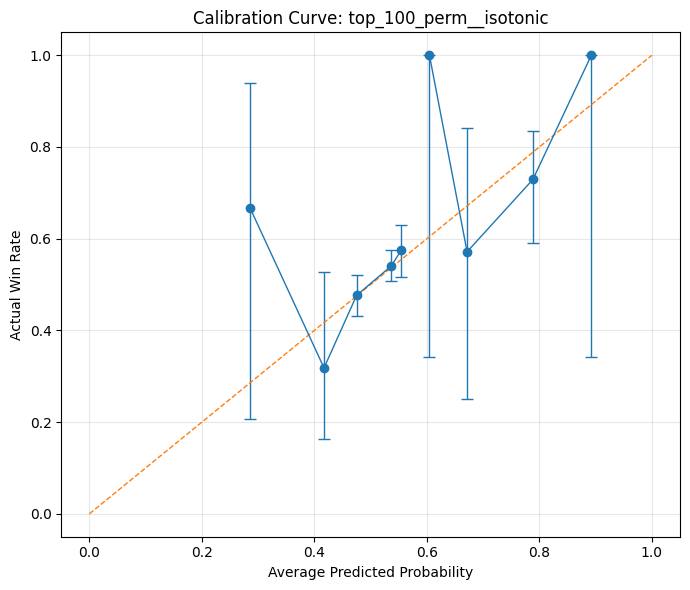

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.errorbar(
    cal_tbl_fine["avg_pred"],
    cal_tbl_fine["actual_rate"],
    yerr=[
        cal_tbl_fine["actual_rate"] - cal_tbl_fine["ci_low"],
        cal_tbl_fine["ci_high"] - cal_tbl_fine["actual_rate"],
    ],
    marker="o",
    capsize=4,
    linewidth=1,
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_title(f"Calibration Curve: {winner_model_key}")
ax.set_xlabel("Average Predicted Probability")
ax.set_ylabel("Actual Win Rate")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
def selected_side_calibration_table(y_true, p_home, n_bins=10, bins=None):
    y = np.asarray(y_true).astype(int)
    p_home = np.clip(np.asarray(p_home), 0.001, 0.999)

    pick_home = p_home >= 0.5
    pick_prob = np.where(pick_home, p_home, 1 - p_home)
    pick_won = np.where(pick_home, y == 1, y == 0).astype(int)

    return calibration_table_fixed_bins(
        pick_won,
        pick_prob,
        n_bins=n_bins,
        bins=bins,
    )

selected_cal_full = selected_side_calibration_table(
    test_df["target_home_win"],
    p_cal,
    bins=[0.50, 0.55, 0.56, 0.57, 0.58, 0.60, 0.65, 0.70, 0.80, 1.00],
)

display(selected_cal_full)

,prob_bin,bin_low,bin_high,n,avg_pred,actual_rate,correct,ci_low,ci_high,pred_min,pred_max
0,"(0.499, 0.55]",0.499,0.55,955,0.515024,0.554974,530.0,0.523297,0.586210,0.514196,0.533830
1,"(0.55, 0.56]",0.550,0.56,367,0.556307,0.517711,190.0,0.466670,0.568385,0.551445,0.559866
2,"(0.56, 0.57]",0.560,0.57,88,0.561218,0.602273,53.0,0.497807,0.698183,0.560696,0.561224
3,"(0.57, 0.58]",0.570,0.58,166,0.570370,0.608434,101.0,0.532534,0.679429,0.570370,0.570370
4,"(0.58, 0.6]",0.580,0.60,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"(0.6, 0.65]",0.600,0.65,3,0.636364,0.333333,1.0,0.061492,0.792340,0.636364,0.636364
6,"(0.65, 0.7]",0.650,0.70,30,0.685402,0.700000,21.0,0.521242,0.833353,0.651587,0.692308
7,"(0.7, 0.8]",0.700,0.80,54,0.776889,0.722222,39.0,0.591096,0.823832,0.772727,0.800000
8,"(0.8, 1.0]",0.800,1.00,9,0.911689,0.777778,7.0,0.452589,0.936775,0.815200,0.937500


In [78]:
conf = np.maximum(p_cal, 1 - p_cal)

conf_dist = (
    pd.Series(np.round(conf, 6), name="model_confidence")
    .value_counts()
    .sort_index()
    .reset_index()
)

conf_dist.columns = ["model_confidence", "games"]

display(conf_dist.tail(30))

thresholds_to_test = [0.56, 0.57, 0.65, 0.70]

for t in thresholds_to_test:
    mask = conf >= t
    y = test_df["target_home_win"].astype(int).values
    pred_home = p_cal >= 0.5
    correct = np.where(pred_home, y == 1, y == 0)

    print(
        f"threshold >= {t:.2f} | "
        f"picks={mask.sum()} | "
        f"coverage={mask.mean():.2%} | "
        f"accuracy={correct[mask].mean():.3f} | "
        f"avg_conf={conf[mask].mean():.3f}"
    )

,model_confidence,games
3,0.516129,370
4,0.521994,1
5,0.522951,1
6,0.525177,1
7,0.530167,1
8,0.533830,1
9,0.551445,1
10,0.552909,1
11,0.555556,31
12,0.556265,1


threshold >= 0.56 | picks=350 | coverage=20.93% | accuracy=0.634 | avg_conf=0.619
threshold >= 0.57 | picks=262 | coverage=15.67% | accuracy=0.645 | avg_conf=0.639
threshold >= 0.65 | picks=93 | coverage=5.56% | accuracy=0.720 | avg_conf=0.760
threshold >= 0.70 | picks=63 | coverage=3.77% | accuracy=0.730 | avg_conf=0.796


In [79]:
def assign_pick_tier(conf):
    if conf >= 0.70:
        return "Elite"
    elif conf >= 0.65:
        return "Premium"
    elif conf >= 0.57:
        return "Strong"
    elif conf >= 0.56:
        return "Lean"
    else:
        return "Pass"


tiered_picks = test_df.copy()

tiered_picks["p_home_win"] = np.clip(p_cal, 0.001, 0.999)
tiered_picks["p_away_win"] = 1 - tiered_picks["p_home_win"]

tiered_picks["model_pick_is_home"] = tiered_picks["p_home_win"] >= 0.5
tiered_picks["model_pick"] = np.where(
    tiered_picks["model_pick_is_home"],
    tiered_picks["home_team_name"],
    tiered_picks["away_team_name"],
)

tiered_picks["model_confidence"] = np.maximum(
    tiered_picks["p_home_win"],
    tiered_picks["p_away_win"],
)

tiered_picks["pick_tier"] = tiered_picks["model_confidence"].apply(assign_pick_tier)

tiered_picks["model_pick_won"] = np.where(
    tiered_picks["model_pick_is_home"],
    tiered_picks["target_home_win"].eq(1),
    tiered_picks["target_home_win"].eq(0),
).astype(int)

tier_summary = (
    tiered_picks
    .groupby("pick_tier")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
    .reindex(["Elite", "Premium", "Strong", "Lean", "Pass"])
)

display(tier_summary)

,picks,accuracy,avg_confidence
pick_tier,,,
Elite,63,0.730159,0.796146
Premium,30,0.700000,0.685402
Strong,169,0.603550,0.571542
Lean,88,0.602273,0.561218
Pass,1322,0.544629,0.526485


## 18.3 let's productionalize

In [ ]:
import joblib

def _wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return np.nan, np.nan

    z = 1.959963984540054
    p = k / n

    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (
        z
        * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
        / denom
    )

    return max(0, center - margin), min(1, center + margin)


def build_selected_side_threshold_table(y_true, p_home, round_confidence=6):
    """
    Builds cumulative selected-side performance by model confidence.

    This evaluates the side the model picked:
      if p_home >= .50, selected side = home
      else selected side = away
    """

    y = np.asarray(y_true).astype(int)
    p_home = np.clip(np.asarray(p_home, dtype=float), 0.001, 0.999)

    pick_home = p_home >= 0.5
    confidence = np.maximum(p_home, 1.0 - p_home)

    selected_side_won = np.where(
        pick_home,
        y == 1,
        y == 0,
    ).astype(int)

    thresholds = np.sort(np.unique(np.round(confidence, round_confidence)))
    thresholds = thresholds[thresholds >= 0.5]

    rows = []

    for t in thresholds:
        mask = confidence >= t
        n = int(mask.sum())

        if n == 0:
            continue

        k = int(selected_side_won[mask].sum())
        acc = k / n
        ci_low, ci_high = _wilson_ci(k, n)

        rows.append({
            "confidence_threshold": float(t),
            "games_picked": n,
            "coverage": n / len(y),
            "accuracy": acc,
            "estimated_correct": k,
            "avg_confidence": float(confidence[mask].mean()),
            "accuracy_ci_low": ci_low,
            "accuracy_ci_high": ci_high,
        })

    return pd.DataFrame(rows).sort_values("confidence_threshold").reset_index(drop=True)

def learn_pick_tiers_from_validation(
    y_true,
    p_home,
    tier_policy=None,
    round_confidence=6,
):
    """
    Learns tier cutoffs from validation results.

    This does NOT hard-code tier thresholds like .56/.57/.65/.70.
    It learns the thresholds from selected-side validation performance.
    """

    threshold_df = build_selected_side_threshold_table(
        y_true=y_true,
        p_home=p_home,
        round_confidence=round_confidence,
    )

    assert len(threshold_df) > 0, "No threshold rows were produced."

    n_total = int(threshold_df["games_picked"].max())

    # These are policy rules, not hard-coded thresholds.
    # The actual confidence cutoffs are learned from the validation data.
    if tier_policy is None:
        tier_policy = {
            "Lean": {
                "lift_frac": 0.20,
                "min_coverage": 0.10,
            },
            "Strong": {
                "lift_frac": 0.35,
                "min_coverage": 0.07,
            },
            "Premium": {
                "lift_frac": 0.70,
                "min_coverage": 0.03,
            },
            "Elite": {
                "lift_frac": 0.95,
                "min_coverage": 0.02,
            },
        }

    baseline_row = threshold_df.iloc[0]
    baseline_accuracy = float(baseline_row["accuracy"])

    # Use only reasonably stable rows to define the top-end model performance.
    min_stable_picks = max(20, int(0.02 * n_total))
    stable_df = threshold_df[threshold_df["games_picked"] >= min_stable_picks].copy()

    if len(stable_df) == 0:
        stable_df = threshold_df.copy()

    best_stable_accuracy = float(stable_df["accuracy"].max())
    performance_lift = max(0.0, best_stable_accuracy - baseline_accuracy)

    learned_tiers = []
    previous_threshold = 0.5

    for tier_name, rules in tier_policy.items():
        target_accuracy = baseline_accuracy + rules["lift_frac"] * performance_lift
        min_picks = max(1, int(np.ceil(rules["min_coverage"] * n_total)))

        candidates = threshold_df[
            (threshold_df["confidence_threshold"] > previous_threshold)
            & (threshold_df["games_picked"] >= min_picks)
            & (threshold_df["accuracy"] >= target_accuracy)
        ].copy()

        if len(candidates) == 0:
            # Fallback: choose the best available threshold above the prior tier.
            candidates = threshold_df[
                (threshold_df["confidence_threshold"] > previous_threshold)
                & (threshold_df["games_picked"] >= min_picks)
            ].copy()

            if len(candidates) == 0:
                continue

            chosen = (
                candidates
                .sort_values(["accuracy", "games_picked"], ascending=[False, False])
                .iloc[0]
            )
        else:
            # Choose the lowest threshold that satisfies the target.
            # This maximizes volume while meeting the tier requirement.
            chosen = (
                candidates
                .sort_values("confidence_threshold", ascending=True)
                .iloc[0]
            )

        learned_tiers.append({
            "tier": tier_name,
            "threshold": float(chosen["confidence_threshold"]),
            "validation_games_picked": int(chosen["games_picked"]),
            "validation_coverage": float(chosen["coverage"]),
            "validation_accuracy": float(chosen["accuracy"]),
            "validation_accuracy_ci_low": float(chosen["accuracy_ci_low"]),
            "validation_accuracy_ci_high": float(chosen["accuracy_ci_high"]),
            "validation_avg_confidence": float(chosen["avg_confidence"]),
            "target_accuracy_used": float(target_accuracy),
            "min_picks_used": int(min_picks),
        })

        previous_threshold = float(chosen["confidence_threshold"])

    pick_tiers = {
        "method": "selected_side_validation_threshold_learning_v1",
        "baseline_accuracy": baseline_accuracy,
        "best_stable_accuracy": best_stable_accuracy,
        "performance_lift": performance_lift,
        "tier_policy": tier_policy,
        "tiers": learned_tiers,
        "default_tier": "Pass",
    }

    return pick_tiers, threshold_df

train_df_sorted = train_df.sort_values("official_date").copy()

n = len(train_df_sorted)

fit_end = int(n * 0.70)
cal_end = int(n * 0.85)

fit_df_prod = train_df_sorted.iloc[:fit_end].copy()
cal_df_prod = train_df_sorted.iloc[fit_end:cal_end].copy()
tier_df_prod = train_df_sorted.iloc[cal_end:].copy()

print("fit:", fit_df_prod["official_date"].min(), "to", fit_df_prod["official_date"].max(), fit_df_prod.shape)
print("cal:", cal_df_prod["official_date"].min(), "to", cal_df_prod["official_date"].max(), cal_df_prod.shape)
print("tier:", tier_df_prod["official_date"].min(), "to", tier_df_prod["official_date"].max(), tier_df_prod.shape)
print("test:", test_df["official_date"].min(), "to", test_df["official_date"].max(), test_df.shape)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

base_rf_prod = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

base_rf_prod.fit(
    fit_df_prod[best_cal_cols],
    fit_df_prod["target_home_win"],
)

calibrated_rf_prod = CalibratedClassifierCV(
    estimator=base_rf_prod,
    method="isotonic",
    cv="prefit",
)

calibrated_rf_prod.fit(
    cal_df_prod[best_cal_cols],
    cal_df_prod["target_home_win"],
)

p_tier = calibrated_rf_prod.predict_proba(
    tier_df_prod[best_cal_cols]
)[:, 1]

learned_pick_tiers, tier_threshold_df = learn_pick_tiers_from_validation(
    y_true=tier_df_prod["target_home_win"],
    p_home=p_tier,
)

display(tier_threshold_df)
display(pd.DataFrame(learned_pick_tiers["tiers"]))

learned_pick_tiers

def assign_pick_tier_from_learned_tiers(confidence, learned_pick_tiers):
    if pd.isna(confidence):
        return learned_pick_tiers.get("default_tier", "Pass")

    tiers = sorted(
        learned_pick_tiers["tiers"],
        key=lambda x: x["threshold"],
        reverse=True,
    )

    for tier_info in tiers:
        if confidence >= tier_info["threshold"]:
            return tier_info["tier"]

    return learned_pick_tiers.get("default_tier", "Pass")


p_test_prod = calibrated_rf_prod.predict_proba(
    test_df[best_cal_cols]
)[:, 1]

test_tiered = test_df.copy()
test_tiered["p_home_win"] = np.clip(p_test_prod, 0.001, 0.999)
test_tiered["p_away_win"] = 1.0 - test_tiered["p_home_win"]

test_tiered["model_pick_is_home"] = test_tiered["p_home_win"] >= 0.5

test_tiered["model_confidence"] = np.maximum(
    test_tiered["p_home_win"],
    test_tiered["p_away_win"],
)

test_tiered["pick_tier"] = test_tiered["model_confidence"].apply(
    lambda x: assign_pick_tier_from_learned_tiers(x, learned_pick_tiers)
)

test_tiered["model_pick_won"] = np.where(
    test_tiered["model_pick_is_home"],
    test_tiered["target_home_win"].eq(1),
    test_tiered["target_home_win"].eq(0),
).astype(int)

tier_eval = (
    test_tiered
    .groupby("pick_tier")
    .agg(
        picks=("game_pk", "count"),
        accuracy=("model_pick_won", "mean"),
        avg_confidence=("model_confidence", "mean"),
    )
)

display(tier_eval)

bundle = {
    "estimator": calibrated_rf_prod,
    "feature_cols": list(best_cal_cols),
    "target_col": "target_home_win",
    "model_family": "random_forest_isotonic_calibrated",
    "pick_tiers": learned_pick_tiers,
}

p_home = calibrated_rf_prod.predict_proba(tier_df_prod[best_cal_cols])[:, 1]

bundle = joblib.load(model_path)

model = bundle["estimator"]
feature_cols = bundle["feature_cols"]
pick_tiers = bundle["pick_tiers"]

confidence = max(p_home, 1 - p_home)
pick_tier = assign_pick_tier_from_learned_tiers(confidence, pick_tiers)

fit: 2023-03-30 00:00:00 to 2024-09-16 00:00:00 (4679, 2142)
cal: 2024-09-16 00:00:00 to 2025-05-28 00:00:00 (1003, 2142)
tier: 2025-05-28 00:00:00 to 2025-08-15 00:00:00 (1003, 2142)
test: 2025-08-15 00:00:00 to 2026-06-14 00:00:00 (1672, 2142)


,confidence_threshold,games_picked,coverage,accuracy,estimated_correct,avg_confidence,accuracy_ci_low,accuracy_ci_high
0,0.518987,1003,1.000000,0.539382,541,0.602143,0.508443,0.570020
1,0.533101,932,0.929212,0.542918,506,0.608477,0.510826,0.574659
2,0.562500,676,0.673978,0.539941,365,0.637022,0.502250,0.577181
3,0.574599,664,0.662014,0.540663,359,0.638351,0.502633,0.578225
4,0.578080,663,0.661017,0.541478,359,0.638442,0.503420,0.579059
5,0.586757,662,0.660020,0.542296,359,0.638520,0.504209,0.579895
6,0.609302,662,0.660020,0.542296,359,0.638520,0.504209,0.579895
7,0.611374,465,0.463609,0.552688,257,0.650898,0.507247,0.597266
8,0.621951,201,0.200399,0.582090,117,0.702810,0.512990,0.648110
9,0.657249,106,0.105683,0.650943,69,0.774945,0.556366,0.734963


,tier,threshold,validation_games_picked,validation_coverage,validation_accuracy,validation_accuracy_ci_low,validation_accuracy_ci_high,validation_avg_confidence,target_accuracy_used,min_picks_used
0,Lean,0.657249,106,0.105683,0.650943,0.556366,0.734963,0.774945,0.591505,101
1,Strong,0.735294,106,0.105683,0.650943,0.556366,0.734963,0.774945,0.630598,71
2,Premium,0.736696,43,0.042871,0.744186,0.597616,0.850705,0.833005,0.721815,31
3,Elite,0.818182,25,0.024925,0.800000,0.608690,0.911394,0.844409,0.786969,21


,picks,accuracy,avg_confidence
pick_tier,,,
Elite,36,0.750000,0.842185
Pass,1534,0.539113,0.580212
Premium,19,0.526316,0.814878
Strong,83,0.686747,0.735294


NameError: name 'model_path' is not defined

## 19. Choose champions and inspect residuals

Set manual champion names if you want to override the leaderboard. The totals champion selection includes a leakage guardrail.

In [ ]:
MANUAL_MONEYLINE_CHAMPION_NAME = None
MANUAL_TOTALS_CHAMPION_NAME = None
MANUAL_MARGIN_CHAMPION_NAME = None


def choose_best_moneyline():
    if MANUAL_MONEYLINE_CHAMPION_NAME:
        return MANUAL_MONEYLINE_CHAMPION_NAME
    if moneyline_results_df.empty:
        return None
    return moneyline_results_df.iloc[0]["model_name"]


def choose_best_totals():
    if MANUAL_TOTALS_CHAMPION_NAME:
        return MANUAL_TOTALS_CHAMPION_NAME
    if totals_results_df.empty:
        return None
    safe = totals_results_df[(totals_results_df["mae"] >= 2.0) & (totals_results_df["r2"] <= 0.50)].copy()
    if safe.empty:
        print("No safe totals models after leakage guardrail. Review leakage audit.")
        return None
    return safe.iloc[0]["model_name"]


def choose_best_margin():
    if MANUAL_MARGIN_CHAMPION_NAME:
        return MANUAL_MARGIN_CHAMPION_NAME
    if margin_results_df.empty:
        return None
    return margin_results_df.iloc[0]["model_name"]

MONEYLINE_CHAMPION_NAME = choose_best_moneyline()
TOTALS_CHAMPION_NAME = choose_best_totals()
MARGIN_CHAMPION_NAME = choose_best_margin()

print("Moneyline champion:", MONEYLINE_CHAMPION_NAME)
if MONEYLINE_CHAMPION_NAME:
    display(moneyline_results_df[moneyline_results_df["model_name"].eq(MONEYLINE_CHAMPION_NAME)])

print("Totals champion:", TOTALS_CHAMPION_NAME)
if TOTALS_CHAMPION_NAME:
    display(totals_results_df[totals_results_df["model_name"].eq(TOTALS_CHAMPION_NAME)])

print("Margin champion:", MARGIN_CHAMPION_NAME)
if MARGIN_CHAMPION_NAME:
    display(margin_results_df[margin_results_df["model_name"].eq(MARGIN_CHAMPION_NAME)])

resid_rows = []
if TOTALS_CHAMPION_NAME:
    total_resid = test_df_total["target_total_runs"].values - totals_preds[TOTALS_CHAMPION_NAME]
    resid_rows.append({
        "target": "total_runs",
        "champion": TOTALS_CHAMPION_NAME,
        "residual_mean": float(np.mean(total_resid)),
        "residual_std": float(np.std(total_resid, ddof=1)),
        "p10": float(np.quantile(total_resid, 0.10)),
        "p50": float(np.quantile(total_resid, 0.50)),
        "p90": float(np.quantile(total_resid, 0.90)),
    })
if MARGIN_CHAMPION_NAME:
    margin_resid = test_df_margin["target_home_margin"].values - margin_preds[MARGIN_CHAMPION_NAME]
    resid_rows.append({
        "target": "home_margin",
        "champion": MARGIN_CHAMPION_NAME,
        "residual_mean": float(np.mean(margin_resid)),
        "residual_std": float(np.std(margin_resid, ddof=1)),
        "p10": float(np.quantile(margin_resid, 0.10)),
        "p50": float(np.quantile(margin_resid, 0.50)),
        "p90": float(np.quantile(margin_resid, 0.90)),
    })

residual_summary_df = pd.DataFrame(resid_rows)
display(residual_summary_df)
residual_summary_df.to_csv(EDA_DIR / "champion_residual_summary.csv", index=False)

## 20. Feature importance / permutation importance for champions

Permutation importance can be slow. Start with one champion and a capped sample.

In [ ]:
from sklearn.inspection import permutation_importance

RUN_PERMUTATION_IMPORTANCE = False
PERMUTATION_SAMPLE_N = 1000
PERMUTATION_REPEATS = 5


def run_permutation_importance(champion_name, fitted_dict, target_col, task):
    if champion_name is None:
        return pd.DataFrame()
    bundle = fitted_dict[champion_name]
    model = bundle["model"]
    cols = bundle["feature_cols"]
    train, test = time_train_test_split(features, target_col)
    if len(test) > PERMUTATION_SAMPLE_N:
        test_sample = test.sample(PERMUTATION_SAMPLE_N, random_state=RANDOM_STATE)
    else:
        test_sample = test.copy()
    X = test_sample[cols]
    y = test_sample[target_col]
    scoring = "neg_log_loss" if task == "classification" else "neg_mean_absolute_error"
    result = permutation_importance(
        model,
        X,
        y,
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        scoring=scoring,
        n_jobs=-1,
    )
    out = pd.DataFrame({
        "feature": cols,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
        "family": [feature_family(c) for c in cols],
    }).sort_values("importance_mean", ascending=False)
    return out

if RUN_PERMUTATION_IMPORTANCE:
    if MONEYLINE_CHAMPION_NAME:
        moneyline_imp = run_permutation_importance(MONEYLINE_CHAMPION_NAME, moneyline_fitted, "target_home_win", "classification")
        display(moneyline_imp.head(40))
        moneyline_imp.to_csv(EDA_DIR / "moneyline_permutation_importance.csv", index=False)
    if TOTALS_CHAMPION_NAME:
        totals_imp = run_permutation_importance(TOTALS_CHAMPION_NAME, totals_fitted, "target_total_runs", "regression")
        display(totals_imp.head(40))
        totals_imp.to_csv(EDA_DIR / "totals_permutation_importance.csv", index=False)
    if MARGIN_CHAMPION_NAME:
        margin_imp = run_permutation_importance(MARGIN_CHAMPION_NAME, margin_fitted, "target_home_margin", "regression")
        display(margin_imp.head(40))
        margin_imp.to_csv(EDA_DIR / "margin_permutation_importance.csv", index=False)
else:
    print("Set RUN_PERMUTATION_IMPORTANCE = True to run this section.")

## 21. Export champion model bundles

Exports are disabled by default. Flip the `APPROVE_*_EXPORT` flags in the config cell once you like the results.

In [ ]:
import joblib


def export_bundle(path: Path, bundle: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, path)
    print("Exported:", path.resolve())

created_at = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

if APPROVE_MONEYLINE_EXPORT and MONEYLINE_CHAMPION_NAME:
    row = moneyline_results_df[moneyline_results_df["model_name"].eq(MONEYLINE_CHAMPION_NAME)].iloc[0].to_dict()
    fit = moneyline_fitted[MONEYLINE_CHAMPION_NAME]
    bundle = {
        "model_name": MONEYLINE_CHAMPION_NAME,
        "model_type": "moneyline_home_win_classifier",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_home_win",
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_moneyline_champion.joblib", bundle)
else:
    print("Moneyline export skipped.")

if APPROVE_TOTALS_EXPORT and TOTALS_CHAMPION_NAME:
    row = totals_results_df[totals_results_df["model_name"].eq(TOTALS_CHAMPION_NAME)].iloc[0].to_dict()
    fit = totals_fitted[TOTALS_CHAMPION_NAME]
    total_resid = test_df_total["target_total_runs"].values - totals_preds[TOTALS_CHAMPION_NAME]
    bundle = {
        "model_name": TOTALS_CHAMPION_NAME,
        "model_type": "total_runs_regression",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_total_runs",
        "residual_sigma": float(np.std(total_resid, ddof=1)),
        "residual_mean": float(np.mean(total_resid)),
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_total_runs_champion.joblib", bundle)
else:
    print("Totals export skipped.")

if APPROVE_MARGIN_EXPORT and MARGIN_CHAMPION_NAME:
    row = margin_results_df[margin_results_df["model_name"].eq(MARGIN_CHAMPION_NAME)].iloc[0].to_dict()
    fit = margin_fitted[MARGIN_CHAMPION_NAME]
    margin_resid = test_df_margin["target_home_margin"].values - margin_preds[MARGIN_CHAMPION_NAME]
    bundle = {
        "model_name": MARGIN_CHAMPION_NAME,
        "model_type": "home_margin_regression",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_home_margin",
        "residual_sigma": float(np.std(margin_resid, ddof=1)),
        "residual_mean": float(np.mean(margin_resid)),
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_home_margin_champion.joblib", bundle)
else:
    print("Margin export skipped.")

## 22. Local scoring / prediction CSVs

This scores rows that do not yet have final results, if your export included upcoming games. If no upcoming rows exist, it scores the latest available rows for sanity checking.

In [ ]:
def american_to_implied_prob(price):
    if pd.isna(price):
        return np.nan
    price = float(price)
    if price > 0:
        return 100.0 / (price + 100.0)
    if price < 0:
        return abs(price) / (abs(price) + 100.0)
    return np.nan


def expected_value_per_unit(prob, price):
    if pd.isna(prob) or pd.isna(price):
        return np.nan
    prob = float(prob)
    price = float(price)
    if price > 0:
        profit = price / 100.0
    else:
        profit = 100.0 / abs(price)
    return prob * profit - (1.0 - prob)


def first_existing(cols):
    for c in cols:
        if c in features.columns:
            return c
    return None

home_ml_col = first_existing(["home_moneyline", "home_ml", "home_price", "market_home_moneyline", "home_odds"])
away_ml_col = first_existing(["away_moneyline", "away_ml", "away_price", "market_away_moneyline", "away_odds"])

print("home ML col:", home_ml_col)
print("away ML col:", away_ml_col)

# Upcoming/future rows. If none exist, take the latest 30 rows for smoke testing.
if "target_home_win" in features.columns:
    score_df = features[features["target_home_win"].isna()].copy()
else:
    score_df = pd.DataFrame()

if score_df.empty:
    print("No ungraded/upcoming rows found. Scoring latest 30 rows for smoke test only.")
    score_df = features.sort_values("official_date" if "official_date" in features.columns else features.index.name or features.columns[0]).tail(30).copy()

prediction_cols_base = [
    c for c in [
        "game_pk", "official_date", "game_datetime_utc",
        "away_team_name", "home_team_name",
        "away_probable_pitcher_name", "home_probable_pitcher_name",
    ] if c in score_df.columns
]

moneyline_pred_df = score_df[prediction_cols_base].copy()

if MONEYLINE_CHAMPION_NAME:
    fit = moneyline_fitted[MONEYLINE_CHAMPION_NAME]
    X_score = score_df[fit["feature_cols"]]
    p_home = fit["model"].predict_proba(X_score)[:, 1]
    moneyline_pred_df["model_home_win_prob"] = p_home
    moneyline_pred_df["model_away_win_prob"] = 1 - p_home
    moneyline_pred_df["model_favorite"] = np.where(
        p_home >= 0.5,
        score_df.get("home_team_name", "home"),
        score_df.get("away_team_name", "away"),
    )
    moneyline_pred_df["model_favorite_prob"] = np.maximum(p_home, 1 - p_home)
    moneyline_pred_df["moneyline_model_name"] = MONEYLINE_CHAMPION_NAME

    if home_ml_col and away_ml_col:
        moneyline_pred_df["home_moneyline"] = score_df[home_ml_col]
        moneyline_pred_df["away_moneyline"] = score_df[away_ml_col]
        moneyline_pred_df["market_home_break_even"] = moneyline_pred_df["home_moneyline"].apply(american_to_implied_prob)
        moneyline_pred_df["market_away_break_even"] = moneyline_pred_df["away_moneyline"].apply(american_to_implied_prob)
        moneyline_pred_df["home_edge"] = moneyline_pred_df["model_home_win_prob"] - moneyline_pred_df["market_home_break_even"]
        moneyline_pred_df["away_edge"] = moneyline_pred_df["model_away_win_prob"] - moneyline_pred_df["market_away_break_even"]
        moneyline_pred_df["home_ev_per_unit"] = [expected_value_per_unit(p, ml) for p, ml in zip(moneyline_pred_df["model_home_win_prob"], moneyline_pred_df["home_moneyline"])]
        moneyline_pred_df["away_ev_per_unit"] = [expected_value_per_unit(p, ml) for p, ml in zip(moneyline_pred_df["model_away_win_prob"], moneyline_pred_df["away_moneyline"])]
        moneyline_pred_df["recommended_side"] = np.where(moneyline_pred_df["home_ev_per_unit"] >= moneyline_pred_df["away_ev_per_unit"], "home", "away")
        moneyline_pred_df["recommended_price"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["home_moneyline"], moneyline_pred_df["away_moneyline"])
        moneyline_pred_df["recommended_model_prob"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["model_home_win_prob"], moneyline_pred_df["model_away_win_prob"])
        moneyline_pred_df["recommended_market_prob"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["market_home_break_even"], moneyline_pred_df["market_away_break_even"])
        moneyline_pred_df["edge"] = moneyline_pred_df["recommended_model_prob"] - moneyline_pred_df["recommended_market_prob"]
        moneyline_pred_df["expected_value_per_unit"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["home_ev_per_unit"], moneyline_pred_df["away_ev_per_unit"])
else:
    print("No moneyline champion selected/trained.")

moneyline_out = PRED_DIR / "mlb_moneyline_predictions_local.csv"
moneyline_pred_df.to_csv(moneyline_out, index=False)
print("Saved:", moneyline_out.resolve())
display(moneyline_pred_df.head(30))

In [ ]:
totals_margin_pred_df = score_df[prediction_cols_base].copy()

if TOTALS_CHAMPION_NAME:
    fit = totals_fitted[TOTALS_CHAMPION_NAME]
    pred_total = np.asarray(fit["model"].predict(score_df[fit["feature_cols"]]), dtype=float)
    totals_margin_pred_df["pred_total_runs"] = np.clip(pred_total, 0.05, None)
    totals_margin_pred_df["totals_model_name"] = TOTALS_CHAMPION_NAME

if MARGIN_CHAMPION_NAME:
    fit = margin_fitted[MARGIN_CHAMPION_NAME]
    pred_margin = np.asarray(fit["model"].predict(score_df[fit["feature_cols"]]), dtype=float)
    totals_margin_pred_df["pred_home_margin"] = pred_margin
    totals_margin_pred_df["margin_model_name"] = MARGIN_CHAMPION_NAME

# Optional approximate run-line probabilities if you have a margin sigma.
if MARGIN_CHAMPION_NAME and not residual_summary_df.empty:
    sig = residual_summary_df.loc[residual_summary_df["target"].eq("home_margin"), "residual_std"]
    if len(sig):
        totals_margin_pred_df["margin_residual_sigma"] = float(sig.iloc[0])

tr_out = PRED_DIR / "mlb_totals_runline_predictions_local.csv"
totals_margin_pred_df.to_csv(tr_out, index=False)
print("Saved:", tr_out.resolve())
display(totals_margin_pred_df.head(30))

## 23. Save compact modeling artifacts and zip outputs

In [ ]:
# Save a compact feature inventory and model result summary.
summary = {
    "created_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "features_path": str(FEATURES_PATH),
    "n_rows": int(features.shape[0]),
    "n_cols": int(features.shape[1]),
    "n_candidate_features": int(len(candidate_feature_cols)),
    "moneyline_champion": MONEYLINE_CHAMPION_NAME,
    "totals_champion": TOTALS_CHAMPION_NAME,
    "margin_champion": MARGIN_CHAMPION_NAME,
}

with open(OUTPUT_DIR / "local_modeling_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

# Create zip for easy sharing/backups.
zip_path = Path("mlb_local_modeling_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, p.relative_to(OUTPUT_DIR.parent))

print("Wrote:", zip_path.resolve())

In [ ]:
display(baseline_df)
display(moneyline_accuracy_leaderboard)
display(selective_accuracy_df)

display(moneyline_accuracy_leaderboard.sort_values("accuracy_tuned_threshold", ascending=False).head(20))
display(selective_accuracy_df.head(30))

## 24. Local reload example

Use this in another local notebook/script after exporting champion bundles.

In [ ]:
# Example:
# import joblib
# moneyline_bundle = joblib.load("mlb_local_outputs/models/mlb_moneyline_champion.joblib")
# model = moneyline_bundle["model"]
# cols = moneyline_bundle["feature_cols"]
# preds = model.predict_proba(features[cols])[:, 1]